<a href="https://colab.research.google.com/github/Ilya-2/R-practic/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_R_2_%D0%B1%D0%BB%D0%BE%D0%BA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Практическая работа 6

## Задача 1

Загрузите данные из файла `beasts.csv` в R в датафрейм `beasts`. При необходимости выберите подходящий разделитель столбцов и десятичный разделитель. Проверьте, что все столбцы имеют корректные типы, запросив структуру датафрейма.

In [ ]:

beasts <- read.csv('/content/датасеты/beasts.csv')
str(beasts)

'data.frame':	81 obs. of  8 variables:
 $ X             : int  0 1 2 3 4 5 6 7 8 9 ...
 $ Name          : chr  "Acromantula" "Basilisk" "Chimaera" "Antipodean Opaleye" ...
 $ Class         : chr  "Acromantula" "Basilisk" "Chimaera" "Dragon" ...
 $ Classification: chr  "XXXXX" "XXXXX" "XXXXX" "XXXXX" ...
 $ Colour        : chr  "Jet-Black" "Green" "Golden" "Pearly" ...
 $ Eye           : chr  "Black" "Yellow" "White" "Multi-coloured" ...
 $ Native        : chr  "Island of Borneo" "Greece" "Greece" "New Zealand" ...
 $ Size          : num  180 600 NA NA 300 216 360 600 NA 180 ...


## Задача 2

Добавьте в датафрейм beasts столбец `Dragon`, состоящий из 0 и 1, где 1 соответствует драконам (значение `Dragon` в `Class`).

In [ ]:
library(tidyverse)

beasts <- beasts %>% mutate(Dragon = ifelse(beasts$Class == 'Dragon', 1, 0))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Задача 3

Добавьте в датафрейм beasts столбец `LogSize`, содержащий натуральные логарифмы размера зверя.

In [ ]:
beasts <- beasts %>% mutate(LogSize = log(Size))

## Задача 4

Добавьте в датафрейм `beasts` столбец `Danger` со следующими значениями:

* `High`: если класс Министерства Магии равен 4 или 5 (`XXXX` или `XXXXX`);
* `Medium`: если класс Министерства Магии равен 3 (`XXX`);
* `Low`: если класс Министерства Магии равен 1 или 2 (`X` и `XX`).

**Подсказка.** Можно несколько раз применить функцию `ifelse()` или написать свою функцию для преобразований.

In [ ]:
beasts <- beasts %>% mutate(Danger = ifelse(beasts$Classification %in% c('XXXX', 'XXXXX'), 'High',
                                 ifelse(beasts$Classification == 'XXX', 'Medium', 'Low')))

## Задача 5

Добавьте в датафрейм `beasts` столбец `DangerNum` с числовым значением класса Министерства Магии (`X` — 1, `XX` — 2 и так далее до `XXXXX`).

**Подсказка.** Для определения длины строки может пригодиться базовая функция `nchar()`.

In [ ]:
beasts <- beasts %>% mutate(DangerNum = nchar(Classification))

## Задача 6

Выберите строки, соответствующие драконам, и сохраните эти строки в датафрейм `dragons`.

In [ ]:
dragons <- beasts %>% filter(Dragon == 1)

## Задача 7

Выберите строки, соответствующие существам с классом Министерства Магии не ниже 4 и имеющим жёлтые глаза (`Yellow`). Сохраните эти строки в датафрейм `dang_yellow`.

In [ ]:
dang_yellow <- beasts %>% filter(DangerNum >= 4, Eye == 'Yellow')

## Задача 8

Выберите строки, соответствующие существам, родиной которых считается Америка (North America, South America) или Европа (Europe). Сохраните их в датафрейм `AmEu`.

**Пояснение.** Это означает, что слова *North America*, *South America* и *Europe* должны присутствовать в ячейке в столбце `Native`, в том числе в составе перечня стран. Например, в `AmEu` должны уйти существа со значениями `Europe`, `Europe|North America`, `Europe|Russia|North America|South America` и подобные.

In [ ]:
AmEu <- beasts %>% filter(grepl("North America|South America|Europe", Native))

## Задача 9

Сгруппируйте строки по значениям столбца `Eye` и выведите для каждой группы число существ в каждой группе, а также долю таких существ от общего числа существ в датафрейме.

In [ ]:
info_eye <- beasts %>% group_by(Eye) %>% summarise(N = n(), dol = n() / nrow(beasts) * 100)

#для коректного подсчета доли, я выразил доли в процентах, умножив на 100,
#но можно было принебречь умножением, исходя из условия задачи.

## Задача 10

Сгруппируйте строки по значениям столбца `Classification` и выведите для каждой группы минимальный, средний и максимальный размер существа.

In [ ]:
info_size_class <- beasts %>% group_by(Classification) %>% summarise(min_s = min(Size, na.rm = TRUE),
                                                                     avg_s = mean(Size, na.rm = TRUE),
                                                                     max_s = max(Size, na.rm = TRUE))

## Задача 11

С помощью библиотеки `stargazer` сформируйте выдачу, совпадающую по содержанию с таблицей из задачи 10. Выгрузите полученную выдачу в файл с расширением `.htm`. К выгруженной в файл таблице добавьте заголовок *Fantastic beasts*.

In [ ]:
install.packages('stargazer')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(stargazer)

stargazer(info_size_class, summary = FALSE, type = 'html', out = 'Zadacha11.htm', title = 'Fantastic beasts')


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 





<table style="text-align:center"><caption><strong>Fantastic beasts</strong></caption>
<tr><td colspan="5" style="border-bottom: 1px solid black"></td></tr><tr><td style="text-align:left"></td><td>Classification</td><td>min_s</td><td>avg_s</td><td>max_s</td></tr>
<tr><td colspan="5" style="border-bottom: 1px solid black"></td></tr><tr><td style="text-align:left">1</td><td>X</td><td>10</td><td>10</td><td>10</td></tr>
<tr><td style="text-align:left">2</td><td>XX</td><td>0.05</td><td>16.2928571428571</td><td>60</td></tr>
<tr><td style="text-align:left">3</td><td>XXX</td><td>8</td><td>38.4</td><td>120</td></tr>
<tr><td style="text-align:left">4</td><td>XXXX</td><td>12</td><td>105</td><td>180</td></tr>
<tr><td style="text-align:left">5</td><td>XXXXX</td><td>180</td><td>353.333333333333</td><td>600</td></tr>
<tr><td colspan="5" style="border-bottom: 1px solid black"></td></tr></table>


#Практическая работа 7

## Задача 1

Загрузите данные с листа `Rental` файла *Texas Rental* и сохраните их в датафрейм `rental`.

In [ ]:
library(googlesheets4)

rental <- read_sheet(ss = 'https://docs.google.com/spreadsheets/d/1MGc0iqP_XSDN-BcJjnnGg3GEXXXl45AoKldDgy5x9PI/edit?gid=0#gid=0')

## Задача 2
Преобразуйте столбец `average_rate_per_night` таким образом, чтобы он содержал только числа без символа `$` и имел целочисленный тип.

**Подсказка.** Если планируете избавляться от символов `$` с помощью замены, обратите внимание на то, что этот символ является специальным оператором в регулярных выражениях, поэтому его необходимо экранировать с помощью `\\`.

In [ ]:
library(tidyverse)

rental <- rental %>% mutate(average_rate_per_night = as.integer(gsub("\\$", "", average_rate_per_night)))

## Задача 3

Замените значения *Studio* в столбце `bedrooms_count` на значения 0 и преобразуйте тип этого столбца в целочисленный.

In [ ]:
rental <- rental %>% mutate(bedrooms_count = as.integer(ifelse(bedrooms_count == 'Studio', 0, bedrooms_count)))

## Задача 4

Разбейте столбец `date_of_listing` на два столбца, `month_listing` и `year_listing`. Столбец `month_listing` должен содержать месяц добавления жилого объекта на Airbnb (строковый тип), а столбец `year_listing` должен содержать год добавления жилого объекта на Airbnb (целочисленный тип).

In [ ]:
rental <- rental %>% separate(col = date_of_listing, into = c('month_listing', 'year_listing'))
rental <- rental %>% mutate(year_listing = as.integer(year_listing))
str(rental)

## Задача 5

Загрузите данные с листа *Texas* файла *Texas Rental* и сохраните их в датафрейм `texas`.

In [ ]:
texas <- read_sheet(ss = 'https://docs.google.com/spreadsheets/d/1MGc0iqP_XSDN-BcJjnnGg3GEXXXl45AoKldDgy5x9PI/edit?gid=0#gid=0', sheet = 'Texas')

## Задача 6

Проверьте тип столбца `population`. Если тип не числовой, исправьте это.

In [ ]:
str(texas)

texas <- texas %>% mutate(population = as.numeric(population))
str(texas)

## Задача 7

Объедините датафреймы `rental` и `texas` таким образом, чтобы в итоговом датафрейме были данные по всем представленным на Airbnb жилым объектам в Техасе и для каждого жилого объекта была указана численность населения в городе, где он находится. Назовите полученный датафрейм `final`.

In [ ]:
final <- left_join(rental, texas, by = 'city')

## Задача 8

Удалите строки с пропущенными значениями в датафрейме `final`

In [ ]:
final <- final %>% na.omit

## Задача 9

Выберите 10 самых крупных по численности населения городов штата Техас, используя только датафрейм `final`.

**Подсказка.** Может пригодиться функция `distinct` для выбора уникальных значений.

In [ ]:
top_10 <- final %>% distinct(city, .keep_all = TRUE) %>% arrange(desc(population)) %>% head(10)

## Задача 10

Сгруппируйте строки в датафрейме `final` по названию города и сформируйте таблицу с минимальной и максимальной средней ценой аренды за ночь для 10 самых крупных по численности населения городов штата Техас. Сохраните результат в переменную `texas_sum`

In [ ]:
texas_sum <- final %>% filter(city %in% top_10$city) %>% group_by(city) %>% summarise(min_rate = min(average_rate_per_night), max_rate = max(average_rate_per_night))

## Задача 11

Измените структуру таблицы `texas_sum` таким образом, чтобы в таблице было два столбца: название города и минимальная/максимальная средняя цена аренды за ночь (одно значение под другим для каждого города, *long format*).

In [ ]:
texas_sum_long <- texas_sum %>% gather("type","rate", 2:3)

#Практическая работа 8

## Задача 1

Загрузите данные из файла `travel-times.csv` и сохраните их в датафрейм `travel`.

In [ ]:

travel <- read.csv('/content/датасеты/travel-times.csv')

## Задача 2

Удалите из датафрейма `travel` столбец `Comments`.

In [ ]:
library(tidyverse)
travel <- travel %>% select(-`Comments`)

## Задача 3

Замените в датафрейме `travel` все значения `""` и `"-"` на `NA`.

**Подсказка.** Пример кода для замены значения 99 на `NA`:

```
dat[dat == 99] <- NA
```

In [ ]:
travel[travel == ""] <- NA
travel[travel == "-"] <- NA

## Задача 4

Посчитайте количество ячеек с пропущенными значениями в датафрейме `travel`. Посчитайте количество строк, содержащих пропущенные значения, в датафрейме `travel`. Сравните результаты. Можно ли считать, что каждая строка содержит ровно одно пропущенное значение? Приведите ответ на вопрос в файле с домашним заданием.

In [ ]:
k_na_ch <- sum(is.na(travel))
k_na_row <- sum(!complete.cases(travel))

k_na_ch
k_na_row

#Да, можно считать, что каждая строка имеет ровно одно пропущеннок значение, т.к.
#число пропущенных ячеек равно числу пропущенных строк.

[1] 19

[1] 19

## Задача 5

Используя библиотеку `VIM`, постройте две визуализации для выявления закономерностей в пропущенных значениях. Проинтерпретируйте полученные результаты: определите, в каких столбцах встречаются пропущенные значения, поясните, наблюдаются ли какие-то закономерности в пропущенных значениях. Предложите возможные причины появления пропусков в данных. Приведите ответы на вопросы в файле с домашним заданием.

In [ ]:
install.packages("VIM")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘forecast’, ‘doBy’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘lmtest’, ‘mlr3measures’, ‘mlr3misc’, ‘bbotk’, ‘car’, ‘robustbase’, ‘vcd’, ‘ranger’, ‘xgboost’, ‘mlr3’, ‘mlr3pipelines’, ‘paradox’, ‘mlr3tuning’, ‘mlr3learners’


Warning message in install.packages("VIM"):
“installation of package ‘robustbase’ had non-zero exit status”
Warning message in install.packages("VIM"):
“installation of package ‘ranger’ had non-zero exit status”
Warning message in install.packages("VIM"):
“installation of package ‘xgboost’ had non-zero exit status”
Warning message in install.packages("VIM"):
“installation of package ‘forecast’ had non-zero exit status”
Warning message in install.packages("VIM"):
“installation of package ‘mlr3measures’ had non-zero exit status”
Warning message in install.packages("VIM"):
“installation of package ‘vcd’ had non-zero exit status”


In [ ]:
library(VIM)

aggr(travel)
matrixplot(travel)

#Пропущенные значения встречаются в столбце: FuelEconomy.
#Возможные причины появления пропусков в данных в столбце FuelEconomy может быть связана:
# - Отсутствие данных о расходе топлива (не все автомобили могут предоставлять информацию о расходе топлива)
# - Использование другого вида топлива, например если это электроавтомобиль, то показания экономии топлива могут не показываться или вовсе быть не актуальными.
# - Проблемы с ПО авто из-за чего не фиксировались данные о расходе топлива
# - Водитель сам мог отключить показатель расхода топлива из-за чего данные не сохранились

## Задача 6

Вычислите среднее и медианное значение по столбцам, в которых встречаются пропущенные значения. Если среднее значение сильно отличается от медианного, заполните пропуски медианным значением по столбцу, если нет — средним значением по столбцу.

In [ ]:
travel <- travel %>% mutate(FuelEconomy = as.numeric(FuelEconomy))
mean_na <- mean(travel$FuelEconomy, na.rm = TRUE)
median_na <- median(travel$FuelEconomy, na.rm = TRUE)

travel$FuelEconomy <- ifelse(is.na(travel$FuelEconomy), ifelse(abs(mean_na - median_na) > 1e-5, median_na, mean_na),travel$FuelEconomy)

## Задача 7

Загрузите данные из файла `melb_data.csv` и сохраните их в датафрейм `melb`.

In [ ]:

melb <- read.csv('/content/датасеты/melb_data.csv')

## Задача 8

Используя библиотеку `VIM`, постройте две визуализации для выявления закономерностей в пропущенных значениях. Проинтерпретируйте полученные результаты: определите, в каких столбцах встречаются пропущенные значения, поясните, наблюдаются ли какие-то закономерности в пропущенных значениях. Предложите возможные причины появления пропусков в данных. Приведите ответы на вопросы в файле с домашним заданием.

In [ ]:
library(VIM)

aggr(melb)
matrixplot(melb)

#Пропущенные значения встречаются в столбцах: Car, BuildingArea, YearBuilt
#Чаще всего встречаются в одной строке два пропущенных столбца: BuildingArea, YearBuilt.Это может свидетельствовать о зависимости пропусков между этими столбцами
#Почти половина данных отсутствует в столбце YearBuilt
#Пропуски в Car встречаются независимо от других столбцов
#Возможные причины пропусков:
# - Пропуски в Car могут возникнуть, если информация о количестве машинных мест была несущественной или неизвестной на момент сбора данных
# - Отсутствие информации по YearBuilt и BuildingArea может быть связано с недоступностью исторических данных для старых объектов

## Задача 9

Заполните пропущенные значения в столбце `Car` с помощью метода, который берёт значение из ячейки над ячейкой с пропуском.

In [ ]:
melb <- melb %>% fill(Car, .direction = 'up')

## Задача 10

Заполните пропущенные значения в столбце `BuildingArea` средним значением по столбцу.

In [ ]:
melb <- melb %>% mutate(BuildingArea = ifelse(is.na(BuildingArea), mean(BuildingArea, na.rm = TRUE), BuildingArea))

## Задача 11

Заполните пропущенные значения в столбце `YearBuilt` медианным значением по столбцу.

In [ ]:
melb <- melb %>% mutate(YearBuilt = ifelse(is.na(YearBuilt), median(YearBuilt, na.rm = TRUE), YearBuilt))

#Практическая работа 9

### Задача 1

Загрузите в R данные из файла `sleep.csv`, сохраните их в датафрейм `sleep_surv`. При загрузке сделайте так, чтобы все текстовые столбцы считались как факторные.

In [ ]:

sleep_surv <- read.csv('/content/датасеты/sleep.csv', stringsAsFactors = TRUE)

### Задача 2

Выведите на экран уровни показателя `marital`.

In [ ]:
print(levels(sleep_surv$marital))

[1] "divorced"        "married/defacto" "single"          "widowed"        


### Задача 3

Измените уровни показателя `marital` таким образом, чтобы они были упорядочены в соответствии с перечнем значений, представленным в описании данных.

In [ ]:
library(tidyverse)

sleep_surv <- sleep_surv %>% mutate(marital = fct_relevel(marital, 'single', 'married/defacto', 'divorced', 'widowed'))

levels(sleep_surv$marital)

[1] "single"          "married/defacto" "divorced"        "widowed"

### Задача 4

Выведите на экран частоты значений в столбце `edlevel`.

**Подсказка.** Функция `table()`.

In [ ]:
print(table(sleep_surv$edlevel))


                    postgraduate degree                          primary school 
                                    132                                       3 
                       secondary school trade training/ post secondary training 
                                     33                                      30 
                   undergraduate degree 
                                     71 


### Задача 5

Измените уровни показателя `edlevel` так, чтобы они были упорядочены в соответствии с перечнем значений, представленным в описании данных. Выведите на экран частоты значений в столбце `edlevel`. Чем отличается результат этой операции от результата задачи 4? Приведите ответ на вопрос.

In [ ]:
sleep_surv <- sleep_surv %>% mutate(edlevel = fct_relevel(edlevel,
                            'primary school',
                            'secondary school',
                            'trade training/post-secondary training',
                            'undergraduate degree',
                            'postgraduate degree'))
print(table(sleep_surv$edlevel))

#После упорядочивания уровней edlevel, частоты значений будут отображаться в порядке, соответствующем новому порядку уровней.
#Это отличается от результата задачи 4, где значения были выведены в порядке их появления в данных.

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `edlevel = fct_relevel(...)`.
Caused by warning:
! 1 unknown level in `f`: trade training/post-secondary training”



                         primary school                        secondary school 
                                      3                                      33 
                   undergraduate degree                     postgraduate degree 
                                     71                                     132 
trade training/ post secondary training 
                                     30 


### Задача 6

Сделайте показатель `qualslp` упорядоченным фактором, считая, что значения должны быть упорядочены от самого худшего к самому лучшему.

In [ ]:
sleep_surv <- sleep_surv %>% mutate(qualslp = factor(qualslp, levels = c('very poor', 'poor', 'fair', 'good', 'very good', 'excellent')))
print(levels(sleep_surv$qualslp))

[1] "very poor" "poor"      "fair"      "good"      "very good" "excellent"


### Задача 7

Выберите из датафрейма `sleep_surv` строки, соответствующие курящим людям. Сохраните их в датафрейм `sleep_smoke`.

In [ ]:
sleep_smoke <- sleep_surv %>% filter(smoke == 'yes')

### Задача 8

Используя датафрейм `sleep_smoke`, определите, чему равны минимальное и максимальное значения показателя качества сна. Выясните, какое из значений качества сна у курящих людей встречается чаще всего.

In [ ]:
summary(sleep_smoke$qualslp)
#table(sleep_smoke$qualslp) тоже подходит
#Если я правильно понял задание, то в минимальном и максимальном значении следует указать крайние уровни качества сна, а не частоты:
#Минимальное значение показателя качества сна: это "very poor" (3)
#Максимальное значение показателя качества сна: это "excellent" (2)
#Чаще всего у курящих людей встречается значение: Good(13)

very poor      poor      fair      good very good excellent 
        3         3         7        13         6         2

### Задача 9

Используя возможности `tidyverse`, сделайте так, чтобы значения с частотой ниже 30 в столбце `marital` были закодированы с помощью слова other. Проверьте, какие значения превратились в other, и запишите свой ответ.

In [ ]:
table(sleep_surv$marital)
sleep_surv <- sleep_surv %>% mutate(marital = fct_lump_min(marital, 30))
str(sleep_surv$marital)

#В other превратились значения: divorced и widowed


         single married/defacto        divorced         widowed 
             54             188              21               8 

 Factor w/ 3 levels "single","married/defacto",..: 2 2 2 2 2 2 1 2 2 2 ...


### Задача 10

Сделайте столбец smoke целочисленным так, чтобы значение 0 соответствовало некурящим людям, а 1 — курящим людям.

In [ ]:
sleep_surv <- sleep_surv %>% mutate(smoke = as.integer(ifelse(smoke == 'no', 0,1)))

### Задача 11

Выгрузите обновлённый датафрейм `sleep_surv` в файл `sleep-new.csv`.

In [ ]:
write.csv(sleep_surv, 'sleep-new.csv')

#Практическая работа 10

### Задача 1

Загрузите данные из файла `vgsales.csv` и сохраните их в датафрейм `games`.

In [ ]:
games <- read.csv('/content/датасеты/vgsales.csv')

### Задача 2

Оставьте в датафрейме `games` только строки, которые соответствуют видео-играм с общим числом продаж не более 5 миллионов.

In [ ]:
library(tidyverse)

games <- games %>% filter(Global_Sales <= 5)
head(games)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,206,Spyro the Dragon,PS,1998,Platform,Sony Computer Entertainment,3.36,1.36,0.07,0.21,5.00
2,207,Link's Crossbow Training,Wii,2007,Shooter,Nintendo,3.06,1.18,0.29,0.46,5.00
3,208,Guitar Hero III: Legends of Rock,PS2,2007,Misc,Activision,3.49,0.01,0.01,1.48,4.98
4,209,Fallout 3,X360,2008,Role-Playing,Bethesda Softworks,3.39,1.03,0.09,0.44,4.96
5,210,Pokemon Mystery Dungeon: Explorers of Time/Explorers of Darkness,DS,2007,Role-Playing,Nintendo,1.85,1.20,1.54,0.37,4.96
6,211,Uncharted: Drake's Fortune,PS3,2007,Action,Sony Computer Entertainment,2.31,1.73,0.12,0.78,4.94


### Задача 3

Постройте гистограмму для показателя «общее число продаж», используя обновлённый датафрейм `games`. Измените цвет заливки гистограммы и цвет границ столбцов. Добавьте содержательные подписи на русском языке по осям `x` и `y`. Добавьте заголовок графика.

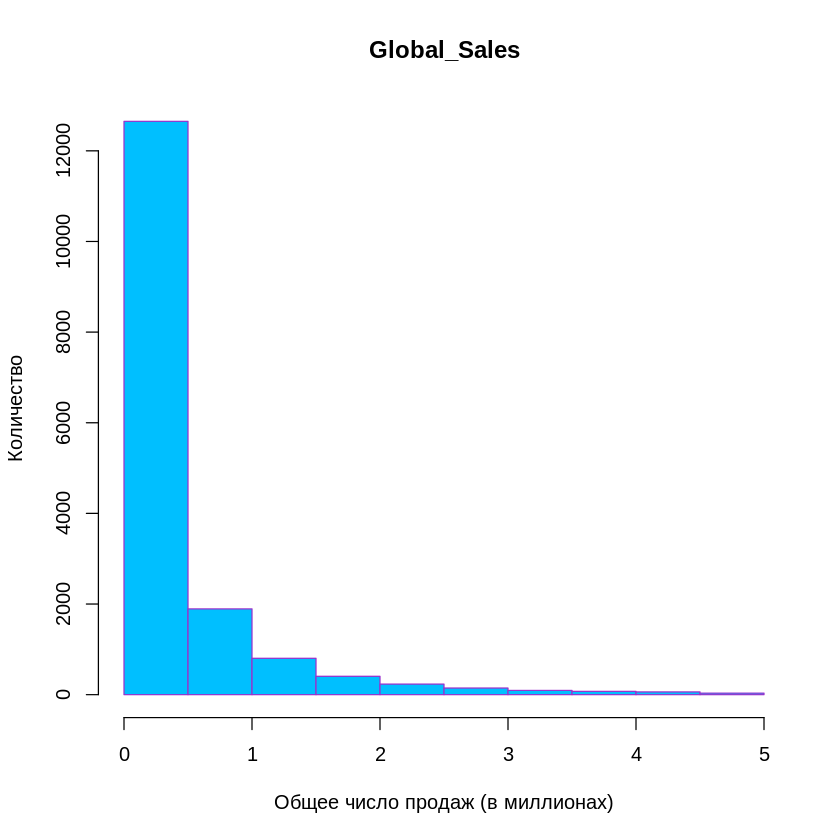

In [ ]:
hist(games$Global_Sales, col = 'deepskyblue1', border =  'darkorchid', xlab = 'Общее число продаж (в миллионах)', ylab = 'Количество', main = 'Global_Sales')

### Задача 4

Проинтерпретируйте полученную в задаче 3 гистограмму. В интерпретации укажите форму распределения (является ли оно симметричным или скошенным, если скошенным, то в какую сторону) и напишите, какие значения встречаются чаще, а какие реже.

In [ ]:
#Гистограмма показывает, что распределение общего числа продаж скошено вправо,
#так как большинство продаж сосредоточено в диапазоне от 0 до 2 миллионов.
#Чаще всего встречаются значения продаж от 0 до 1 миллиона, в то время как значения выше 3 миллионов встречаются гораздо реже.

### Задача 5

Добавьте на гистограмму из задачи 3 вертикальные линии, отчерчивающие среднее и медианное значение показателя соответственно. Линии должны быть разного цвета и начертания (сплошная линия, пунктирная, точечная, и так далее). Что можно сказать о различии между средним значением и медианным значением?

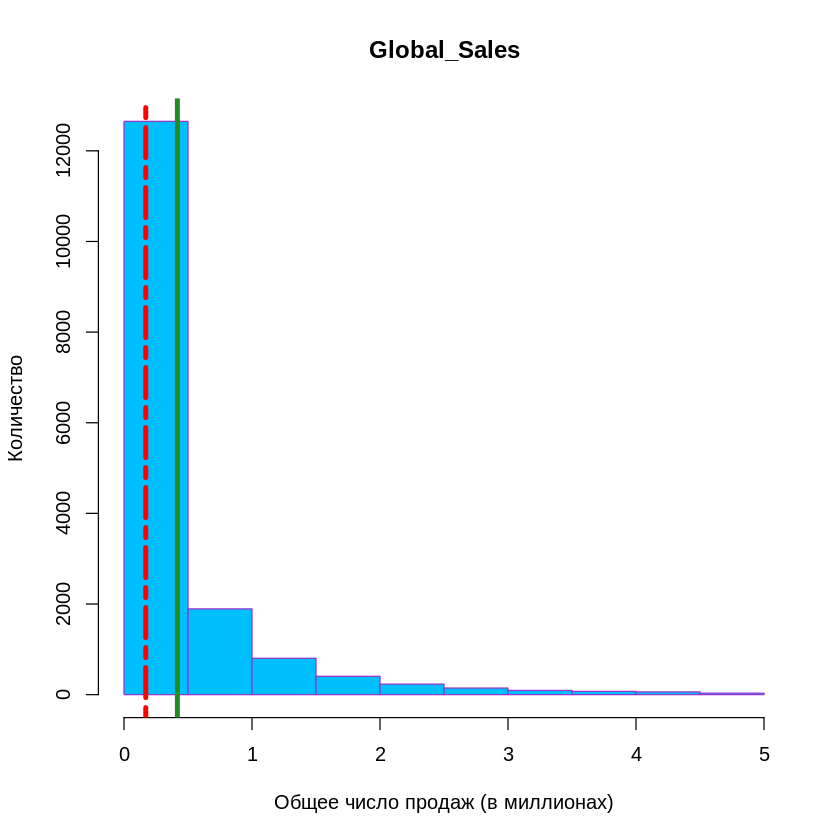

In [ ]:
hist(games$Global_Sales, col = 'deepskyblue1', border =  'darkorchid', xlab = 'Общее число продаж (в миллионах)', ylab = 'Количество', main = 'Global_Sales', breaks = 10)
abline(v = mean(games$Global_Sales), col = 'forestgreen', lty = 1, lwd = 4)
abline(v = median(games$Global_Sales), col = 'red', lty = 6, lwd = 4)
#Среднее значение продаж выше медианного, что указывает на положительное смещение.
#Это может свидетельствовать о наличии нескольких игр с очень высокими продажами, которые увеличивают среднее значение.

### Задача 6

Приведите ответ на следующий вопрос. В каких случаях использование различных начертаний линий может быть более рациональным, чем использование различных цветов?

In [ ]:
#Использование различных начертаний линий может быть более рациональным в ситуациях,
#когда цветовая палитра ограничена или когда график будет распечатан в черно-белом формате.
#Различные линии могут помочь различать данные, даже если цвета не видны.

### Задача 7

Постройте гистограммму для показателя «число продаж в Европе». Можно ли сказать, что распределение показателей «число продаж в Европе» и «общее число продаж» схожи? Приведите ответ на вопрос и обоснуйте свой ответ.

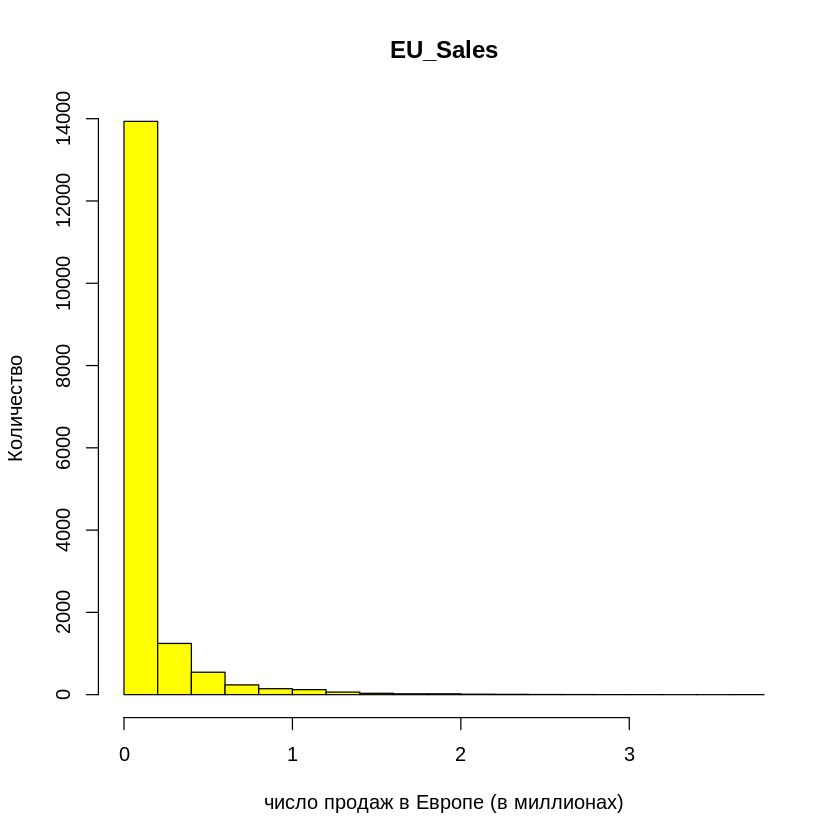

In [ ]:
hist(games$EU_Sales, col = 'yellow', main = 'EU_Sales', xlab = 'число продаж в Европе (в миллионах)', ylab = 'Количество')
#Распределение показателя «число продаж в Европе» также скошено вправо, как и распределение «общего числа продаж».
#Однако, число продаж в Европе, начиная от 1 миллиона встречаются гораздо реже.
#Такая же динамика встречается и в "общем числе продаж", но начинается она от 3-х миллионов.

### Задача 8

Постройте столбчатую диаграмму для показателя «платформа, для которой предназначена игра». При необходимости выполните поворот подписей к столбцам. Какая платформа является наиболее популярной? Приведите ответ на вопрос.

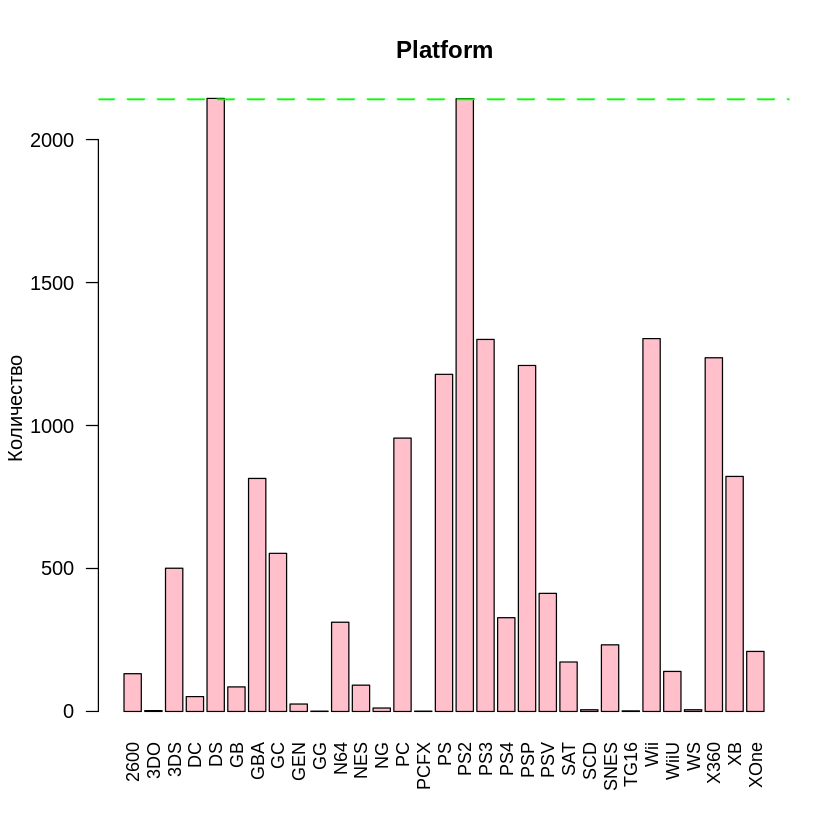

In [ ]:
tab <- table(games$Platform)
barplot(tab, main = 'Platform', ylab = 'Количество', col = 'pink', las = 2, cex.names = 0.9)
abline(h = max(tab), col = 'green', lwd = 3, lty = 2)
#Как видно из диаграммы, наиболее популярными платформами для видео-игр являются: DS(2144) и PS2(2143)

### Задача 9

Измените цвета столбцов диаграммы из задачи 8 таким образом, чтобы последовательность из пяти разных цветов повторялась необходимое число раз (по числу столбцов). Добавьте название графика на русском языке.

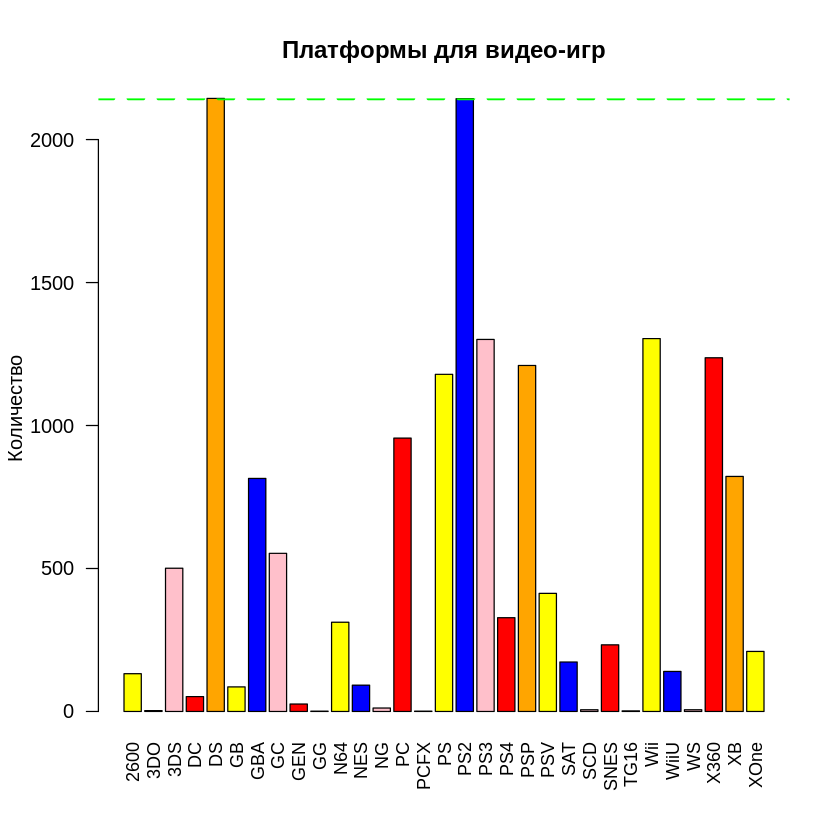

In [ ]:
col_graph <- rep(c('yellow', 'blue', 'pink', 'red', 'orange'), 6)
col_res <- c(col_graph, 'yellow')

tab <- table(games$Platform)
barplot(tab, main = 'Платформы для видео-игр', ylab = 'Количество', col = col_res, las = 2, cex.names = 0.9)
abline(h = max(tab), col = 'green', lwd = 3, lty = 2)

### Задача 10

Скорректируйте вертикальную ось диаграммы из задачи 8 таким образом, чтобы максимальное указанное значение превышало высоту самого высокого столбца.

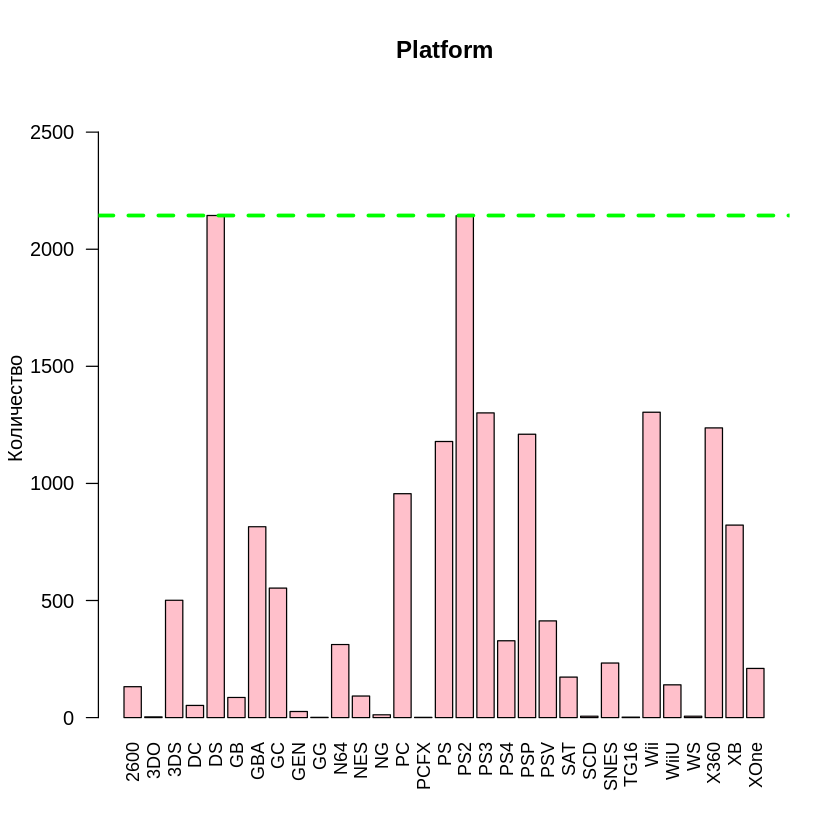

In [ ]:
tab <- table(games$Platform)
barplot(tab, main = 'Platform', ylab = 'Количество', col = 'pink', las = 2, cex.names = 0.9, ylim = c(0, max(tab) + 500))
abline(h = max(tab), col = 'green', lwd = 3, lty = 2)

### Задача 11

Постройте круговую диаграмму для показателя «жанр игры». Измените цвета диаграммы таким образом, чтобы каждому жанру соответствовал уникальный цвет. Скорректируйте диаграмму таким образом, чтобы на самой диаграмме были указаны частоты в процентах, а в легенде графика — соответствие между цветами и жанрами. При необходимости, если диаграмма по-прежнему выглядит не очень презентабельно, внесите дополнительные изменения по своему усмотрению.

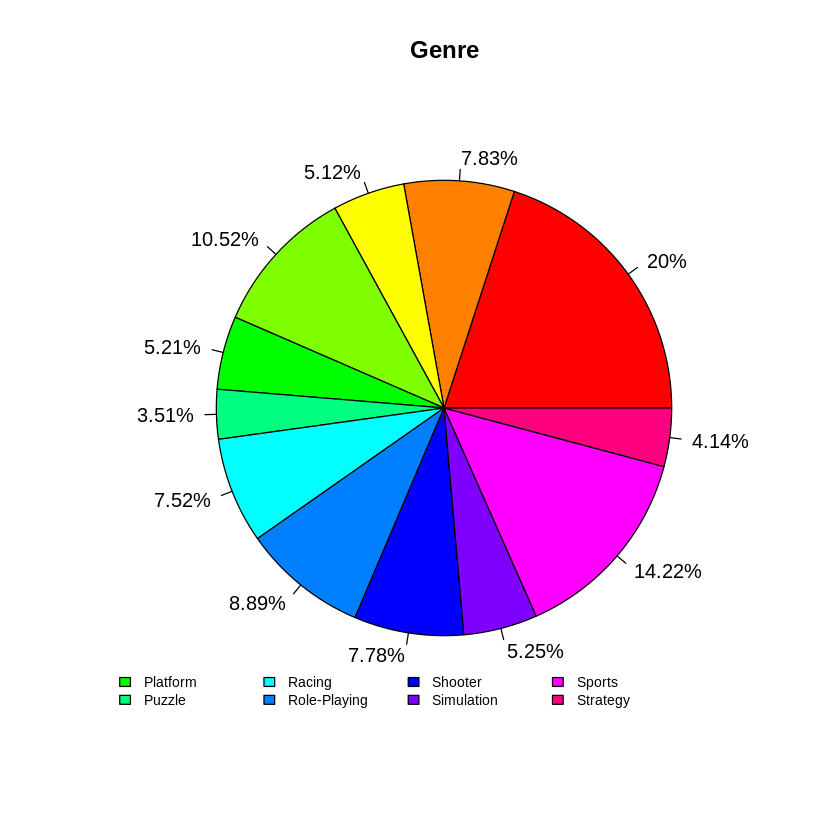

In [ ]:
tab_pie = table(games$Genre)
col_pie = rainbow(12)
prc <- round(tab_pie / sum(tab_pie) * 100,2)
prc <- paste0(prc, '%')
pie(tab_pie, col = col_pie, labels = prc, main = 'Genre')
legend(x = -2.2, y = -0.9, names(tab_pie), cex = 0.7, fill = col_pie, ncol = 6, bty = 'n')

### Задача 12

Постройте линейный график, который отражает динамику показателя «скорость скачивания файла в торрент-программе в мегабайтах в секунду» в течение случайно выбранной минуты. Значения этого показателя сохранены в векторе `torr_pace`.

```{r}
torr_pace <- c(0.3, 0.6, 1.5, 1.7, 1.2, 0.8, 1.7, 1.8, 2.0, 2.5,
               2.2, 2.7, 3.3, 3.1, 3.5, 3.0, 3.2, 3.3, 3.8, 4.0,
               3.7, 3.9, 3.5, 3.3, 3.2, 2.8, 2.5, 2.2, 1.8, 1.5,
               1.4, 1.5, 1.2, 1.6, 1.8, 2.0, 2.2, 1.9, 1.8, 1.4,
               1.2, 1.0, 0.9, 0.8, 1.1, 1.2, 1.3, 1.0, 0.8, 0.7,
               1.1, 1.3, 1.5, 1.7, 1.6, 1.8, 1.9, 2.0, 1.5, 1.1)
```

Отредактируйте график таким образом, чтобы по нему было удобно отслеживать изменения значений показателя (добавьте подписи, разлиновку, при необходимости сделайте деления по осям более детальными).

In [ ]:
torr_pace <- c(0.3, 0.6, 1.5, 1.7, 1.2, 0.8, 1.7, 1.8, 2.0, 2.5,
               2.2, 2.7, 3.3, 3.1, 3.5, 3.0, 3.2, 3.3, 3.8, 4.0,
               3.7, 3.9, 3.5, 3.3, 3.2, 2.8, 2.5, 2.2, 1.8, 1.5,
               1.4, 1.5, 1.2, 1.6, 1.8, 2.0, 2.2, 1.9, 1.8, 1.4,
               1.2, 1.0, 0.9, 0.8, 1.1, 1.2, 1.3, 1.0, 0.8, 0.7,
               1.1, 1.3, 1.5, 1.7, 1.6, 1.8, 1.9, 2.0, 1.5, 1.1)

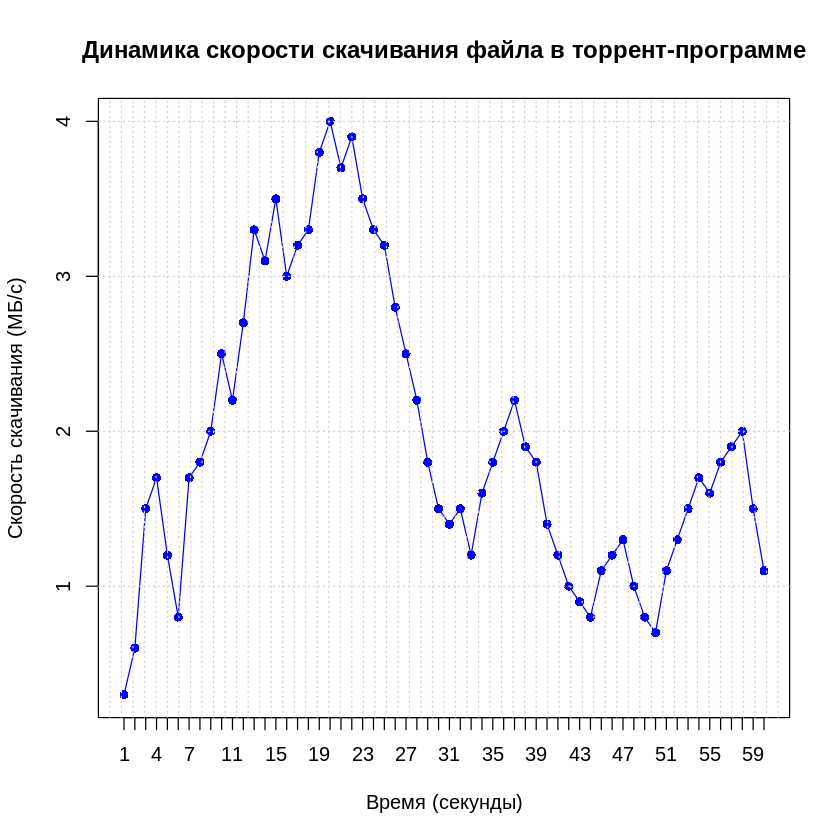

In [ ]:
plot(x = torr_pace, type = 'o', col = 'blue', pch = 16,
     xlab = 'Время (секунды)',
     ylab = 'Скорость скачивания (МБ/с)',
     main = 'Динамика скорости скачивания файла в торрент-программе',
     xaxt = 'n')
axis(1, at = 1:length(torr_pace), labels = 1:length(torr_pace))
grid(nx = 60, ny = NULL)

#Практическая работа 11


### Задача 1

Загрузите данные из файла `Cowles.csv` и сохраните их в датафрейм `psy`.

In [ ]:
psy <- read.csv('/content/датасеты/Cowles.csv')

### Задача 2

Выведите описательные статистики по всем столбцам датафрейма `psy`. Проинтерпретируйте полученную выдачу.

In [ ]:
str(psy)
summary(psy)
#Данные содержат 1421 наблюдение и 5 переменных
#Распределение невротизма варьируется от 0 до 24. Медиана и среднее близки, что говорит о более-менее симметричном распределении.
#Распределение экстраверсии от 2 до 23. Среднее немного меньше медианы, что может указывать на наличие небольшого перекоса в сторону меньших значений.

'data.frame':	1421 obs. of  5 variables:
 $ X           : int  1 2 3 4 5 6 7 8 9 10 ...
 $ neuroticism : int  16 8 5 8 9 6 8 12 15 18 ...
 $ extraversion: int  13 14 16 20 19 15 10 11 16 7 ...
 $ sex         : chr  "female" "male" "male" "female" ...
 $ volunteer   : chr  "no" "no" "no" "no" ...


       X         neuroticism     extraversion       sex           
 Min.   :   1   Min.   : 0.00   Min.   : 2.00   Length:1421       
 1st Qu.: 356   1st Qu.: 8.00   1st Qu.:10.00   Class :character  
 Median : 711   Median :11.00   Median :13.00   Mode  :character  
 Mean   : 711   Mean   :11.47   Mean   :12.37                     
 3rd Qu.:1066   3rd Qu.:15.00   3rd Qu.:15.00                     
 Max.   :1421   Max.   :24.00   Max.   :23.00                     
  volunteer        
 Length:1421       
 Class :character  
 Mode  :character  
                   
                   
                   

### Задача 3

Используя библиотеку `ggplot2`, постройте гистограмму для уровня экстраверсии по шкале Айзенка. Сделайте шаг гистограммы равным стандартному отклонению визуализируемого показателя. Измените цвет заливки гистограммы, цвет границ столбцов. Добавьте содержательные подписи по осям и заголовок графика.

Проинтерпретируйте полученный график: сформулируйте, что можно сказать о форме распределения (симметричное, скошенное) и о самых распространённых значениях показателя.

**Подсказка:** стандартное отклонение показателя можно получить с помощью базовой функции `sd()`.

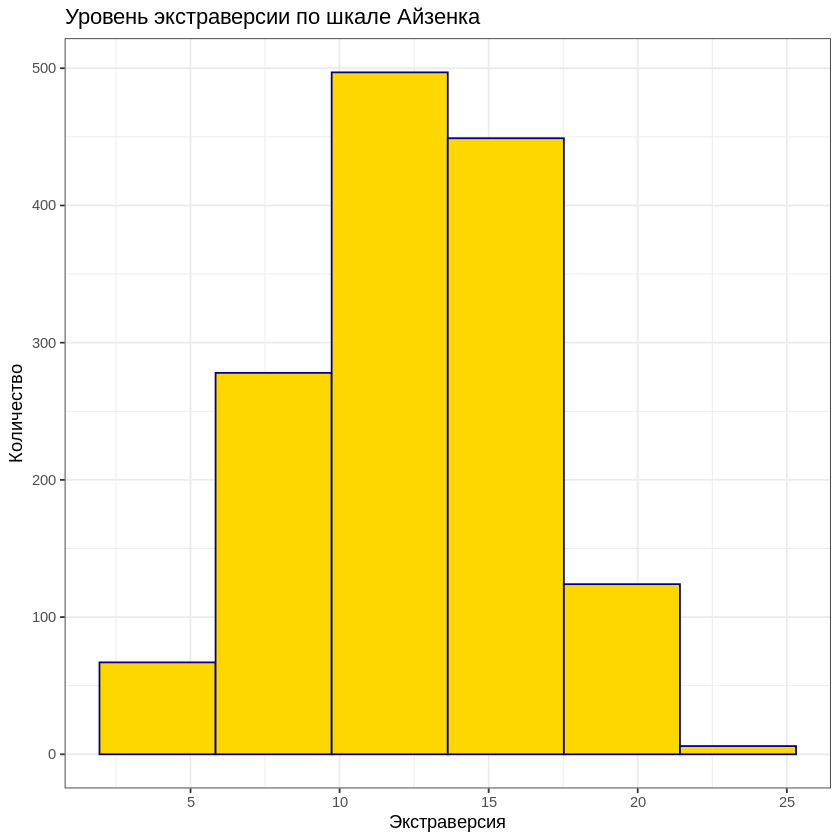

In [ ]:
library(tidyverse)

ggplot(psy, aes(x = extraversion)) +
  geom_histogram(binwidth = sd(psy$extraversion), fill = 'gold', color = 'darkblue') +
  labs(title = 'Уровень экстраверсии по шкале Айзенка', x = 'Экстраверсия', y = 'Количество') +
  theme_bw()

#Значения выше 20 и ниже 5 встречаются гораздо реже, что можно увидеть по низкой высоте столбцов на краях гистограммы
#Большинство участников имеют экстраверсию в пределах от 10 до 17. Пики гистограммы находятся в этом промежутке
#Распределение асимметричное и склонено вправо

### Задача 4

Используя библиотеку `ggplot2`, постройте графики плотности распределения для уровня невротизма с группировкой по полу респондента. Оба графика должны находиться в пределах одной картинки. Настройте прозрачность графиков, измените цвета заливки. Измените подписи в легенде таким образом, чтобы они были на русском языке.

Проинтерпретируйте полученный график: укажите, у кого в целом уровень невротизма выше, у мужчин или женщин.

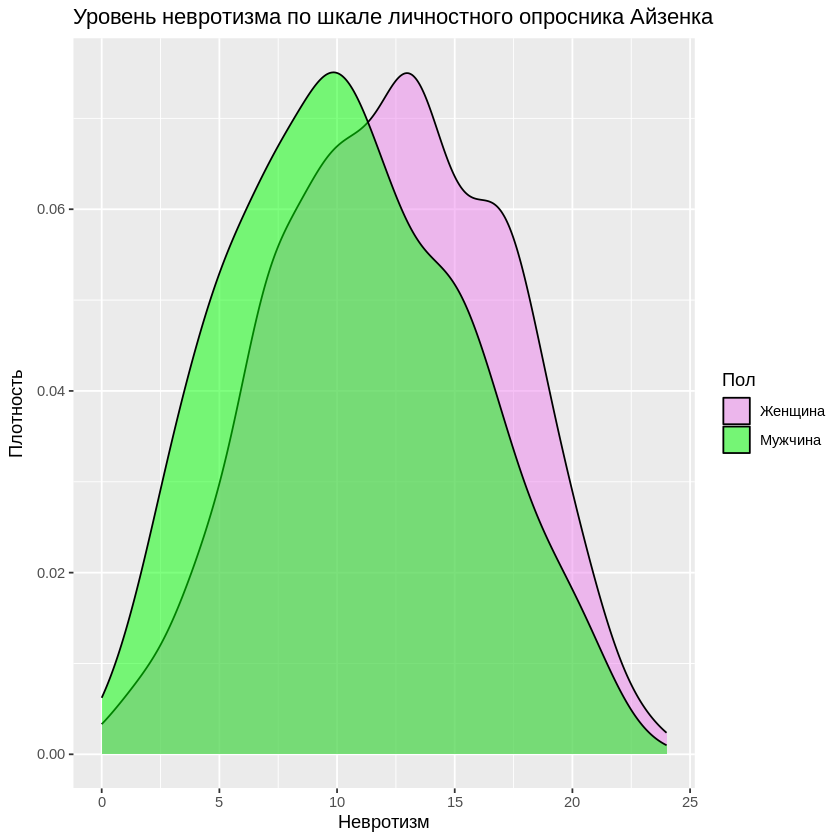

In [ ]:
ggplot(psy, aes(x = neuroticism, group = sex, fill = sex)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = c('violet', 'green'), name = 'Пол', labels = c('Женщина', 'Мужчина')) + labs(title = 'Уровень невротизма по шкале личностного опросника Айзенка', x = 'Невротизм', y = 'Плотность')

#В целом уровень невротизма выше у женщин чем у мужчин

### Задача 5

Используя библиотеку `ggplot2`, постройте гистограммы для уровня экстраверсии с группировкой по индикатору участия в волонтёрских мероприятиях. Оба графика должны находиться в разных окнах-фасетках в пределах одной картинки. Сделайте шаг гистограмм равным двум. Измените цвета заливки так, чтобы графики были разного цвета. Измените все подписи на графике таким образом, чтобы они были на русском языке.

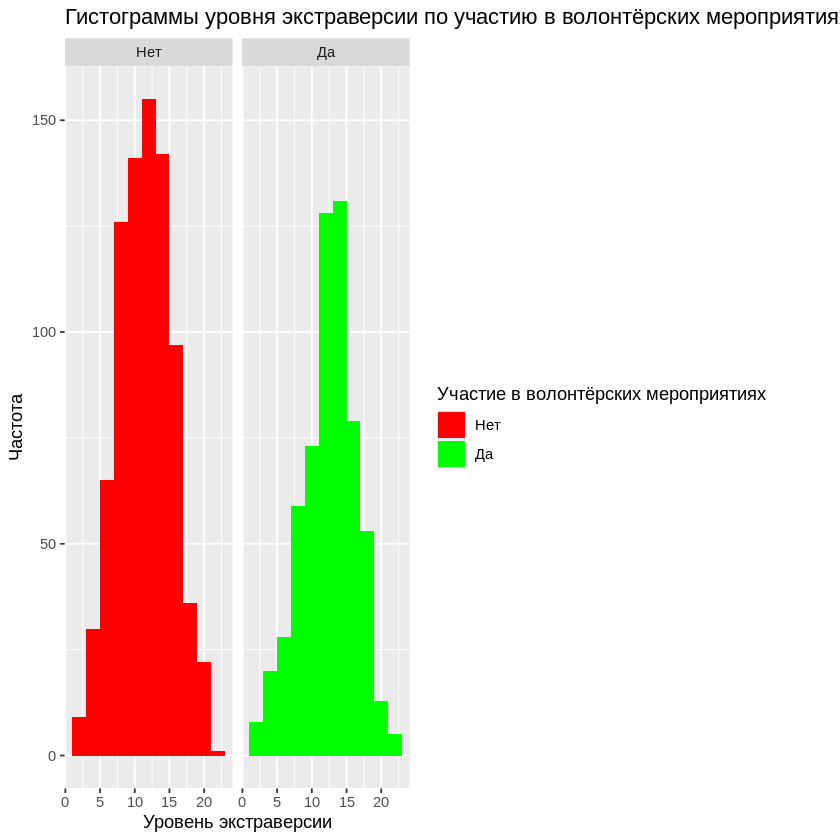

In [ ]:
label <- c('no' = 'Нет',
           'yes' = 'Да')

ggplot(psy, aes(x = extraversion, fill = volunteer)) +
  geom_histogram(binwidth = 2) +
  facet_wrap(~ volunteer, labeller = as_labeller(label)) +
  scale_fill_manual(values = c('red', 'green'),
                    name = 'Участие в волонтёрских мероприятиях',
                    labels = c('Нет', 'Да')) +
  labs(x = "Уровень экстраверсии",
       y = "Частота",
       title = "Гистограммы уровня экстраверсии по участию в волонтёрских мероприятиях")

### Задача 6

Используя библиотеку `ggplot2`, постройте столбчатую диаграмму, которая показывает, сколько респондентов мужского и женского пола принимало участие в опросе. Измените цвета заливки столбцов, выбрав цветовую палитру R по своему усмотрению.
Проинтерпретируйте полученный график: укажите, кого больше среди респондентов, мужчин или женщин.

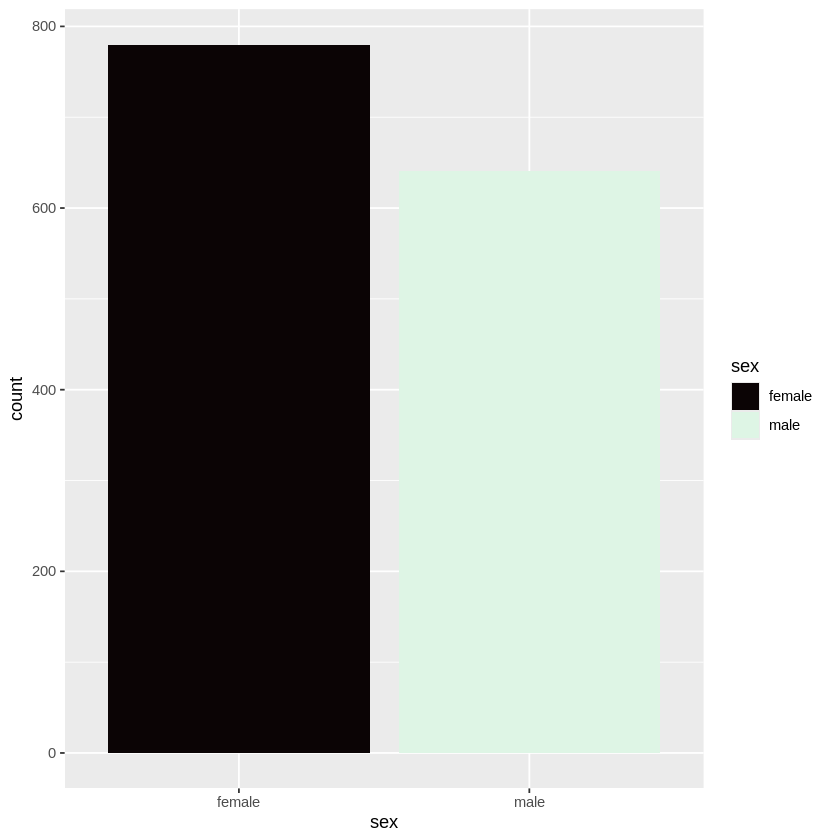

In [ ]:
psy$sex <- as.factor(psy$sex)

ggplot(psy, aes(x = sex, fill = sex)) +
  geom_bar() +
  scale_fill_viridis_d(option = 'G')

#Больше всего среди респондентов: женщин

### Задача 7

Используя библиотеку `ggplot2`, постройте круговую диаграмму, которая показывает, какая доля респондентов принимает участие в волонтёрских мероприятиях. Измените цвета заливки секторов, выбрав цветовую палитру R по своему усмотрению.

Проинтерпретируйте полученный график: укажите, кого больше среди респондентов, волонтёров или неволонтёров.

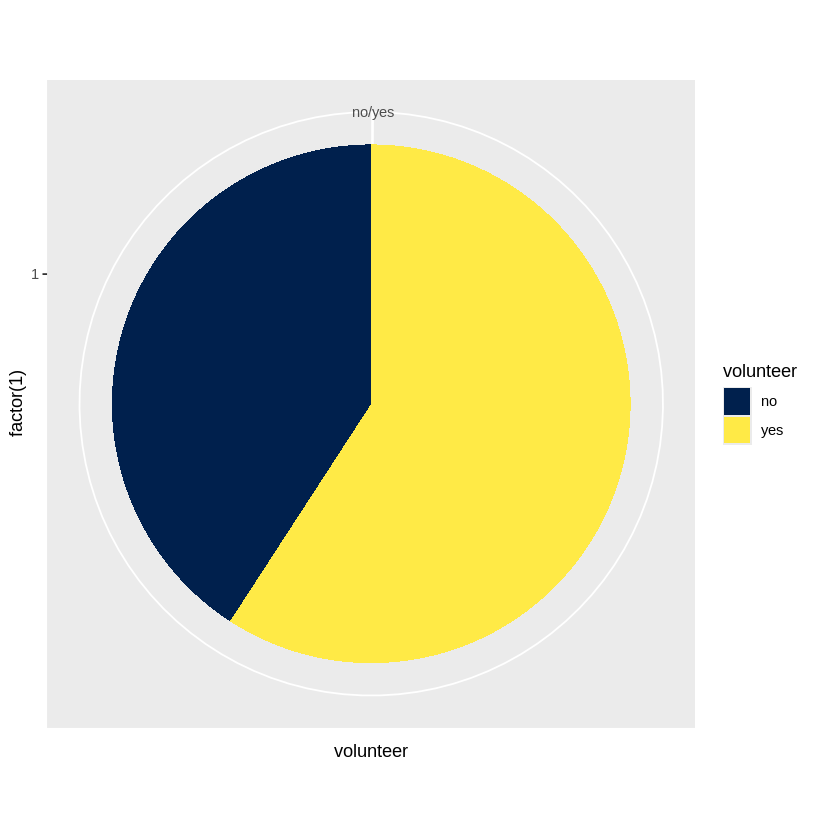

In [ ]:
ggplot(psy, aes(x = factor(1), y = volunteer, fill = volunteer)) +
  geom_bar(stat = 'identity', width = 1) +
  coord_polar('y') +
  scale_fill_viridis_d(option = 'E')

#Среди респондентов больше всего: волонтеров (жёлтая часть занимает большую долю круга)

### Задача 8

Загрузите данные из файла `Crimes.csv` и сохраните их в датафрейм `crimes`.

In [ ]:
crimes <- read.csv('/content/датасеты/Crimes.csv')

### Задача 9

Используя возможности библиотеки `tidyverse`, сохраните в датафрейм `states_an` строки, соответствующие штатам Калифорния, Флорида, Айова (California, Florida, Iowa).

In [ ]:
states_an <- crimes %>% filter(state %in% c('California', 'Florida', 'Iowa'))

### Задача 10

Используя библиотеку `ggplot2` и данные из датафрейма `states_an`, постройте линейные графики, которые отражают динамику числа краж по годам в штатах Калифорния, Флорида и Айова. Сделайте так, чтобы линии, соответствующие разным штатам, имели разные начертания (сплошная линия, пунктирная линия и так далее).

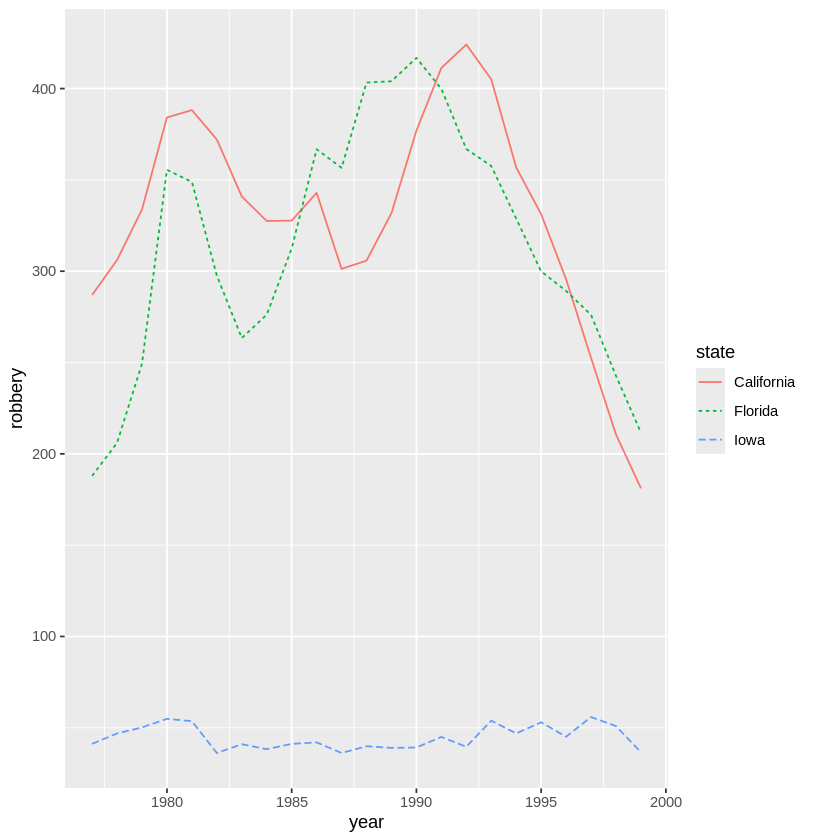

In [ ]:
ggplot(states_an, aes(x = year, y = robbery, group = state, color = state)) +
  geom_line(aes(linetype = state))

### Задача 11

Используя библиотеку `ggplot2` и данные из датафрейма `crimes`, постройте диаграмму рассеивания, которая отражает связь между числом краж и числом заключённых в тюрьму.

Проинтерпретируйте полученный график: можно ли считать, что чем больше число заключённых в тюрьму, тем меньше краж?

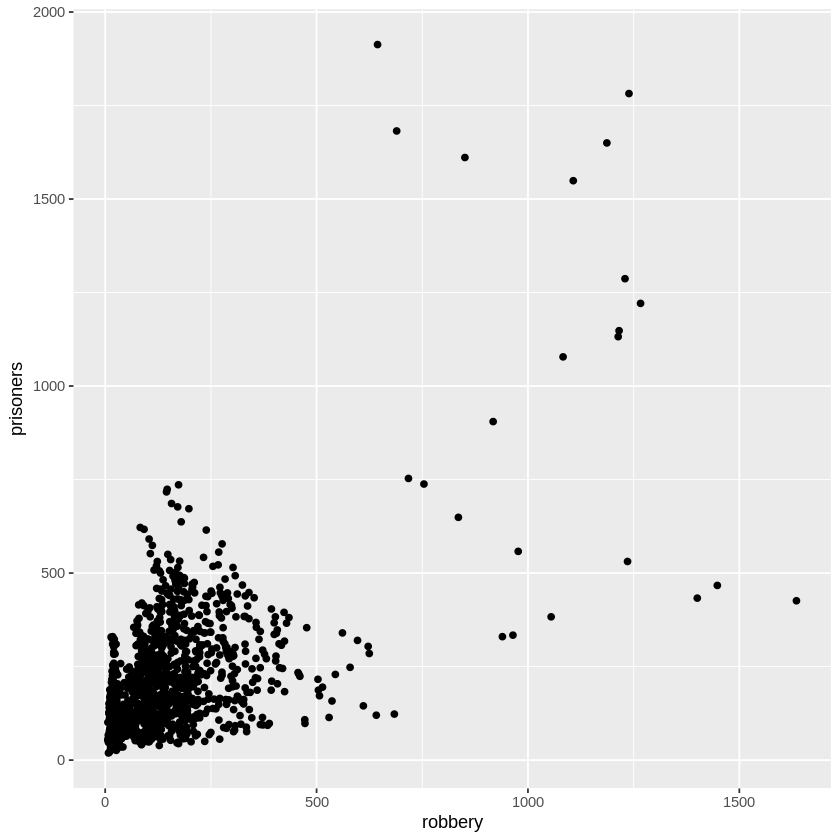

In [ ]:
ggplot(crimes, aes(x = robbery, y = prisoners)) +
  geom_point()

#На графике видно, что с увеличением числа заключённых нет чёткой тенденции к снижению числа краж.
#Данные распределены без явной зависимости, и точки разбросаны по всей плоскости

#Практическая работа 12

### Задача 1

Загрузите данные из файла `global_health.csv` и сохраните их в датафрейм `health`.

In [ ]:
health <- read.csv('/content/датасеты/global_health.csv')

### Задача 2

Используя функции библиотеки `tidyverse`, сохраните в датафрейм `h19` только те строки, которые соответствуют 2019 году. В следующих задачах необходимо работать с датафреймом `h19`.

In [ ]:
library(tidyverse)

h19 <- health %>% filter(Period == 2019)
head(h19)

,Location,Period,Indicator,Dim1,First.Tooltip
,<chr>,<int>,<chr>,<chr>,<dbl>
1,Afghanistan,2019,Healthy life expectancy (HALE) at birth (years),Both sexes,53.95
2,Afghanistan,2019,Healthy life expectancy (HALE) at birth (years),Male,54.73
3,Afghanistan,2019,Healthy life expectancy (HALE) at birth (years),Female,53.15
4,Albania,2019,Healthy life expectancy (HALE) at birth (years),Both sexes,69.08
5,Albania,2019,Healthy life expectancy (HALE) at birth (years),Male,68.00
6,Albania,2019,Healthy life expectancy (HALE) at birth (years),Female,70.25


### Задача 3

Используя библиотеку `psych`, выведите описательные статистики по продолжительности жизни в годах с группировкой по полу (`Both sexes`, `Female`, `Male`). Приведите подробную интерпретацию полученных результатов.

В частности, укажите:

* кто в среднем живёт дольше, женщины или мужчины;
* чью продолжительность жизни, женщин или мужчин, можно считать более разнообразной * относительно среднего значения по всем странам;
* можно ли считать распределения продолжительности жизни женщин и мужчин симметричными;
* если распределения продолжительности жизни женщин и мужчин нельзя считать симметричными, то в какую сторону они скошены и что это содержательно означает.

In [ ]:
install.packages("psych")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(psych)

res3 <- describeBy(h19$First.Tooltip, group = h19$Dim1)
res3

# 1) В среднем дольше живуть женщины
# 2) Более разнообразную жизнь проживают мужчины
# 3) Нет, нельзя
# 4) Распределения скошены влево. Это означает, что большинство людей живет дольше среднего. Однако это также может свидетельствовать о наличии группы с короткой продолжительностью жизни.


Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha





 Descriptive statistics by group 
group: Both sexes
    vars   n  mean    sd median trimmed   mad min max range skew kurtosis   se
X1*    1 183 87.56 50.27     88   87.53 63.75   1 175   174    0    -1.19 3.72
------------------------------------------------------------ 
group: Female
    vars   n  mean    sd median trimmed   mad min max range skew kurtosis   se
X1*    1 183 87.11 50.69     87   87.07 65.23   1 174   173    0    -1.24 3.75
------------------------------------------------------------ 
group: Male
    vars   n mean    sd median trimmed   mad min max range  skew kurtosis   se
X1*    1 183 88.9 50.62     90   89.12 65.23   1 175   174 -0.04    -1.24 3.74

### Задача 4

Используя библиотеку `ggplot2`, постройте графики плотности распределения продолжительности жизни женщин и мужчин в пределах одного рисунка и прокомментируйте, как построенные графики соотносятся с вашими выводами о симметричности или скошенности распределения в предыдущей задаче.

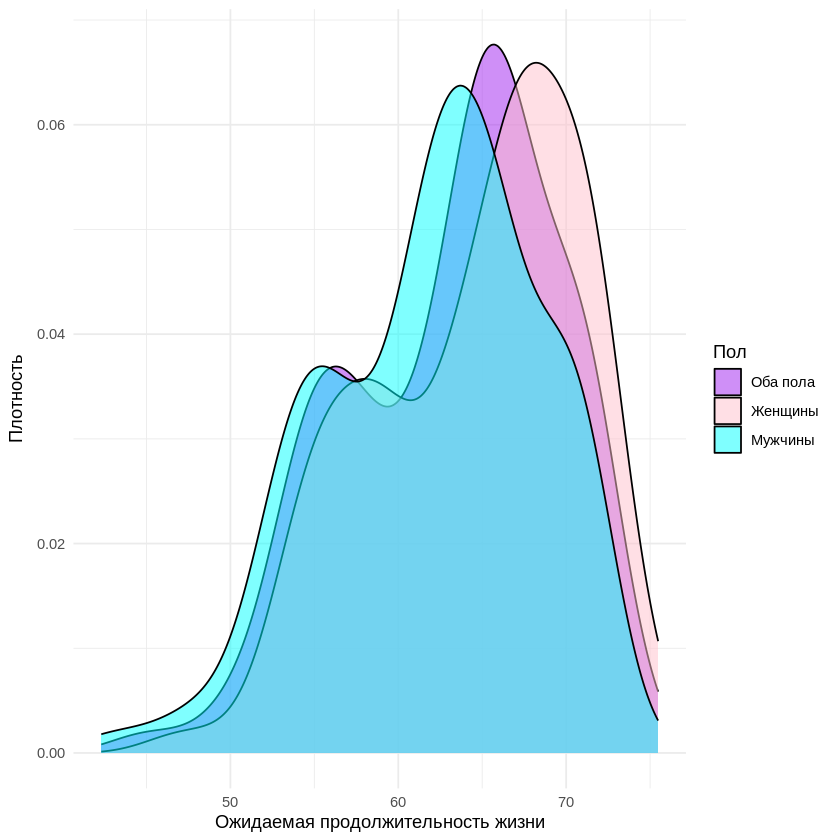

In [ ]:
ggplot(h19, aes(x = First.Tooltip, group = Dim1, fill = Dim1)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(
    name = 'Пол',
    values = c('purple', 'pink', 'cyan'),
    labels = c('Both sexes' = 'Оба пола', 'Female' = 'Женщины', 'Male' = 'Мужчины')
  ) +
  labs(x = 'Ожидаемая продолжительность жизни', y = 'Плотность') +
  theme_minimal()

# 1) Женщины живут дольше: на графике видно, что пик распределения для женщин смещен вправо по сравнению с мужчинами, что говорит о том, что в среднем женщины живут дольше;
#
# 2) Более разнообразную жизнь проживают мужчины: график для мужчин более размыт и распределение шире, что указывает на большую изменчивость (разнообразие) продолжительности жизни у мужчин;
#
# 3) График показывает, что распределения несимметричные, так как они имеют выраженные 'хвосты';
#
# 4) Распределения скошены влево: для обоих полов распределения имеют левую скошенность. Это видно по длинным левым 'хвостам' графиков, что означает, что большинство людей живут дольше среднего, но существует и значительная группа людей с более короткой продолжительностью жизни.

### Задача 5

Используя функции `tidyverse`, преобразуйте датафрейм `h19` таким образом, чтобы значения продолжительности жизни обоих полов, женщин и мужчин, находились в разных столбцах. Сохраните преобразованный датафрейм в переменную `hh`.

**Пояснение.** Датафрейм `hh` должен иметь следующие корректно заполненные столбцы: `Location`, `Period`, `Indicator`, `Both sexes`, `Female`, `Male`. В датафрейме `hh` одна строка должна соответствовать одной стране, страны в столбце `Location` не должны повторяться.

**Подсказка.** Вспомните про трансформацию таблиц и разницу между *long format* (длинный формат) и *wide format* (широкий формат).

In [ ]:
hh <- h19 %>%
  spread(key = Dim1, value = First.Tooltip)

print(hh)

                                                Location Period
1                                            Afghanistan   2019
2                                                Albania   2019
3                                                Algeria   2019
4                                                 Angola   2019
5                                    Antigua and Barbuda   2019
6                                              Argentina   2019
7                                                Armenia   2019
8                                              Australia   2019
9                                                Austria   2019
10                                            Azerbaijan   2019
11                                               Bahamas   2019
12                                               Bahrain   2019
13                                            Bangladesh   2019
14                                              Barbados   2019
15                                      

### Задача 6

Используя базовые функции R, не связанные с построением графиков, определите, есть ли у продолжительности жизни женщин нетипичные значения. Есть нет, напишите, что их нет; если есть, укажите какие.

In [ ]:
iqr <- IQR(h19$First.Tooltip)
q1 <- quantile(h19$First.Tooltip, 0.25)
q3 <- quantile(h19$First.Tooltip, 0.75)

lower_b <- q1 - 1.5 * iqr
upper_b <- q3 + 1.5 * iqr

extra_female <- h19[h19$Dim1 == 'Female' & (h19$First.Tooltip < lower_b | h19$First.Tooltip > upper_b), ]
extra_female
#Нетипичных значений для женщин нет

Location,Period,Indicator,Dim1,First.Tooltip
<chr>,<int>,<chr>,<chr>,<dbl>


### Задача 7

Используя базовую функцию R, постройте ящик с усами для продолжительности жизни мужчин. Есть ли у этого показателя нетипичные значения? Если есть, определите используя R, каким странам эти нетипичные значения соответствуют.

,Location,Period,Indicator,Dim1,First.Tooltip
,<chr>,<int>,<chr>,<chr>,<dbl>
281,Lesotho,2019,Healthy life expectancy (HALE) at birth (years),Male,42.31


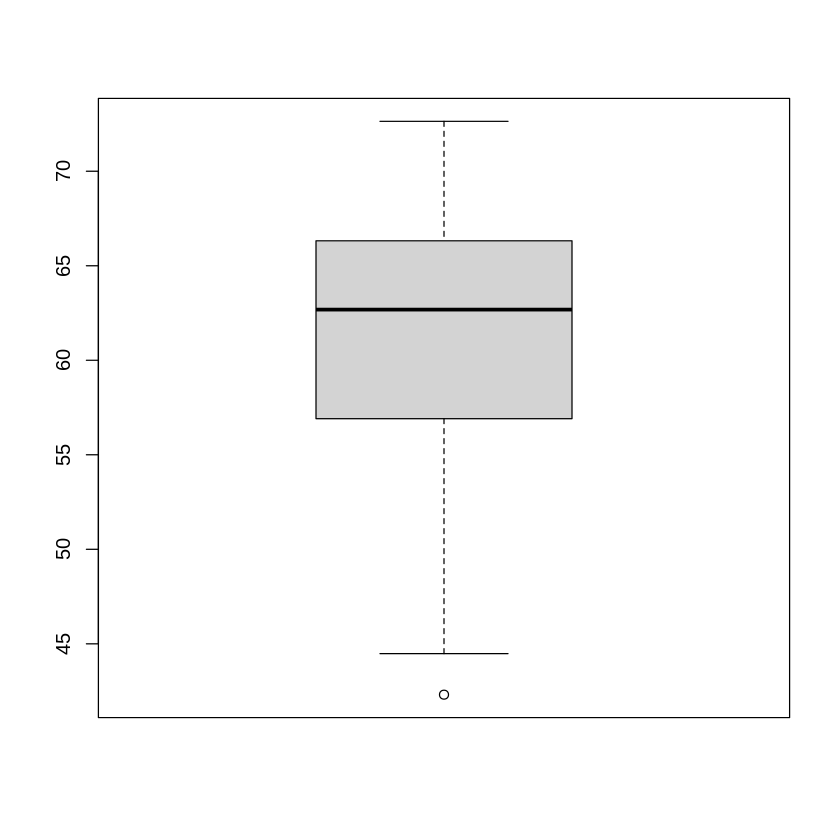

In [ ]:
boxplot(h19$First.Tooltip[h19$Dim1 == 'Male'])

iqr <- IQR(h19$First.Tooltip)
q1 <- quantile(h19$First.Tooltip, 0.25)
q3 <- quantile(h19$First.Tooltip, 0.75)
lower_b <- q1 - 1.5 * iqr
upper_b <- q3 + 1.5 * iqr
extra_male <- h19[h19$Dim1 == 'Male' & (h19$First.Tooltip < lower_b | h19$First.Tooltip > upper_b), ]
extra_male
#У этого показателя есть одно нетипичное значение.
#Единственное нетепичное значение для мужчин соответсвует стране: Lesotho

### Задача 8

Используя библиотеку `ggplot2`, постройте ящик с усами для продолжительности жизни с группировкой по полу (`Both sexes`, `Female`, `Male`). Измените цвет заливки графика и цвет его границ, добавьте содержательные подписи к осям.

**Подсказка.** Имеет смысл вернуться к датафрейму `h19`. Примеры построения ящиков с усами с помощью `ggplot2` можно посмотреть в [туториале](http://www.sthda.com/english/wiki/ggplot2-box-plot-quick-start-guide-r-software-and-data-visualization) и официальной [галерее](https://www.r-graph-gallery.com/boxplot.html) графиков R.

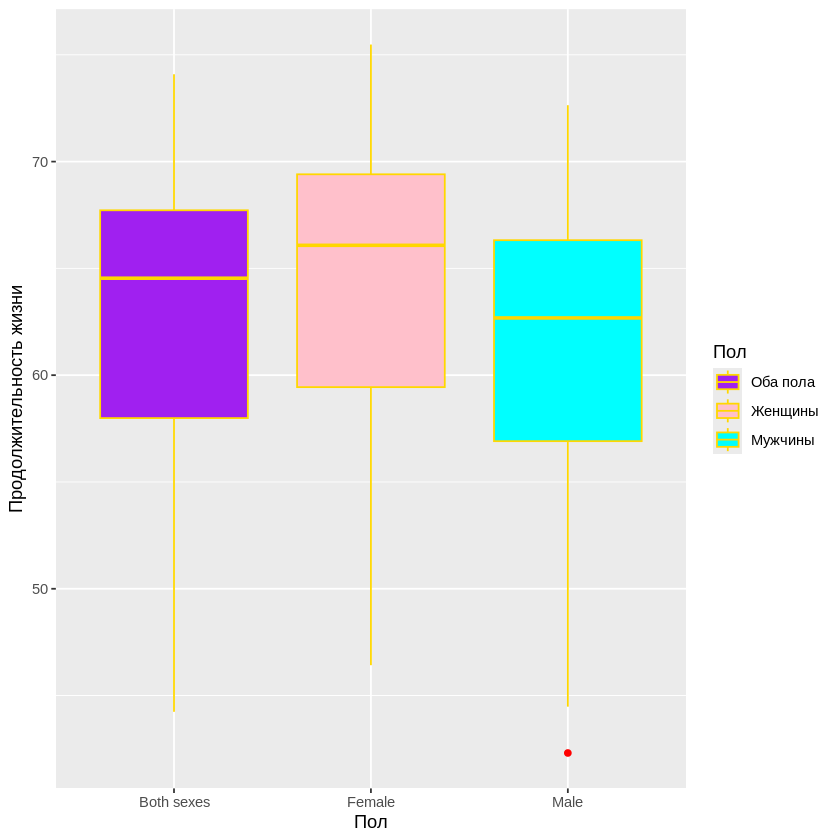

In [ ]:
ggplot(h19, aes(x = Dim1, y = First.Tooltip, fill = Dim1)) +
  geom_boxplot(color = 'gold', outlier.colour = "red") +
  labs(x = 'Пол', y = 'Продолжительность жизни') +
  scale_fill_manual(name = 'Пол', labels = c('Both sexes' = 'Оба пола', 'Female' = 'Женщины', 'Male' = 'Мужчины'), values = c('purple', 'pink', 'cyan'))

### Задача 9

Используя подходящий коэффициент корреляции, ответьте на следующий вопрос: правда ли, что в целом в странах, где женщины живут дольше, мужчины тоже живут дольше? Насколько сильна связь между продолжительностью жизни мужчин и женщин?

[1] 0.9569132

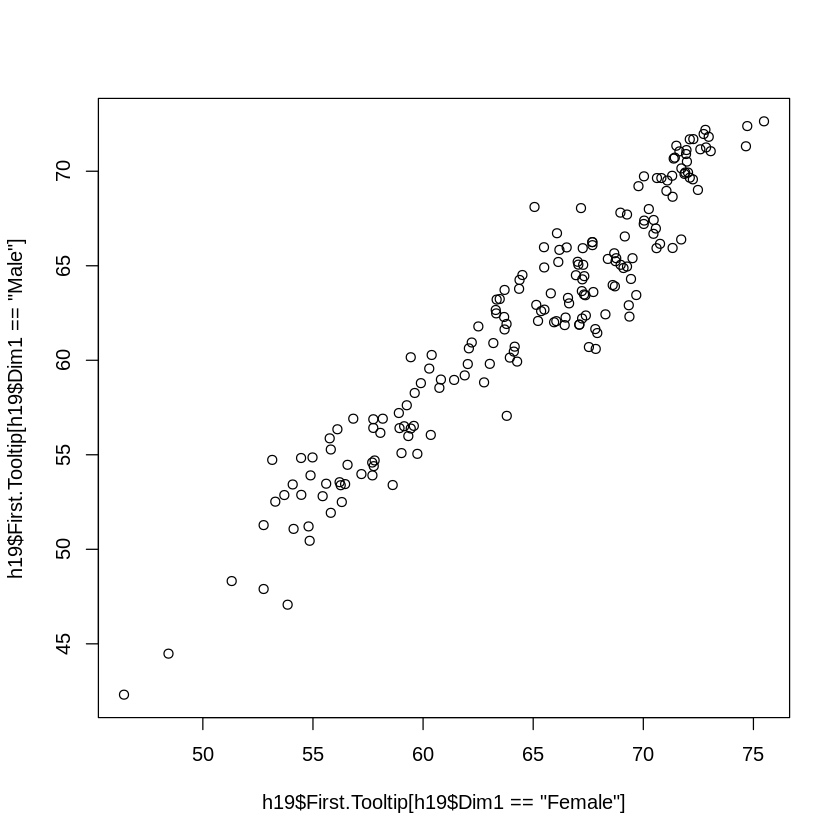

In [ ]:
plot(h19$First.Tooltip[h19$Dim1 == 'Female'], h19$First.Tooltip[h19$Dim1 == 'Male'])
cor(h19$First.Tooltip[h19$Dim1 == 'Female'], h19$First.Tooltip[h19$Dim1 == 'Male'])

#По коэффициенту корреляции Пирсона искомая связь равна 0.9569132, что говорит нам об сильной связи продолжительности жизни между мужчинами и женщинами
#График рассеяния тоже показывает положительную связь между продолжительностью жизни женщин и мужчин, что соответствует ожиданиям, что в тех странах, где женщины живут дольше, мужчины тоже имеют тенденцию жить дольше.

### Задача 10

Загрузите в R данные из файлов `global_alcohol.csv` и `global_doctors.csv` и сохраните их в датафреймы `alc` и `doc` соответственно. Используя функции библиотеки `tidyverse`, сохраните в датафреймы `alc16` и `doc16` только те строки, которые соответствуют 2016 году.

In [ ]:
alc <- read.csv('/content/датасеты/global_alcohol.csv')
doc <- read.csv('/content/датасеты/global_doctors.csv')

alc16 <- alc %>% filter(Period == 2016)
doc16 <- doc %>% filter(Period == 2016)
head(alc16)
head(doc16)
#При фильтрации 2016 года, оказалось, что в датафрейме doc16 не оказалось ни одного значения 2016 года, поэтому эту таблицу мы не берем в расчет.

Location,Period,Indicator,Dim1,First.Tooltip
<chr>,<int>,<chr>,<chr>,<dbl>


,Location,Period,Indicator,First.Tooltip
,<chr>,<int>,<chr>,<dbl>
1,Afghanistan,2016,"Medical doctors (per 10,000)",2.78
2,Albania,2016,"Medical doctors (per 10,000)",12.16
3,Algeria,2016,"Medical doctors (per 10,000)",18.33
4,Argentina,2016,"Medical doctors (per 10,000)",40.01
5,Australia,2016,"Medical doctors (per 10,000)",35.67
6,Austria,2016,"Medical doctors (per 10,000)",51.23


### Задача 11

Используя функции библиотеки `tidyverse`, оставьте в датафрейме `alc16` только те строки, которые соответствуют обоим полам (`Both sexes`).

In [ ]:
alc16 <- alc16 %>% filter(Dim1 == 'Both sexes')
alc16
#По большому счету мы фильтруем пустые значения и от фильтрации ничего не измениться, так как в датафрейме alc16 отсутсвует 2016 год, отфильторованный в прошлом задании

Location,Period,Indicator,Dim1,First.Tooltip
<chr>,<int>,<chr>,<chr>,<dbl>


### Задача 12

Используя функции библиотеки `tidyverse`, объедините датафреймы `hh`, `alc16` и `doc16` таким образом, чтобы в итоговом датафрейме оказались показатели ожидаемой продолжительности жизни, потребления алкоголя на душу населения и числа врачей на 10 000 населения.

In [ ]:
res_zad_12 <- hh %>%
  left_join(doc16, by = "Location") %>% left_join(alc16, by = "Location")
head(res_zad_12)

,Location,Period.x,Indicator.x,Both sexes,Female,Male,Period.y,Indicator.y,First.Tooltip.x,Period,Indicator,Dim1,First.Tooltip.y
,<chr>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,Afghanistan,2019,Healthy life expectancy (HALE) at birth (years),53.95,53.15,54.73,2016,"Medical doctors (per 10,000)",2.78,NA,NA,NA,NA
2,Albania,2019,Healthy life expectancy (HALE) at birth (years),69.08,70.25,68.00,2016,"Medical doctors (per 10,000)",12.16,NA,NA,NA,NA
3,Algeria,2019,Healthy life expectancy (HALE) at birth (years),66.39,66.08,66.72,2016,"Medical doctors (per 10,000)",18.33,NA,NA,NA,NA
4,Angola,2019,Healthy life expectancy (HALE) at birth (years),54.84,56.21,53.55,NA,NA,NA,NA,NA,NA,NA
5,Antigua and Barbuda,2019,Healthy life expectancy (HALE) at birth (years),66.97,67.69,66.25,NA,NA,NA,NA,NA,NA,NA
6,Argentina,2019,Healthy life expectancy (HALE) at birth (years),67.13,68.77,65.40,2016,"Medical doctors (per 10,000)",40.01,NA,NA,NA,NA


### Задача 13

Выберите из датафрейма, полученного в задаче 12, столбцы, соответствующие следующим показателям: ожидаемая продолжительность жизни для обоих полов, потребление алкоголя на душу населения и число врачей на 10000 населения. Сохраните результат в датафрейм `small`.

In [ ]:
small <- res_zad_12 %>% select('Both sexes', 'First.Tooltip.x')
head(small)
#Не берем в расчет столбец First.Tooltip.y - потребление алкоголя на душу населения, так как в нем все значения пустые(NA), что будет мешать делать анализ.

,Both sexes,First.Tooltip.x
,<dbl>,<dbl>
1,53.95,2.78
2,69.08,12.16
3,66.39,18.33
4,54.84,NA
5,66.97,NA
6,67.13,40.01


### Задача 14

Постройте корреляционную матрицу для показателей в датафрейме `small`. Визуализируйте эту корреляционную матрицу, используя библиотеку `corrplot`, выбрав тип графика на своё усмотрение. Проинтерпретируйте полученный результат.

In [ ]:
install.packages('corrplot')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



corrplot 0.95 loaded



,Both sexes,First.Tooltip.x
Both sexes,1.000000,0.722213
First.Tooltip.x,0.722213,1.000000


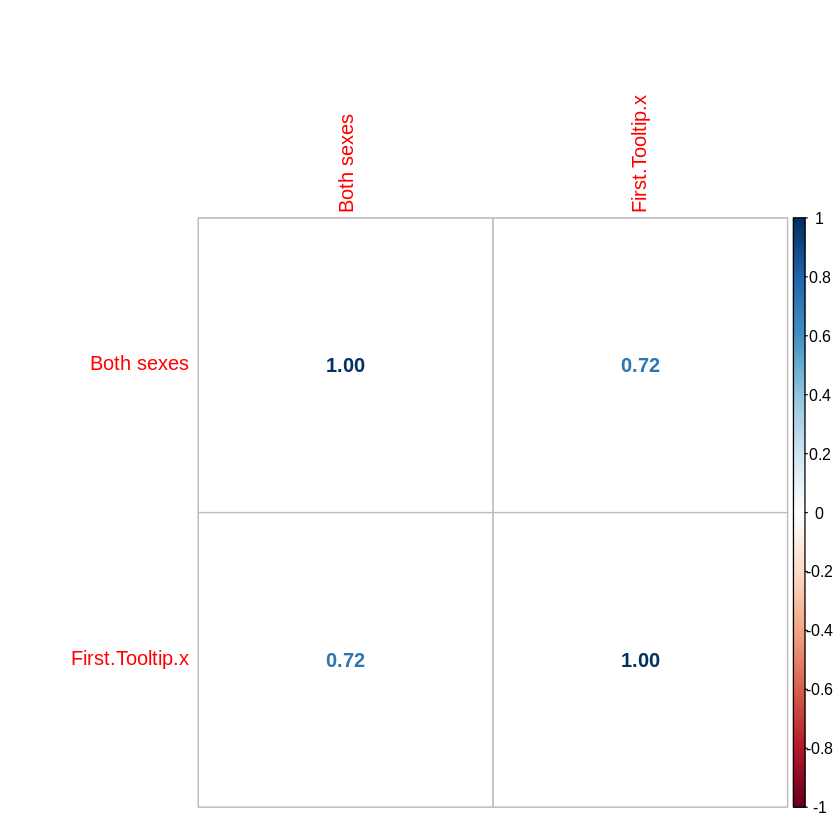

In [ ]:
library(corrplot)
small <- na.omit(small)
M <- cor(small)
M
corrplot(M, method = "number")

#Так как в датафрейме alc16 нет значений 2016 года, то корреляционная матрица выдает пустое значение NA, из-за этого трудно проинтерпретировать полученный результат и мы ее не берем в расчет, а из оставшихся результатов можно сказать, что корреляция между First.Tooltip.x и Both sexes достаточно высокая 0.72

#Практическая работа 14

###Задача 1
Используя функцию rchisq(), сгенерируйте генеральную совокупность population, состоящую из 4000 значений случайной величины, имеющей распределение хи-квадрат с числом степеней свободы df = 4. Постройте гистограмму для population, измените её цвет.

Извлеките из генеральной совокупности population 500 случайных выборок объёма 1000, вычислите по каждой выборке среднее значение и сохраните полученные средние значения в вектор chi_means. Постройте гистограмму для chi_means, измените её цвет. Сравните гистограммы для chi_means и для population. Прокомментируйте результат, опираясь на центральную предельную теорему.

Сравните средние значения population и chi_means. Сильно ли они отличаются? Прокомментируйте полученные результаты, опираясь на центральную предельную теорему.

Сравните стандартные отклонения population и chi_means. Во сколько раз они отличаются? Прокомментируйте полученные результаты, опираясь на центральную предельную теорему.

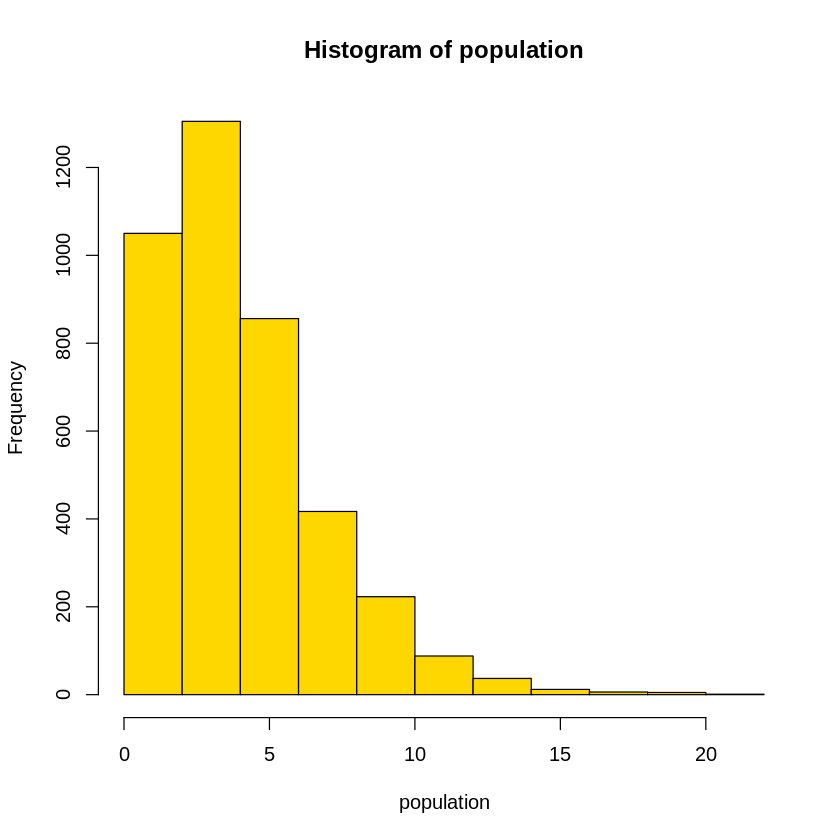

[1] 4.003158

[1] 4.001719

[1] 0.07602686

[1] 2.795064

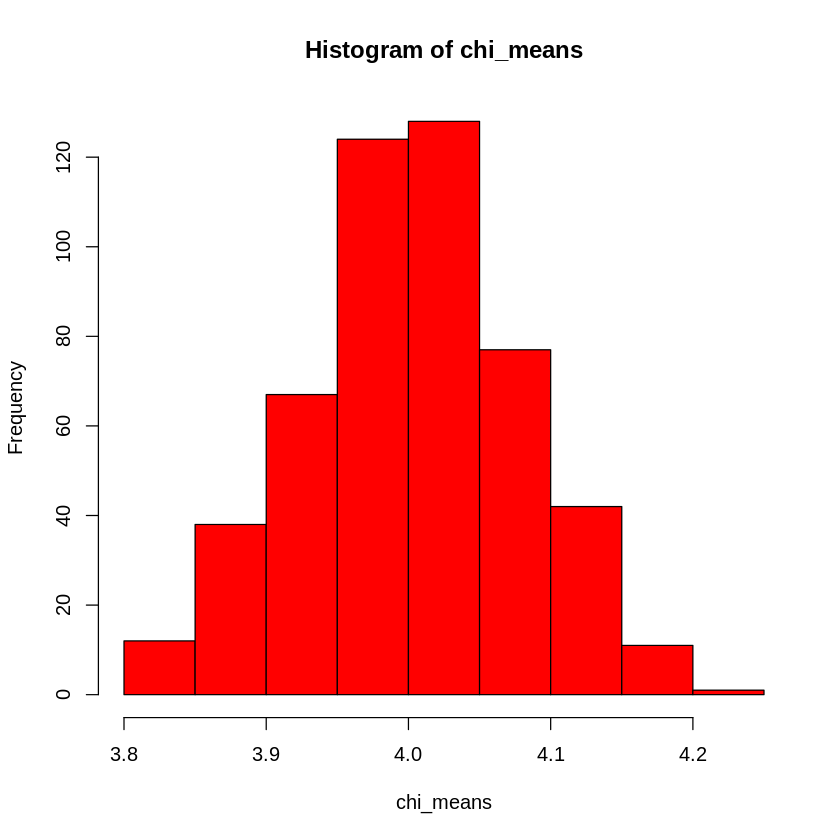

In [ ]:
population <- rchisq(4000, 4)
chi_means <- rep(NA, 500)
hist(population, col = 'gold')
for (i in 1:500){
  s = sample(population, size = 1000)
  m = mean(s)
  chi_means[i] <- m
}
hist(chi_means, col = 'red')

 #Гистограмма population имеет асимметричное распределение, что характерно для распределения хи-квадрат.
 #Гистограмма chi_means приближается к нормальному распределению, что подтверждает центральная предельная теорема

mean(chi_means)
mean(population)
#Среднее значение для chi_means (3.978932) близко к среднему population (3.976157). Это соответствует ожиданиям, поскольку согласно центральной предельной теореме, средние значения выборок близки к среднему генеральной совокупности

sd(chi_means)
sd(population)
# Стандартное отклонение chi_means (0.07908096) значительно меньше, чем у population (2.770627). Это объясняется тем, что стандартное отклонение средних значений выборок связано с размером выборки и меньше стандартного отклонения исходной совокупности (уменьшается примерно в корень из размера выборки раз). Наши стандартные отклонения отличаются примерно в 35 раз, что примерно равно sqrt(1000) - корень из размера выборки

###Задача 2
Загрузите данные из файла popular.csv и сохраните их в датафрейм popular. Выведите описательные статистики по датафрейму.

In [ ]:
popular <- read.csv('/content/датасеты/popular.csv')
summary(popular)

       X           article_id        full_name             sex           
 Min.   :    1   Min.   :     307   Length:11341       Length:11341      
 1st Qu.: 2836   1st Qu.:   70560   Class :character   Class :character  
 Median : 5671   Median :  275443   Mode  :character   Mode  :character  
 Mean   : 5671   Mean   : 2282303                                        
 3rd Qu.: 8506   3rd Qu.:  966811                                        
 Max.   :11341   Max.   :38707829                                        
     city             country           continent          occupation       
 Length:11341       Length:11341       Length:11341       Length:11341      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                    

###Задача 3
Используя функции из библиотеки DescTools, постройте 99%-ный доверительный интервал для доли страниц известных людей, относящихся к гуманитарным наукам (значение Humanities в domain). Проинтерпретируйте полученный доверительный интервал.

In [ ]:
install.packages('DescTools')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:

library(DescTools)

ci_99 <- BinomCI(sum(popular$domain == 'Humanities'), nrow(popular), 0.99)
ci_99
#С 99% - ой уверенностью можно сказать, что доля страниц известных людей, относящихся к гуманитарным наукам (значение Humanities в domain), находится в пределах от 0.1096286 до 0.1251899


Attaching package: ‘DescTools’


The following objects are masked from ‘package:psych’:

    AUC, ICC, SD




est,lwr.ci,upr.ci
0.1171854,0.1096286,0.1251899


###Задача 4
Используя функции из библиотеки DescTools, постройте 90%-ный доверительный интервал для доли страниц известных людей, относящихся к техническим наукам (значение Science & Technology в domain). Проинтерпретируйте полученный доверительный интервал.

In [ ]:
ci_90 <- BinomCI(sum(popular$domain == 'Science & Technology'), nrow(popular), 0.9)
ci_90
#C 90% - ой уверенностью можно сказать, что доля страниц известных людей, относящихся к техническим наукам (значение Science & Technology в domain), находится в пределах от 0.115511 до 0.1255659

est,lwr.ci,upr.ci
0.1204479,0.115511,0.1255659


###Задача 5
Используя функции из библиотеки DescTools, постройте:

95%-ный доверительный интервал для среднего значения индекса исторической популярности известных людей, относящихся к гуманитарным наукам.
95%-ный доверительный интервал для среднего значения индекса исторической популярности известных людей, относящихся к техническим наукам.
Сохраните полученные доверительные интервалы (результаты, возвращаемые соответствующей функцией) в переменные ci1 и ci2.

Сравните полученные доверительные интервалы. Пересекаются ли они? Сделайте вывод: укажите, есть ли основания считать средние значения индекса исторической популярности известных людей, относящихся к гуманитарным наукам и техническим наукам, одинаковыми.

In [ ]:
library(DescTools)

humanities_data <- popular$historical_popularity_index[popular$domain == 'Humanities']
tech_data <- popular$historical_popularity_index[popular$domain == 'Science & Technology']
ci1 <- MeanCI(humanities_data, conf.level = 0.95)
ci2 <- MeanCI(tech_data, conf.level = 0.95)
ci1
ci2
# Нет, они не пересекаются
# Нет, нет основания считать средние значения индекса исторической популярности известных людей, относящихся к гуманитарным наукам и техническим наукам, одинаковыми

mean   lwr.ci   upr.ci 
24.34654 24.22785 24.46523

mean   lwr.ci   upr.ci 
23.36577 23.26603 23.46551

###Задача 6
Создайте вектор x, состоящий из чисел 1 и 2. Используя значения ci1 и ci2, выполните следующее:

сохраните в вектор mns значения средних, рассчитанных по выборкам (est из каждого интервала);
сохраните в вектор low значения нижних границ доверительных интервалов (lwr.ci из каждого интервала);
сохраните в вектор upp значения нижних границ доверительных интервалов (upr.ci из каждого интервала).
Объедините векторы x, mns, low, upp в датафрейм dat.

In [ ]:
x <- c(1, 2)
mns <- c(ci1[1], ci2[1])
low <- c(ci1[2], ci2[2])
upp <- c(ci1[3], ci2[3])
dat <- data.frame(x, mns, low, upp)
dat

x,mns,low,upp
<dbl>,<dbl>,<dbl>,<dbl>
1,24.34654,24.22785,24.46523
2,23.36577,23.26603,23.46551


###Задача 7
Запустите следующий код, предварительно вызвав необходимую библиотеку:
```{r}
library(tidyverse)
ggplot(dat, aes(x = x, y = mns)) +
  geom_errorbar(aes(ymin = low, ymax = upp)) +
  geom_point(size = 4) +
  labs(x = "95% confidence intervals", y = "means")
```
Если датафрейм dat был создан правильно, вы увидите визуализацию для построенных 95%-ных доверительных интервалов для средних значений индекса исторической популярности. Точками на графике обозначены средние значения выборок, а «усы» графиков образованы границами доверительных интервалов.

Модифицируйте приведённый код так, чтобы графики, соответствующие разным выборкам, были разного цвета (два цвета выберите по своему усмотрению).

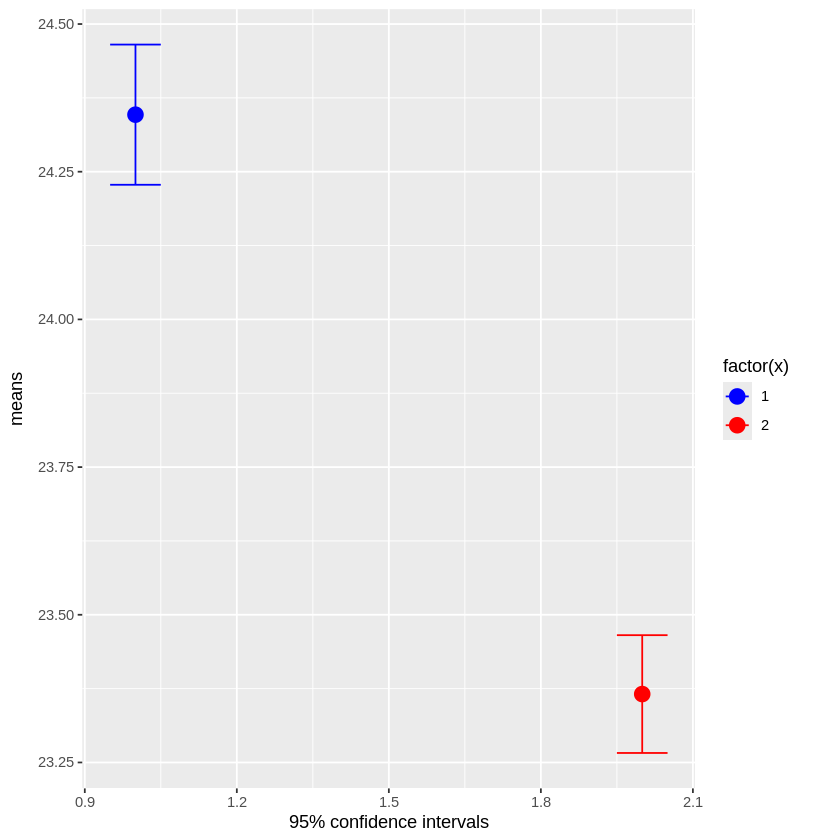

In [ ]:
library(tidyverse)

ggplot(dat, aes(x = x, y = mns, color = factor(x))) +
  geom_errorbar(aes(ymin = low, ymax = upp), width = 0.1) +
  geom_point(size = 4) +
  labs(x = "95% confidence intervals", y = "means") +
  scale_color_manual(values = c("blue", "red"))

###Задача 8
Проверьте на 5%-ном уровне значимости гипотезу о равенстве долей страниц известных людей, относящихся к гуманитарным и техническим наукам. Проинтерпретируйте полученные результаты.

In [ ]:
tech <- sum(popular$domain == 'Science & Technology')
gum <- sum(popular$domain == 'Humanities')
nr <- nrow(popular)
prop.test(c(gum, tech), c(nr,nr))

#p-value составляет 0.4601, что больше 0.05. Это указывает на то, что нет статистически значимых различий между долями страниц известных людей, относящихся к гуманитарным и техническим наукам. Таким образом, у нас нет оснований отвергать нулевую гипотезу о равенстве долей.


	2-sample test for equality of proportions with continuity correction

data:  c(gum, tech) out of c(nr, nr)
X-squared = 0.54573, df = 1, p-value = 0.4601
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.011772452  0.005247454
sample estimates:
   prop 1    prop 2 
0.1171854 0.1204479 


#Практическая работа 15

### Задача 1

Загрузите данные из файла `marketing.csv` и сохраните их в датафрейм `marketing`.

In [ ]:
marketing <- read.csv('/content/датасеты/marketing.csv')

### Задача 2

Используя библиотеку `tidyverse`, определите, сколько фирм использовали разные типы продвижения своей продукции (одно число для каждого типа).

In [ ]:
library(tidyverse)

k_tip <- marketing %>% count(Promotion)
k_tip

Promotion,n
<int>,<int>
1,172
2,188
3,188


### Задача 3

Используя библиотеку `ggplot2`, постройте столбчатую диаграмму, которая показывает, сколько фирм разного масштаба (крупный бизнес, средний бизнес, малый бизнес) представлено в данных. Каких фирм больше?

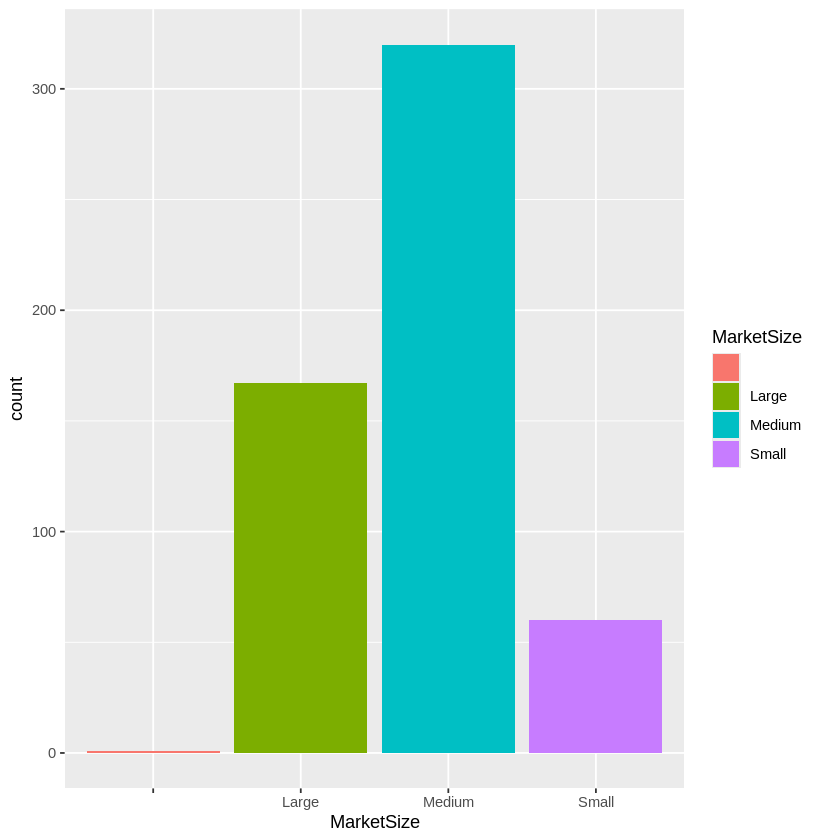

In [ ]:
ggplot(marketing, aes(MarketSize, fill = MarketSize)) + geom_bar()

#Больше всего фирм со средним бизнесом

### Задача 4

Используя библиотеку `ggplot2`, постройте ящики с усами для числа продаж по группам в зависимости от типа продвижения продукции. Разные ящики с усами должны находиться в пределах одного графика и быть разного цвета. Какой тип продвижения продукции, в целом, кажется более успешным? Обоснуйте свой ответ.

Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


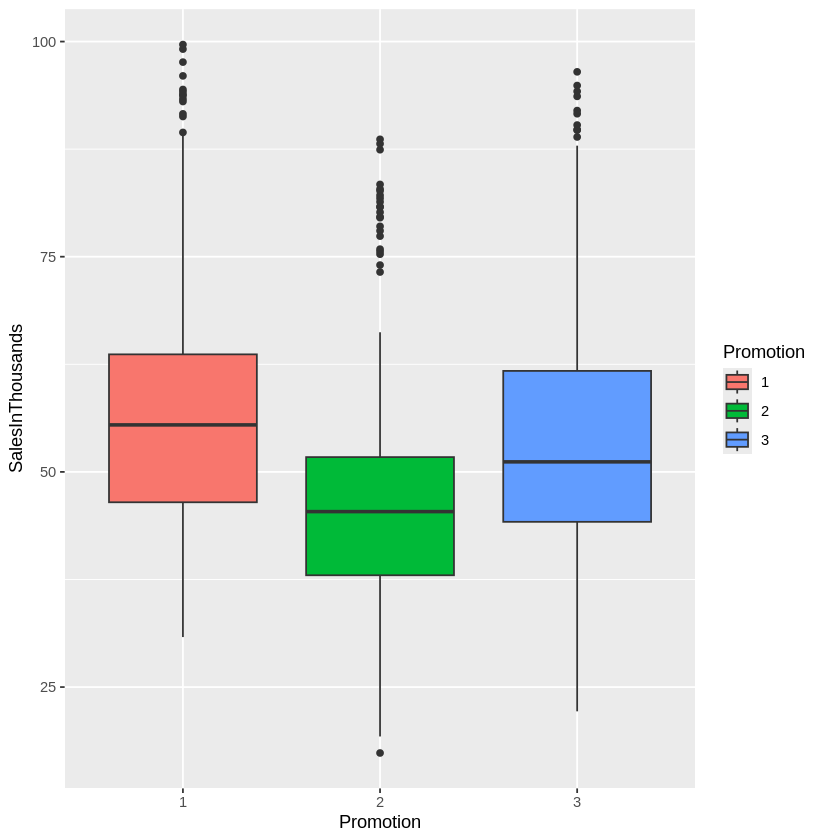

In [ ]:
marketing$Promotion <- as.factor(marketing$Promotion)
ggplot(marketing, aes(x = Promotion, y = SalesInThousands, group = Promotion, fill = Promotion)) +
  geom_boxplot()

#Promotion 1 кажется наиболее успешным, так как он имеет самую высокую медиану и более высокие продажи в среднем по сравнению с другими типами

### Задача 5

Используя функции библиотеки `tidyverse`, выберите из датафрейма `marketing` строки, которые соответствуют фирмам, использующим тип продвижения 1 или 2. Сохраните их в датафрейм `one_two`.

In [ ]:
one_two <- marketing %>% filter(Promotion %in% c(1, 2))
head(one_two)

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,Week,SalesInThousands
,<int>,<chr>,<int>,<int>,<fct>,<int>,<dbl>
1,1,Medium,2,5,2,1,27.81
2,1,Medium,2,5,2,2,34.67
3,1,Medium,2,5,2,3,27.98
4,1,Medium,2,5,2,4,27.72
5,1,Medium,3,12,1,1,NA
6,1,Medium,3,12,1,2,37.94


### Задача 6

Используя подходящий статистический критерий и датафрейм  `one_two`, проверьте, можно ли считать средние (медианные) значения числа продаж равными у тех фирм, которые использовали тип продвижения 1 и 2. Выбор критерия должен быть обоснован – приведены графики распределения, проверка нормальности распределений или рассуждения об объёмах выборок. Сделайте содержательные выводы на основе полученных результатов.

**Подсказка:** функции `t.test()`, `wilcox.test()` и подобные могут принимать на вход формулы вида x ~ group, где x — тестируемый показатель, group — показатель, который содержит деление наблюдений на группы. Например, для встроенного в R датафрейма sleep можно запустить такой код:

```
t.test(extra ~ group, data = sleep)
```

In [ ]:
shapiro.test(one_two$SalesInThousands[one_two$Promotion == '1'])
shapiro.test(one_two$SalesInThousands[one_two$Promotion == '2'])

wilcox.test(one_two$SalesInThousands ~ one_two$Promotion)

#shapiro.test() показал, что распределение в обоих случаях не является нормальным.
# Следовательно мы должны использовать wilcox.test(), применив данный тест на наших данных, мы увидели, что p-value = 3.228e-12. Данный показатель меньше чем 0.05, что дает нам возможность отвергнуть нулевую гипотезу о равенстве средних


	Shapiro-Wilk normality test

data:  one_two$SalesInThousands[one_two$Promotion == "1"]
W = 0.91605, p-value = 2.39e-08



	Shapiro-Wilk normality test

data:  one_two$SalesInThousands[one_two$Promotion == "2"]
W = 0.91427, p-value = 6.065e-09



	Wilcoxon rank sum test with continuity correction

data:  one_two$SalesInThousands by one_two$Promotion
W = 22690, p-value = 3.228e-12
alternative hypothesis: true location shift is not equal to 0


### Задача 7

Используя подходящий статистический критерий и датафрейм `marketing`, проверьте, можно ли считать средние (медианные) значения числа продаж равными у тех фирм, которые использовали тип продвижения 1-4. Выбор критерия должен быть обоснован — приведены графики распределения, проверка нормальности распределений или рассуждения об объёмах выборок. Сделайте содержательные выводы на основе полученных результатов.

Warning message:
“Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`).”



	Shapiro-Wilk normality test

data:  marketing$SalesInThousands[marketing$Promotion == "1"]
W = 0.91605, p-value = 2.39e-08



	Shapiro-Wilk normality test

data:  marketing$SalesInThousands[marketing$Promotion == "2"]
W = 0.91427, p-value = 6.065e-09



	Shapiro-Wilk normality test

data:  marketing$SalesInThousands[marketing$Promotion == "3"]
W = 0.92077, p-value = 1.499e-08



	Kruskal-Wallis rank sum test

data:  marketing$SalesInThousands by marketing$Promotion
Kruskal-Wallis chi-squared = 54.38, df = 2, p-value = 1.554e-12


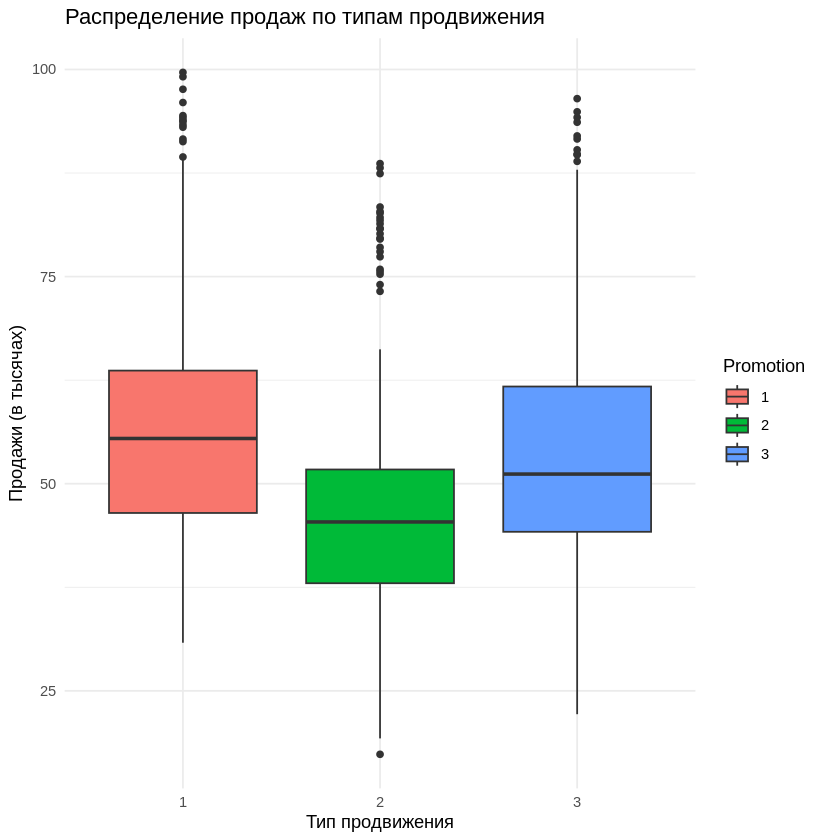

In [ ]:
ggplot(marketing, aes(x = Promotion, y = SalesInThousands, group = Promotion, fill = Promotion)) +
  geom_boxplot() +
  labs(title = "Распределение продаж по типам продвижения", x = "Тип продвижения", y = "Продажи (в тысячах)") +
  theme_minimal()

shapiro.test(marketing$SalesInThousands[marketing$Promotion == '1'])
shapiro.test(marketing$SalesInThousands[marketing$Promotion == '2'])
shapiro.test(marketing$SalesInThousands[marketing$Promotion == '3'])

kraskal <- kruskal.test(marketing$SalesInThousands ~ marketing$Promotion)
kraskal

#Для того чтобы доказать или опровергнуть нашу гипотезу о равенстве. Я провел shapiro.test по каждому типу продвижения, который показал p-value практически равный 0, что говорит нам о не нормальном распределении.
#Это делает использование параметрических тестов, таких как ANOVA, неподходящим.
#Далее я провел kruskal.test, так как у нас не нормальное распределение, который показал p-value практически равный 0.
#Исходя из полученных резульатов можно сделать вывод, что считать средние (медианные) значения числа продаж равными у тех фирм, которые использовали тип продвижения 1-4 нельзя, что и показал нам kruskal.test и график распределения
#В задании написано проверить тип продвижения 1-4, но тип продвижения 4 отсутсвует, поэтому тесты проводились лишь на типах: 1,2,3

### Задача 8

Загрузите данные из файла `library-ab-interact.csv` и сохраните их в датафрейм `lib_int`. Загрузите данные из файла `library-ab-services.csv` и сохраните их в датафрейм `lib_serv`.

In [ ]:
lib_int <- read.csv('/content/датасеты/library-ab-interact.csv')
lib_serv <- read.csv('/content/датасеты/library-ab-services.csv')

### Задача 9

Используя библиотеку `tidyverse`, сделайте так, чтобы столбец Name в датафрейме `lib_int` содержал значения FIND, REQUEST, INTERACT, OTHER, а столбец Name в датафрейме `lib_serv` — значения FIND, REQUEST, SERVICES, OTHER (OTHER для всех остальных названий).

In [ ]:
lib_int <- lib_int %>% mutate(Name = ifelse(Name %in% c('FIND', 'REQUEST', 'INTERACT'), Name, 'OTHER'))
lib_serv <- lib_serv %>% mutate(Name = ifelse(Name %in% c('FIND', 'REQUEST', 'SERVICES'), Name, 'OTHER'))

### Задача 10

Используя библиотеку `ggplot2`, постройте две круговые диаграммы. Первая диаграмма должна показывать проценты кликов на заголовки FIND, REQUEST, INTERACT, OTHER, а вторая диаграмма — проценты кликов на заголовки FIND, REQUEST, SERVICES, OTHER. Можно ли сказать, что на заголовок SERVICES кликают чаще, чем на INTERACT? Приведите ответ на вопрос.

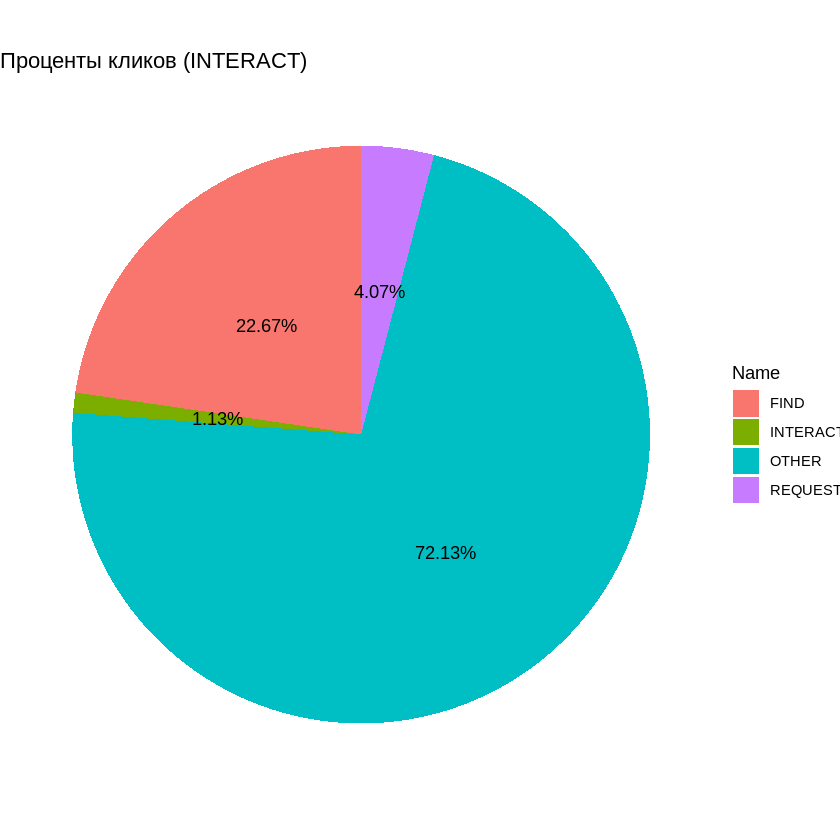

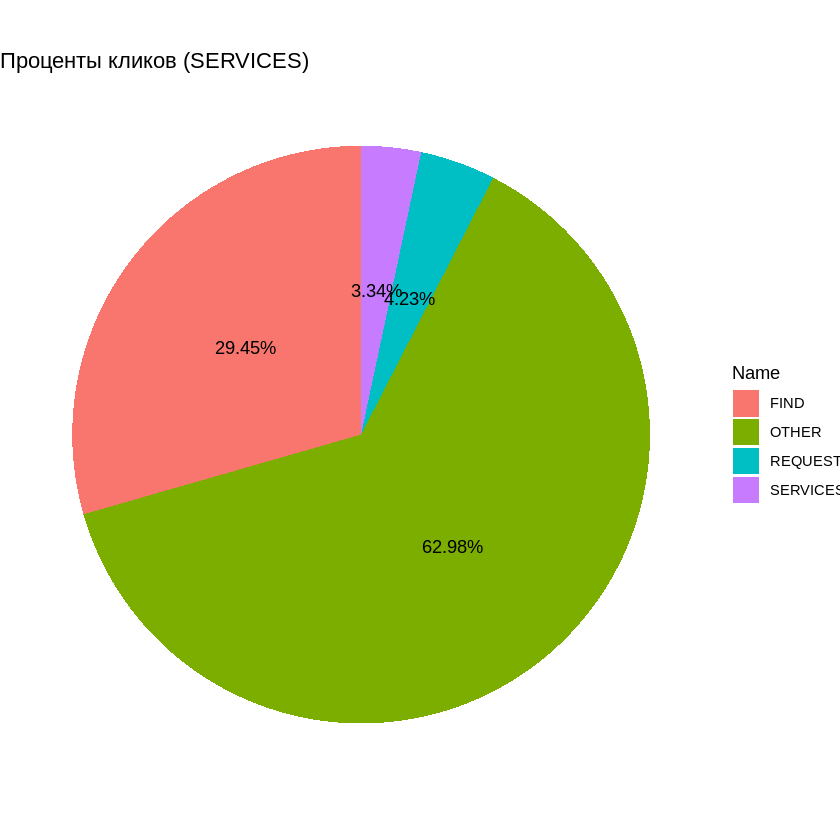

In [ ]:
int_clicks <- lib_int %>%
  group_by(Name) %>%
  summarise(TotalClicks = sum(No..clicks)) %>%
  mutate(Percent = TotalClicks / sum(TotalClicks) * 100)

serv_clicks <- lib_serv %>%
  group_by(Name) %>%
  summarise(TotalClicks = sum(No..clicks)) %>%
  mutate(Percent = TotalClicks / sum(TotalClicks) * 100)


ggplot(int_clicks, aes(x ="", y = Percent, fill = Name)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y") +
  geom_text(aes(label = paste0(round(Percent, 2), "%")), position = position_stack(vjust = 0.5)) +
  labs(title = "Проценты кликов (INTERACT)") +
  theme_void()


ggplot(serv_clicks, aes(x = "", y = Percent, fill = Name)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar("y") +
  geom_text(aes(label = paste0(round(Percent, 2), "%")), position = position_stack(vjust = 0.5)) +
  labs(title = "Проценты кликов (SERVICES)") +
  theme_void()

#Исходя из резульатов круговых диаграмм, нельзя точно сказать, какой критерий кликают чаще, так как у нас мало результатов в таблицах(69 и 53) и количество кликов на SERVICES и на INTERACT составляет маленькое число процентов, тем самым любой клик на одну из этих категорий может резко повысить процент.

### Задача 11

Используя подходящий статистический критерий, проверьте, можно ли считать, что на заголовок SERVICES кликают чаще, чем на заголовок INTERACT. Сделайте содержательные выводы на основе полученных результатов. Можно ли считать, что выбор заголовка SERVICES для ссылки на страницу услуг библиотеки будет более удачным, чем использование текущего заголовка INTERACT?

In [ ]:
int_clicks_k <- sum(lib_int$No..clicks[lib_int$Name == 'INTERACT'])
serv_clicks_k <- sum(lib_serv$No..clicks[lib_serv$Name == 'SERVICES'])

total_int <- sum(lib_int$No..clicks)
total_serv <- sum(lib_serv$No..clicks)

result <- prop.test(c(int_clicks_k, serv_clicks_k), c(total_int, total_serv), alternative = 'less')
print(result)

#Очень низкое p-value позволяет с уверенностью говорить, что заголовок SERVICES получает больше кликов по сравнению с INTERACT;
#Оценка доли кликов показывает, что у SERVICES (prop 2 = 0.03338) доля кликов выше, чем у INTERACT (prop 1 = 0.01108);
#На основании этих данных можно утверждать, что использование заголовка SERVICES для ссылки на страницу услуг библиотеки будет более удачным решением.


	2-sample test for equality of proportions with continuity correction

data:  c(int_clicks_k, serv_clicks_k) out of c(total_int, total_serv)
X-squared = 27.239, df = 1, p-value = 8.99e-08
alternative hypothesis: less
95 percent confidence interval:
 -1.00000000 -0.01302995
sample estimates:
    prop 1     prop 2 
0.01130856 0.03338279 



#Практическая работа 16

## Задача 1

Загрузите данные из файла `DB.xlsx` и сохраните их в датафрейм `db`.

In [ ]:
library(readxl)
db <- read_xlsx('/content/датасеты/DB.xlsx')

## Задача 2

Используя возможности библиотеки `tidyverse`, создайте таблицу, которая содержит следующие характеристики: количество опрошенных мужчин, количество опрошенных женщин, средний возраст опрошенных мужчин, стандартное отклонение возраста опрошенных мужчин, средний возраст опрошенных женщин, стандартное отклонение возраста опрошенных женщин.

In [ ]:
library(tidyverse)
tab <- db %>% group_by(Gender) %>% summarise(count = n(), mean_age = mean(Age, na.rm = TRUE), sd_age = sd(Age, na.rm = TRUE))
tab

Gender,count,mean_age,sd_age
<chr>,<int>,<dbl>,<dbl>
Female,703,37.08393,14.24901
Male,241,37.69295,15.22160


## Задача 3

Вычислите коэффициент корреляции Пирсона между показателями `SEC` и `Forgiveness`. Проверьте на 5%-ном уровне значимости, является ли коэффициент корреляции между этими показателями отличным от нуля. Сделайте содержательные выводы.

In [ ]:
cor.test(db$SEC, db$Forgiveness)

#Коэффициент корреляции между этими показателями является отличным от нуля(p-value = 2.52e-07);
#Коэффициент корреляции 0.1668625 указывает на слабую положительную взаимосвязь между SEC и Forgiveness. Хотя они взаимосвязаны, и эта связь не сильная


	Pearson's product-moment correlation

data:  db$SEC and db$Forgiveness
t = 5.1942, df = 942, p-value = 2.52e-07
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1041653 0.2282387
sample estimates:
      cor 
0.1668625 


## Задача 4

Используя `ggplot2`, постройте диаграмму рассеивания для показателей `SEC` и `Curiosity`. Сделайте так, чтобы цвет точек на этой диаграмме зависел от пола респондента. Используя полученную диаграмму, сделайте вывод, какой коэффициент корреляции, Пирсона или Спирмена, уместно использовать в данном случае.

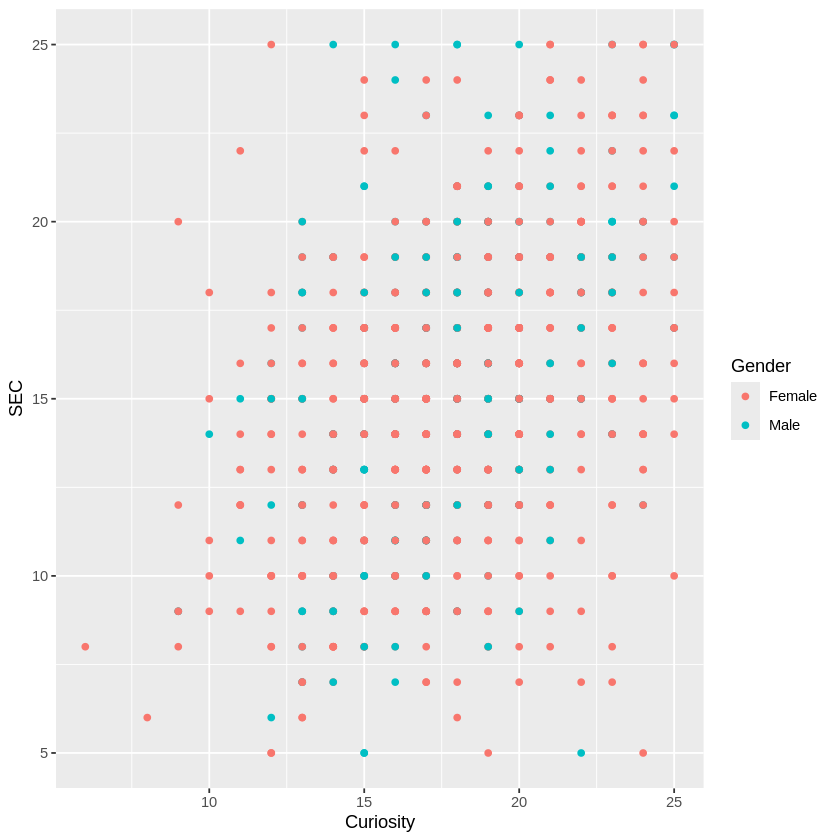

In [ ]:
ggplot(db, aes(Curiosity, SEC, color = Gender)) + geom_point()

#Коэффициент корреляции Спирмена более уместен в данном случае, так как взаимосвязь между данными, скорее всего, не линейная (по графику), и распределение переменных может отклоняться от нормального. Использование Пирсона в текущей ситуации может исказить результат

## Задача 5

Вычислите подходящий коэффициент корреляции между показателями `SEC` и `Curiosity`. Проверьте на 1%-ном уровне значимости, является ли коэффициент корреляции между этими показателями отличным от нуля. Сделайте содержательные выводы.

In [ ]:
cor.test(db$Curiosity, db$SEC, method = 'spearman', conf.level = 0.99)

#Данный тест показал нам, что на 1%-ном уровне значимости, коэффициент корреляции между этими показателями можно считать отличным от нуля. А это значит, что между показателями `SEC` и `Curiosity` есть связь на 1%-ном уровне значимости;
#rho = 0.3511274, говорит нам о том, что с увеличением показателя, другой также имеет тенденцию к увеличению, хотя связь между ними не является очень сильной, а скорее умеренной

Warning message in cor.test.default(db$Curiosity, db$SEC, method = "spearman", conf.level = 0.99):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  db$Curiosity and db$SEC
S = 90975332, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.3511274 


## Задача 6

Вычислите коэффициент корреляции между показателями `DASS_21` и `Spirituality`. Проверьте на 5%-ном уровне значимости, является ли коэффициент корреляции между этими показателями отличным от нуля. Сделайте содержательные выводы.

In [ ]:
shapiro.test(db$DASS_21)
shapiro.test(db$Spirituality)
cor.test(db$DASS_21, db$Spirituality, method = 'spearman')
#Проведя тест Спирмена, так как оба показателя показывают не нормальное распределение. Я выяснил, что на 5%-ном уровне значимости, коэффициент корреляции между этими показателями является отличным от нуля(p-value = 1.421e-12);
#rho  = -0.2277658, говорит нам о том, что между этими показателями есть слабая обратная(убывающая) связь


	Shapiro-Wilk normality test

data:  db$DASS_21
W = 0.90906, p-value < 2.2e-16



	Shapiro-Wilk normality test

data:  db$Spirituality
W = 0.98985, p-value = 4.133e-06


Warning message in cor.test.default(db$DASS_21, db$Spirituality, method = "spearman"):
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  db$DASS_21 and db$Spirituality
S = 172139195, p-value = 1.421e-12
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.2277658 


## Задача 7

Выберите любые четыре интересующих вас количественных показателя в датафрейме и, используя библиотеку `corrplot`, постройте визуализацию для корреляционной матрицы выбранных показателей, которая бы отражала не только величину коэффициентов, но и их значимость на 1%-ном уровне значимости.

In [ ]:
install.packages('corrplot')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



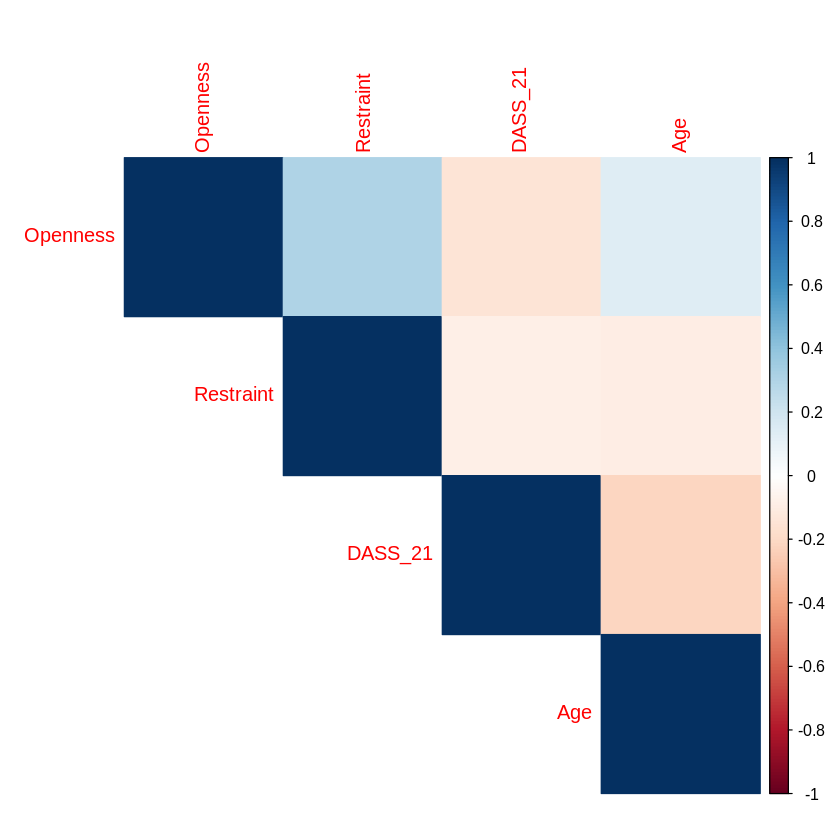

In [ ]:
library(corrplot)

pokazatel_4 <- db[, c('Openness', 'Restraint', 'DASS_21', 'Age')]
cor_mat <- cor(pokazatel_4, method = 'spearman')
corrplot(cor_mat, method = 'color', type = 'upper', sig.level = 0.01)

## Задача 8

Постройте модель простой линейной регрессии, которая бы описывала взаимосвязь между возрастом и ощущаемым уровнем депрессии и стресса в течение пандемии (`DASS_21`). Определите самостоятельно, какая переменная является зависимой, а какая ― независимой в этой модели. Проинтерпретируйте полученные результаты. Ваша интерпретация должна включать ответы на следующие вопросы:

* Есть ли значимая взаимосвязь между возрастом и ощущаемым уровнем депрессии и стресса?
* Как в среднем изменяется ощущаемый уровень депрессии и стресса при увеличении возраста человека на один год?

In [ ]:
summary(lm(db$DASS_21 ~ db$Age))

#Да, значимая взаимосвязь между возрастом и уровнем депрессии и стресса есть;
#P-значение для переменной db$Age равно 6.44e-13, что значительно меньше уровня значимости 0.05. Это позволяет отклонить нулевую гипотезу и утверждать, что возраст действительно оказывает влияние на уровень DASS_21;
#Однако значение R-squared = 0.05344 указывает на то, что возраст объясняет лишь 5.34% изменчивости уровней депрессии и стресса. Таким образом, хотя связь является статистически значимой, она не является сильной;
#Коэффициент для переменной db$Age равен -0.17058, что означает с увеличением возраста на один год уровень DASS_21 в среднем уменьшается на 0.17058 единицы.


Call:
lm(formula = db$DASS_21 ~ db$Age)

Residuals:
    Min      1Q  Median      3Q     Max 
-17.700  -7.606  -2.030   5.272  43.982 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 21.45296    0.93467  22.952  < 2e-16 ***
db$Age      -0.17058    0.02339  -7.293 6.44e-13 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 10.41 on 942 degrees of freedom
Multiple R-squared:  0.05344,	Adjusted R-squared:  0.05244 
F-statistic: 53.18 on 1 and 942 DF,  p-value: 6.437e-13


## Задача 9

Используя построенную модель, запишите предсказанное ею значение уровня ощущаемого уровня стресса для человека 27 лет. Используя функции для описательных статистик, укажите, полученное значение выше среднего значения показателя по выборке или нет.

In [ ]:
install.packages('psych')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(psych)
# y = k*x + b
predskaz <- -0.17058 * 27 + 21.45296
print(predskaz)
describe(db$DASS_21)
#Полученное значение выше среднего значения показателя по выборке
#Данные: -0.17058 и 21.45296 взял из результатов предыдущей задачи

[1] 16.8473


,vars,n,mean,sd,median,trimmed,mad,min,max,range,skew,kurtosis,se
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
X1,1,944,15.10064,10.69779,13,13.7672,8.8956,0,61,61,1.241925,1.685158,0.3481833


## Задача 10

Запишите $R^2$ полученной модели. Что можно сказать о предсказательной силе модели? Запишите ваш ответ.

In [ ]:
summary(lm(db$DASS_21 ~ db$Age))$r.squared
#Коэффициент R^2 равен 0.05344, то есть модель объясняет только около 5.34% изменчивости зависимой переменной;
#Предсказательная сила модели слабая, так как значение R^2 очень низкое. Это значит, что связь между переменными незначительна, и данная модель имеет низкую способность предсказывать зависимую переменную.

[1] 0.05344067

## Задача 11

Проведите анализ остатков (ошибок) модели. Сделайте выводы относительно качества модели.


	Shapiro-Wilk normality test

data:  residuals
W = 0.92558, p-value < 2.2e-16


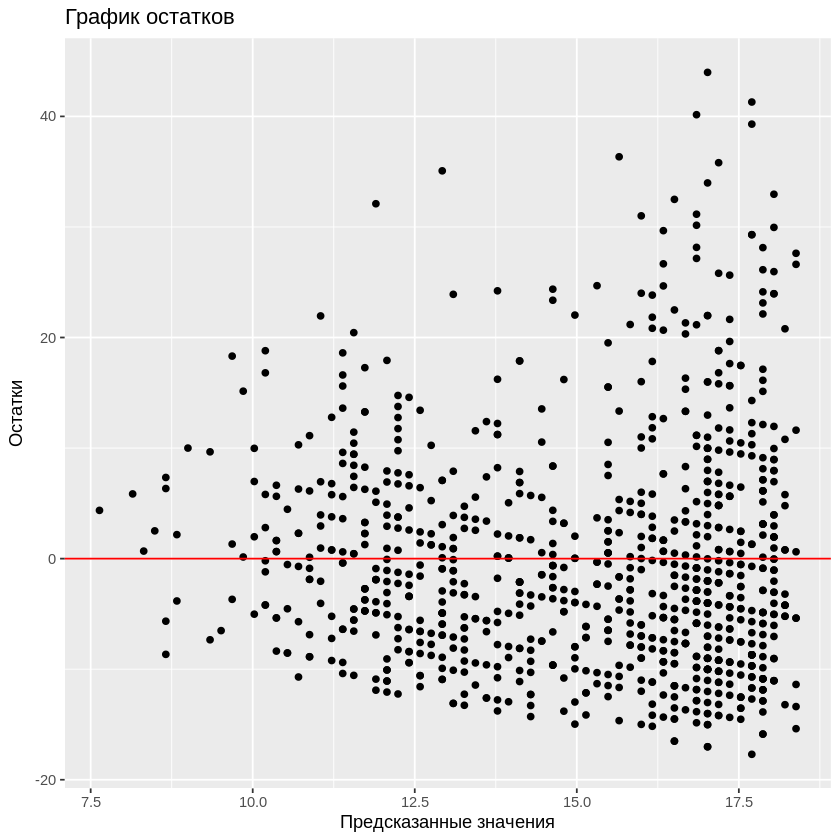

In [ ]:
model <- lm(db$DASS_21 ~ db$Age)
residuals <- model$residuals
fitted <- model$fitted.values

ggplot() +
  geom_point(aes(x = fitted, y = residuals)) +
  geom_hline(yintercept = 0, color = "red") +
  labs(x = "Предсказанные значения", y = "Остатки", title = "График остатков")

shapiro.test(residuals)
#Остатки имеют распределение, отклоняющееся от нормального;
#Плохая объясняющая способность (из задачи 10, R^2 ~ 5.34%)
#Модель не соответствует ряду базовых требований линейной регрессии, что указывает на ее низкое качество и недостоверность

## Задача 12

Используя подходящий статистический критерий, проверьте на 5%-ном уровне значимости, есть ли связь между полом человека и его оценкой изменения положения на работе после начала пандемии (`Work`, где 1 ― совсем не изменилось, 6 ― изменилось значительно). Сделайте содержательные выводы.


	Shapiro-Wilk normality test

data:  db$Work[db$Gender == "Male"]
W = 0.92871, p-value = 2.189e-09



	Shapiro-Wilk normality test

data:  db$Work[db$Gender == "Female"]
W = 0.92218, p-value < 2.2e-16



	Wilcoxon rank sum test with continuity correction

data:  db$Work by db$Gender
W = 86455, p-value = 0.6275
alternative hypothesis: true location shift is not equal to 0


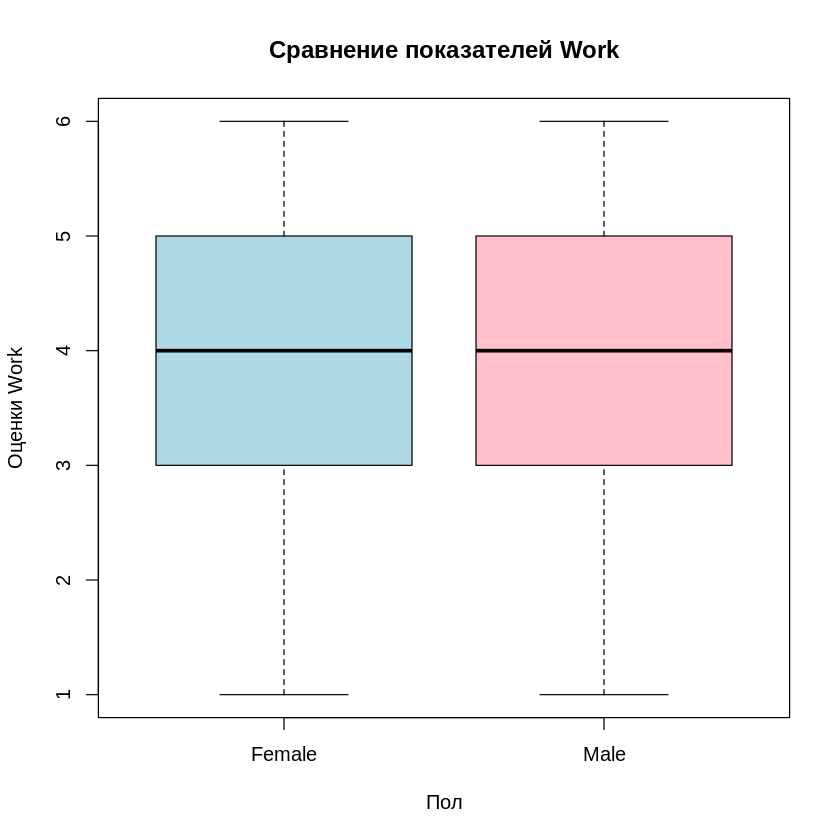

In [ ]:
shapiro.test(db$Work[db$Gender == 'Male'])
shapiro.test(db$Work[db$Gender == 'Female'])

wilcox.test(db$Work ~ db$Gender)
boxplot(Work ~ Gender, data = db, main = "Сравнение показателей Work",
        xlab = "Пол", ylab = "Оценки Work", col = c("lightblue", "pink"))
#wilcox.test показал, что p-value = 0.6275, а это значит, что различий между полом человека и его оценкой измненения положения на работе после начала пандемии, нет. И нет оснований отвергать нулевую гипотезу о равенстве;
#Тот же самый вывод можно сделать и по графику boxplot:
#График "boxplot" показывает распределение оценок "Work" для мужчин и женщин:
#Средние значения и медианы выглядят сопоставимыми.
#Межквартильные размахи (IQR) также схожи.
#Нет большого визуального различия между полами в этом показателе.

#Практическая работа 17

## Задача 1

Загрузите данные из файла `Consumo_cerveja.csv` и сохраните их в датафрейм `beer`.

In [ ]:
beer <- read.csv('/content/датасеты/Consumo_cerveja.csv', dec=',')

## Задача 2

Постройте модель линейной регрессии, которая объясняет, каким образом объём потребляемого пива зависит от средней температуры воздуха в конкретный день, уровня атмосферных осадков и того, приходится ли день на конец недели. Выведите описание модели. Приведите содержательную интерпретацию каждого коэффициента в полученной модели. Интерпретация должна включать указание на то, является ли эффект независимой переменной статистически значимым, а также пояснение, что происходит с зависимой переменной при увеличении независимой на единицу.

In [ ]:
beer = na.omit(beer)
mod_len <- lm(data = beer, Consumo.de.cerveja..litros. ~ Temperatura.Media..C. + Precipitacao..mm. + Final.de.Semana)
summary(mod_len)

#Temperatura.Media..C. (0.83971):
#Положительный коэффициент указывает, что при увеличении средней температуры на 1 потребление пива вырастает на 0.84 литра.
#Значение p-value (<2e-16) свидетельствует о статистической значимости этого эффекта.
#
#Precipitacao..mm. (-0.07420):
#Отрицательный коэффициент указывает, что с увеличением уровня атмосферных осадков на 1 потребление пива уменьшается на 0.074 литра.
#Значение p-value (3.51e-11) свидетельствует о статистической значимости этого эффекта.
#
#Final.de.Semana (5.22787):
#Положительный коэффициент указывает, что в выходной день объем потребления пива возрастает на 5.23 литра по сравнению с обычным днем.
#Значение p-value (<2e-16) подтверждает статистическую значимость этого эффекта.


Call:
lm(formula = Consumo.de.cerveja..litros. ~ Temperatura.Media..C. + 
    Precipitacao..mm. + Final.de.Semana, data = beer)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.4802 -2.0347 -0.1904  1.8908  6.5165 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)            6.47348    0.91957   7.040 9.77e-12 ***
Temperatura.Media..C.  0.83971    0.04245  19.782  < 2e-16 ***
Precipitacao..mm.     -0.07420    0.01086  -6.835 3.51e-11 ***
Final.de.Semana        5.22787    0.29855  17.511  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.571 on 361 degrees of freedom
Multiple R-squared:  0.6612,	Adjusted R-squared:  0.6584 
F-statistic: 234.8 on 3 and 361 DF,  p-value: < 2.2e-16


## Задача 3

Используя данные из столбца `Data`, добавьте в датафрейм `beer` столбец `Month`, отвечающий за месяц, в котором проводились наблюдения. Столбец должен содержать текстовые значения вида «01», «02», «03», и так далее.

In [ ]:
library(tidyverse)
beer <- beer %>%
  mutate(Data = as.Date(Data, format = "%Y-%m-%d")) %>%
  mutate(Month = format(Data, "%m"))

head(beer)

,Data,Temperatura.Media..C.,Temperatura.Minima..C.,Temperatura.Maxima..C.,Precipitacao..mm.,Final.de.Semana,Consumo.de.cerveja..litros.,Month
,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<chr>
1,2015-01-01,27.30,23.9,32.5,0.0,0,25.461,01
2,2015-01-02,27.02,24.5,33.5,0.0,0,28.972,01
3,2015-01-03,24.82,22.4,29.9,0.0,1,30.814,01
4,2015-01-04,23.98,21.5,28.6,1.2,1,29.799,01
5,2015-01-05,23.82,21.0,28.3,0.0,0,28.900,01
6,2015-01-06,23.78,20.1,30.5,12.2,0,28.218,01


## Задача 4

Добавьте в построенную модель переменную `Month` и оцените модель ещё раз. Выведите описание модели. Какой месяц выбран R в качестве базовой категории? Потребление пива в какие месяцы значимо отличается от потребления пива в «базовом» месяце?

In [ ]:
mod_len_updated <- lm(data = beer, Consumo.de.cerveja..litros. ~ Temperatura.Media..C. + Precipitacao..mm. + Final.de.Semana + Month)
summary(mod_len_updated)
#В качестве базовой категории выбран Month01
#Все месяца, кроме 08,10,02 вообще не являются статистическими значимыми, 02 значимо на 0.1 уровне, 08 на 0.05, 10 на 0.01 уровне значимости.
#Сильно разнятся значения в 02 месяце(кол-во выпитого пива уменьшается на 1.18515 литра), в 06 месяце(кол-во литров увеличивается на 1.23606), в 08 месяце( кол-во литров увеличивается на 1.59790), в 10 месяце(кол-во литров увеличивается на 1.82816)


Call:
lm(formula = Consumo.de.cerveja..litros. ~ Temperatura.Media..C. + 
    Precipitacao..mm. + Final.de.Semana + Month, data = beer)

Residuals:
   Min     1Q Median     3Q    Max 
-5.385 -1.800 -0.298  1.748  7.323 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)            4.75934    1.55047   3.070  0.00231 ** 
Temperatura.Media..C.  0.90063    0.05814  15.491  < 2e-16 ***
Precipitacao..mm.     -0.06312    0.01110  -5.685 2.76e-08 ***
Final.de.Semana        5.24991    0.28846  18.200  < 2e-16 ***
Month02               -1.18515    0.65412  -1.812  0.07087 .  
Month03               -0.53411    0.65411  -0.817  0.41474    
Month04               -0.07453    0.68537  -0.109  0.91347    
Month05               -0.30007    0.74199  -0.404  0.68616    
Month06                1.23606    0.76512   1.616  0.10710    
Month07                0.48159    0.76454   0.630  0.52916    
Month08                1.59790    0.70594   2.263  0.02422 *  
Month09 

## Задача 5

Укажите, чему равен R-квадрат полученной модели. Проинтерпретируйте значение R-квадрата для данной модели.

In [ ]:
r_squared <- summary(mod_len_updated)$r.squared
print(r_squared)

#Для данной модели R-квадрат составляет 0.6948029, что больше половины, а следовательно можно скзаать, что данная модель имеет высокую предсказательную способность.

[1] 0.6948029


## Задача 6

Проведите исследования качества обновлённой модели: проверьте её на наличие мультиколлинеарности, гетероскедастичности и влиятельных наблюдений. Если будут выявлены проблемы, устраните их (пересчитайте коэффициенты, устойчивые к гетероскедастичности, удалите влиятельные наблюдения и оцените модель ещё раз). Если после корректировки модели произошли существенные изменения, поясните, в чём они заключаются.

,Temperatura.Media..C.,Precipitacao..mm.,Final.de.Semana
Temperatura.Media..C.,1.00000000,0.024415759,-0.050802956
Precipitacao..mm.,0.02441576,1.000000000,0.001586772
Final.de.Semana,-0.05080296,0.001586772,1.000000000


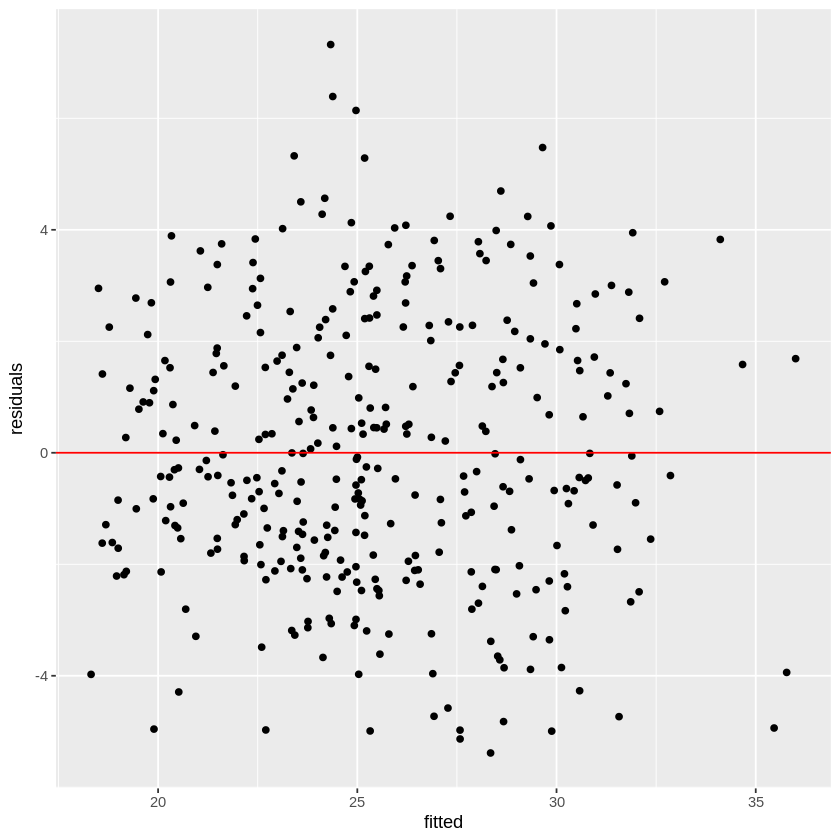

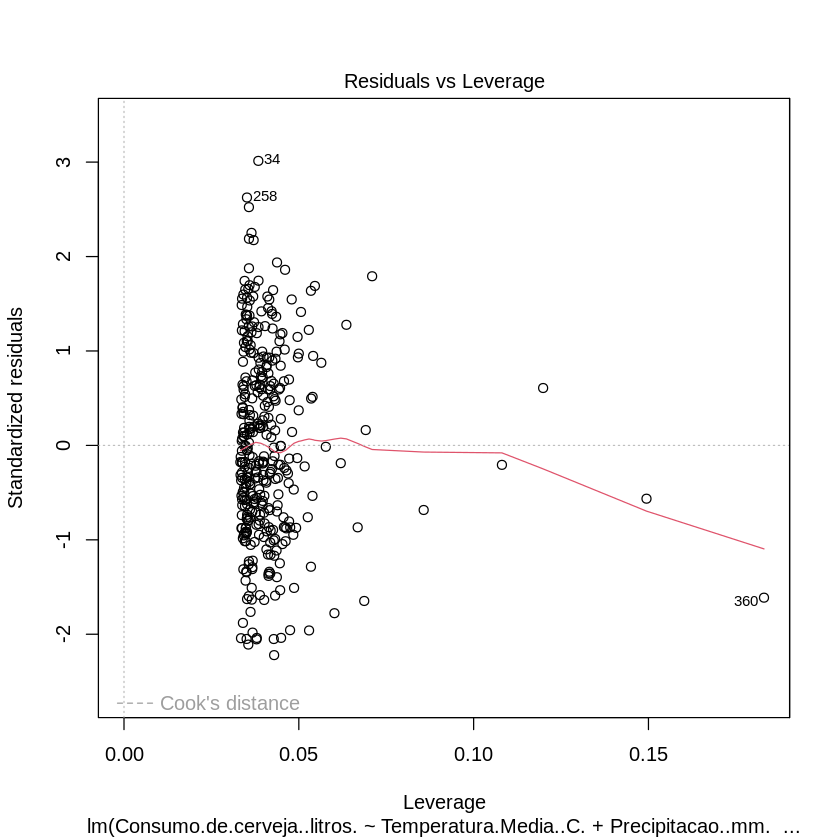

In [ ]:
#мультиколлинеарность
mod_len_small <- beer %>% select(Temperatura.Media..C., Precipitacao..mm., Final.de.Semana)
cor(mod_len_small)
#Судя по значениям корреляции ничего подозрительного похожего на мультиколлинеарность здесь не наблюдается.

#гетероскедастичность
beer$fitted <- mod_len_updated$fitted.values
beer$residuals = mod_len_updated$residuals
ggplot(data=beer, aes(x=fitted, y=residuals)) + geom_point() + geom_hline(yintercept = 0, color='red')
#гетероскедастичности не наблюдается.

#влиятельные наблюдения
plot(mod_len_updated, 5)
#На данном графике не наблюдается влиятельных наблюдений, так как чаще всего они располагаются в верхнем правом углу

## Задача 7

Загрузите данные из файла `diabetes.csv` и сохраните их в датафрейм `diabet`.

In [ ]:
diabet <- read.csv('/content/датасеты/diabetes.csv')

## Задача 8

Выведите описательные статистики по всем столбцам датафрейма. Если среди описательных статистик встречаются заведомо невозможные значения (например, давление, равное 0), удалите соответствующие им строки из датафрейма.

  Pregnancies        Glucose      BloodPressure    SkinThickness  
 Min.   : 0.000   Min.   :  0.0   Min.   :  0.00   Min.   : 0.00  
 1st Qu.: 1.000   1st Qu.: 99.0   1st Qu.: 62.00   1st Qu.: 0.00  
 Median : 3.000   Median :117.0   Median : 72.00   Median :23.00  
 Mean   : 3.845   Mean   :120.9   Mean   : 69.11   Mean   :20.54  
 3rd Qu.: 6.000   3rd Qu.:140.2   3rd Qu.: 80.00   3rd Qu.:32.00  
 Max.   :17.000   Max.   :199.0   Max.   :122.00   Max.   :99.00  
    Insulin           BMI        DiabetesPedigreeFunction      Age       
 Min.   :  0.0   Min.   : 0.00   Min.   :0.0780           Min.   :21.00  
 1st Qu.:  0.0   1st Qu.:27.30   1st Qu.:0.2437           1st Qu.:24.00  
 Median : 30.5   Median :32.00   Median :0.3725           Median :29.00  
 Mean   : 79.8   Mean   :31.99   Mean   :0.4719           Mean   :33.24  
 3rd Qu.:127.2   3rd Qu.:36.60   3rd Qu.:0.6262           3rd Qu.:41.00  
 Max.   :846.0   Max.   :67.10   Max.   :2.4200           Max.   :81.00  
    Outcome  

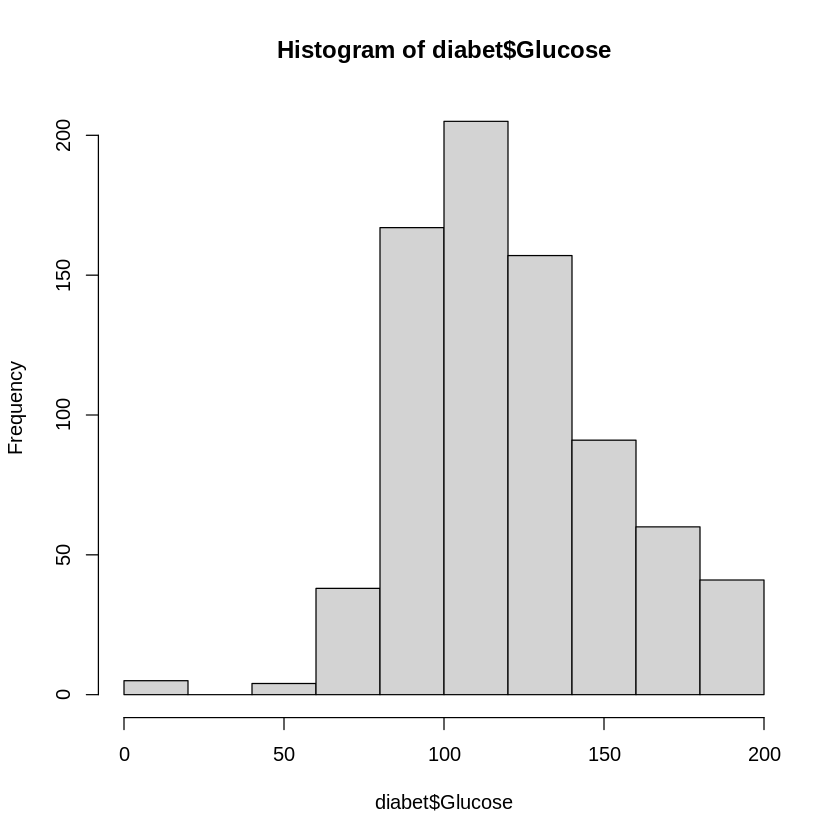

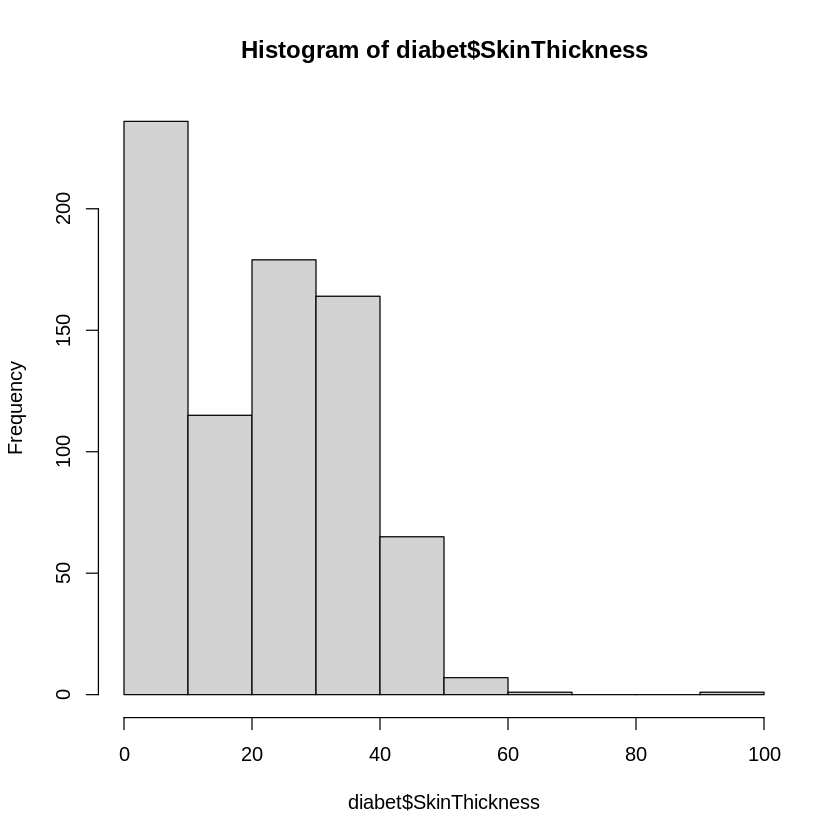

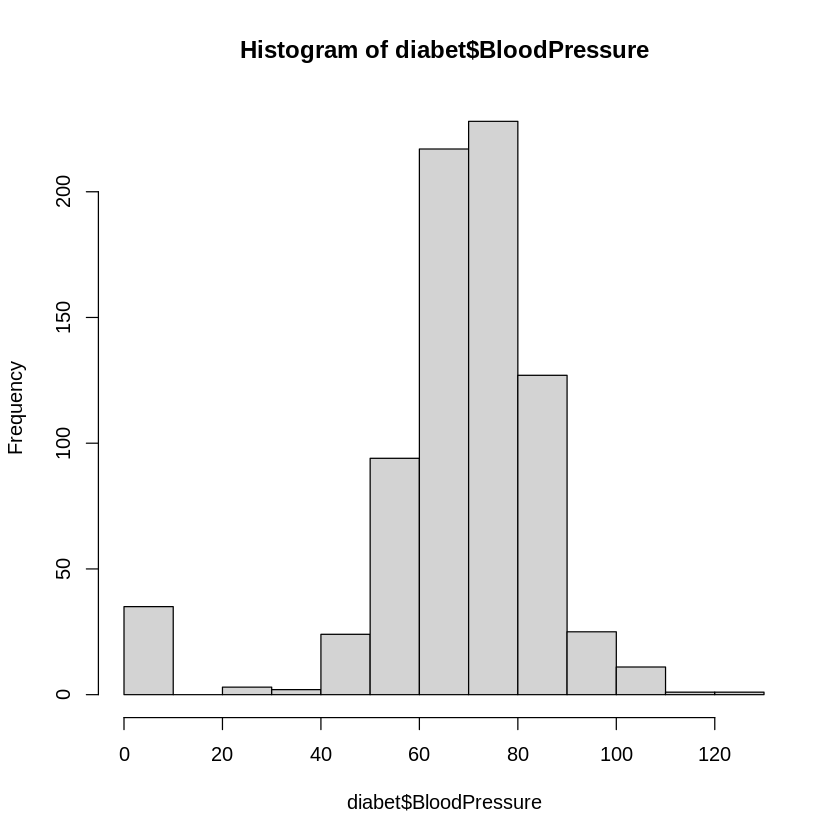

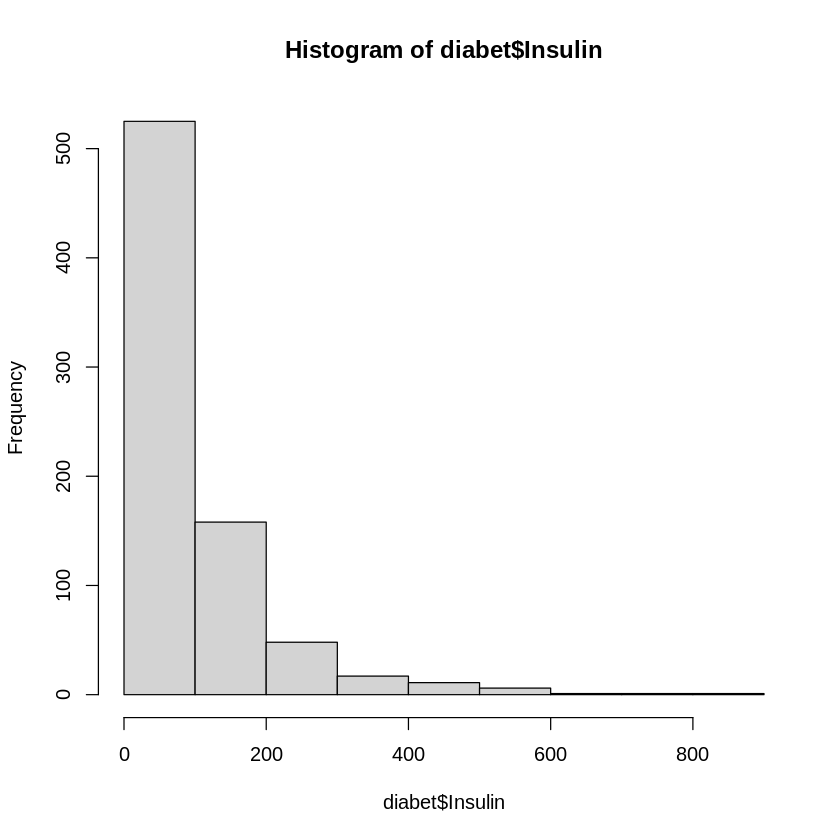

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>
1,1,85,66,29,0,26.6,0.351,31,0
2,5,166,72,19,175,25.8,0.587,51,1
3,1,97,66,15,140,23.2,0.487,22,0
4,3,88,58,11,54,24.8,0.267,22,0
5,4,103,60,33,192,24.0,0.966,33,0
6,1,103,80,11,82,19.4,0.491,22,0


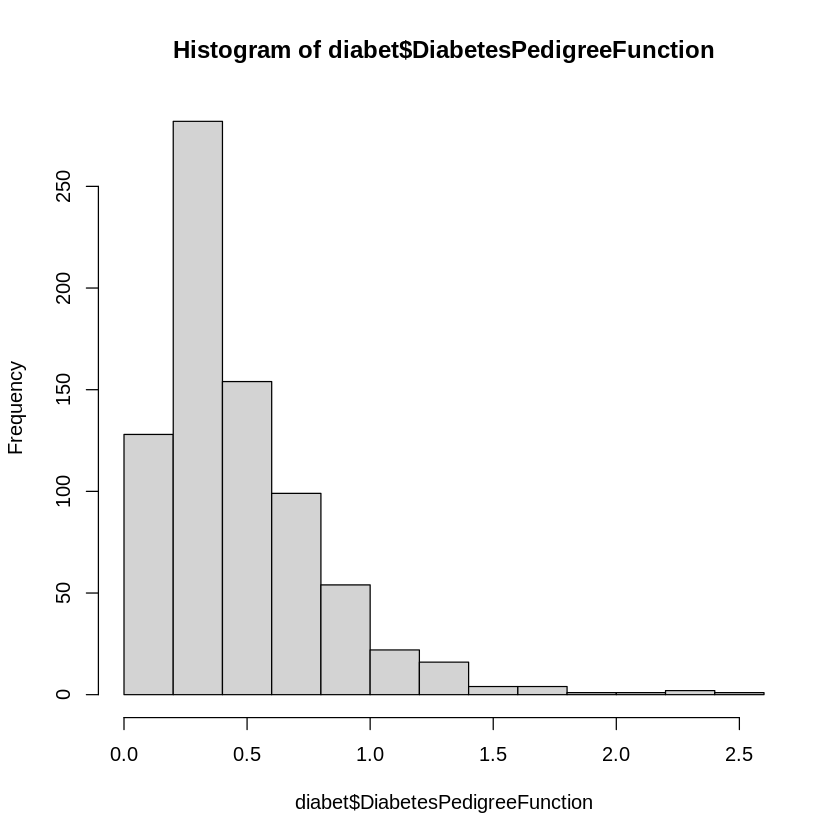

In [ ]:
summary(diabet)

hist(diabet$Glucose)

hist(diabet$SkinThickness)

hist(diabet$BloodPressure)

hist(diabet$Insulin)

hist(diabet$DiabetesPedigreeFunction)

diabet = diabet %>%
  filter(
    Pregnancies <= 6,
    BloodPressure > 20 & BloodPressure < 130,
    Insulin <= 600,
    BMI < 27.30,
    DiabetesPedigreeFunction < 1.5,
    Glucose > 50,
    SkinThickness > 0 & SkinThickness < 60
  )

head(diabet)
#Исходя из графиков и описательной статистики, я выявил заведомое невозможные значения и отфильтровал их
#Скорее всего они произошли либо из-за ошибки пользователя, который вводил ответ или ошибки системы опроса

## Задача 9

Определите, сколько в датафрейме строк, соответствующих женщинам, больным диабетом, и сколько строк, соответствующих здоровым женщинам.

In [ ]:
k_female_diabet_yes <- diabet %>% filter(Outcome == 1) %>% nrow()
k_female_diabet_no <- diabet %>% filter(Outcome == 0) %>% nrow()
print(k_female_diabet_yes)
print(k_female_diabet_no)

#Болеющих диабетом женщин: 6
#Здоровые женщины: 89

[1] 6
[1] 89


## Задача 10

Постройте регрессионную модель, которая объясняет, каким образом заболеваемость диабетом зависит от уровня глюкозы в крови, кровяного давления, уровня инсулина, индекса массы тела и возраста человека. Выведите описание этой модели. Какие переменные в модели оказались статистически незначимыми? Укажите их.

In [ ]:
logist_mod <- glm(data = diabet, Outcome ~ Glucose + BloodPressure + Insulin + BMI + Age,
                  family = "binomial")

summary(logist_mod)
exp(coef(logist_mod))
#Статистически незначимыми оказались переменные: BloodPressure и Insulin


Call:
glm(formula = Outcome ~ Glucose + BloodPressure + Insulin + BMI + 
    Age, family = "binomial", data = diabet)

Coefficients:
               Estimate Std. Error z value Pr(>|z|)  
(Intercept)   -25.72674   12.46325  -2.064   0.0390 *
Glucose         0.10432    0.04397   2.373   0.0177 *
BloodPressure  -0.07834    0.06719  -1.166   0.2436  
Insulin        -0.02043    0.01251  -1.633   0.1024  
BMI             0.43291    0.38181   1.134   0.2569  
Age             0.24141    0.12133   1.990   0.0466 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 44.758  on 94  degrees of freedom
Residual deviance: 24.359  on 89  degrees of freedom
AIC: 36.359

Number of Fisher Scoring iterations: 8


(Intercept)       Glucose BloodPressure       Insulin           BMI 
 6.714602e-12  1.109957e+00  9.246465e-01  9.797779e-01  1.541742e+00 
          Age 
 1.273037e+00

## Задача 11

Используя полученные в модели коэффициенты, объясните:
* как в среднем изменяются шансы человека заболеть диабетом при увеличении индекса массы тела на единицу;
* как в среднем изменяются шансы человека заболеть диабетом при увеличении нижнего давления при увеличении индекса массы тела на единицу.

In [ ]:
exp(0.080774)
exp(-0.002550)
# 1) Влияние BMI
# Коэффициент при BMI равен 0.080774. Это означает, что при увеличении BMI на единицу логарифм отношения шансов (log odds) увеличивается на 0.080774;
#при увеличении BMI на 1 единицу отношение шансов заболеть диабетом возрастает примерно на 8.4%.
#
# 2) Влияние нижнего давления (BloodPressure)
# Коэффициент при BloodPressure равен -0.002550, однако он статистически не значим (p-value = 0.823317). Это значит, что влияние давления на вероятность заболеть диабетом нельзя достоверно утверждать, согласно данной модели;
#При увеличении давления на 1 единицу шансы заболеть диабетом уменьшались бы на 0.26%. Однако это влияние не стоит интерпретировать всерьез, поскольку коэффициент статистически незначим.
#
# 3) Совокупное влияние BMI и давления
#  BMI оказывает значимое влияние: каждая единица увеличивает шансы заболеть диабетом примерно на 8.4%.
# Влияние кровяного давления на вероятность заболеть диабетом в данной модели статистически не доказано.

[1] 1.084126

[1] 0.9974532

## Задача 12

Посчитайте как минимум два показателя качества полученной модели. Используя полученные результаты, сделайте выводы о качестве модели.

In [ ]:
install.packages('caret')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(caret)

y_test = diabet[, c(1,2,3,4,5,6,8)]
y_true = diabet$Outcome
pred_probas = predict(logist_mod, newdata=y_test, type="response")
y_pred = ifelse(pred_probas > 0.5, 1, 0)
confusion_matrix <- confusionMatrix(factor(y_pred), factor(y_true))

print(confusion_matrix)

recall = confusion_matrix$byClass["Sensitivity"]
recall
precision = confusion_matrix$byClass["Specificity"]
precision

# Метрика accuracy (доля верно предсказанных значений среди общего числа наблюдений) составляет 0.9684. Это означает, что модель в большинстве случаев правильно классифицирует объекты.
#
#Recall (полнота) — это доля истинно положительных случаев среди всех фактических положительных.
#Данный показатель равен 0.988764. Это говорит нам, что наша модель предсказывает '1' примерно в 89% случаев верно
#
##Precision (точность) — это доля истинно положительных случаев среди всех положительных прогнозов.
#Этот показатель показывает, какая доля предсказанных моделью положительных значений действительно верная. Для этого суммируем верно предсказанные единицы (TP) и случаи, когда 1 предсказаны ошибочно (FP), и рассчитываем их отношение.
#Это говорит о том, что наша модель делает достаточно много ошибок, то есть много ложно положительных ответов - (0.3333333)
#
#Общий вывод:
# Хотя модель демонстрирует высокую полноту (recall), она допускает значительное количество ошибок типа FP (ложноположительных прогнозов). Это означает, что модель часто ошибочно относит отрицательные классы к положительным.

Loading required package: lattice


Attaching package: ‘caret’


The following objects are masked from ‘package:DescTools’:

    MAE, RMSE


The following object is masked from ‘package:purrr’:

    lift




Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 89  3
         1  0  3
                                          
               Accuracy : 0.9684          
                 95% CI : (0.9105, 0.9934)
    No Information Rate : 0.9368          
    P-Value [Acc > NIR] : 0.1426          
                                          
                  Kappa : 0.652           
                                          
 Mcnemar's Test P-Value : 0.2482          
                                          
            Sensitivity : 1.0000          
            Specificity : 0.5000          
         Pos Pred Value : 0.9674          
         Neg Pred Value : 1.0000          
             Prevalence : 0.9368          
         Detection Rate : 0.9368          
   Detection Prevalence : 0.9684          
      Balanced Accuracy : 0.7500          
                                          
       'Positive' Class : 0               
                                    

Sensitivity 
          1

Specificity 
        0.5

#Практическая работа 18

## Задача 1

Загрузите данные из файла `winemag-data.csv` и сохраните их в датафрейм `wine`.

In [ ]:
wine <- read.csv('/content/датасеты/winemag-data.csv')

## Задача 2

Выберите строки, которые соответствуют винам, произведённым во Франции, и сохраните их в датафрейм `wine_fr`.

In [ ]:
library(tidyverse)

wine_fr <- wine %>% filter(country == 'France')

head(wine_fr)

,X,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,7,France,"This dry and restrained wine offers spice in profusion. Balanced with acidity and a firm texture, it's very much for food.",,87,24,Alsace,Alsace,,Roger Voss,@vossroger,Trimbach 2012 Gewurztraminer (Alsace),Gewürztraminer,Trimbach
2,9,France,This has great depth of flavor with its fresh apple and pear fruits and touch of spice. It's off dry while balanced with acidity and a crisp texture. Drink now.,Les Natures,87,27,Alsace,Alsace,,Roger Voss,@vossroger,Jean-Baptiste Adam 2012 Les Natures Pinot Gris (Alsace),Pinot Gris,Jean-Baptiste Adam
3,11,France,"This is a dry wine, very spicy, with a tight, taut texture and strongly mineral character layered with citrus as well as pepper. It's a food wine with its almost crisp aftertaste.",,87,30,Alsace,Alsace,,Roger Voss,@vossroger,Leon Beyer 2012 Gewurztraminer (Alsace),Gewürztraminer,Leon Beyer
4,30,France,"Red cherry fruit comes laced with light tannins, giving this bright wine an open, juicy character.",Nouveau,86,NA,Beaujolais,Beaujolais-Villages,,Roger Voss,@vossroger,Domaine de la Madone 2012 Nouveau (Beaujolais-Villages),Gamay,Domaine de la Madone
5,42,France,"This is a festive wine, with soft, ripe fruit and acidity, plus a red berry flavor.",Nouveau,86,9,Beaujolais,Beaujolais,,Roger Voss,@vossroger,Henry Fessy 2012 Nouveau (Beaujolais),Gamay,Henry Fessy
6,49,France,"Soft and fruity, this is a generous, ripe wine that's full of juicy red-cherry fruits and gentle tannins. It has some richness, giving a sweet character to this open, ready-to-drink wine.",Eté Indien,86,14,Beaujolais,Brouilly,,Roger Voss,@vossroger,Vignerons de Bel Air 2011 Eté Indien (Brouilly),Gamay,Vignerons de Bel Air


## Задача 3

Используя библиотеку `plotly` и датафрейм `wine_fr`, постройте диаграмму рассеивания, которая показывала бы связь между количеством баллов, поставленных вину экспертом, и стоимостью бутылки этого вина. Измените цвет и размер точек, добавьте содержательные подписи по осям и заголовок графика.

In [ ]:
install.packages('plotly')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message in install.packages("plotly"):
“installation of package ‘plotly’ had non-zero exit status”


In [ ]:
library(plotly)

zadacha_3 <- plot_ly(data = wine_fr, x = ~points, y = ~price, type = 'scatter', mode = 'markers', marker = list(color = 'green', size = 5)) %>%
  layout(title = 'Связь между кол-ом баллов и стоимостью бутылки',
         xaxis = list(title = 'Кол-во баллов'),
         yaxis = list(title = 'Стоимость бутылки'))

zadacha_3


Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout


Warning message:
“Ignoring 4317 observations”


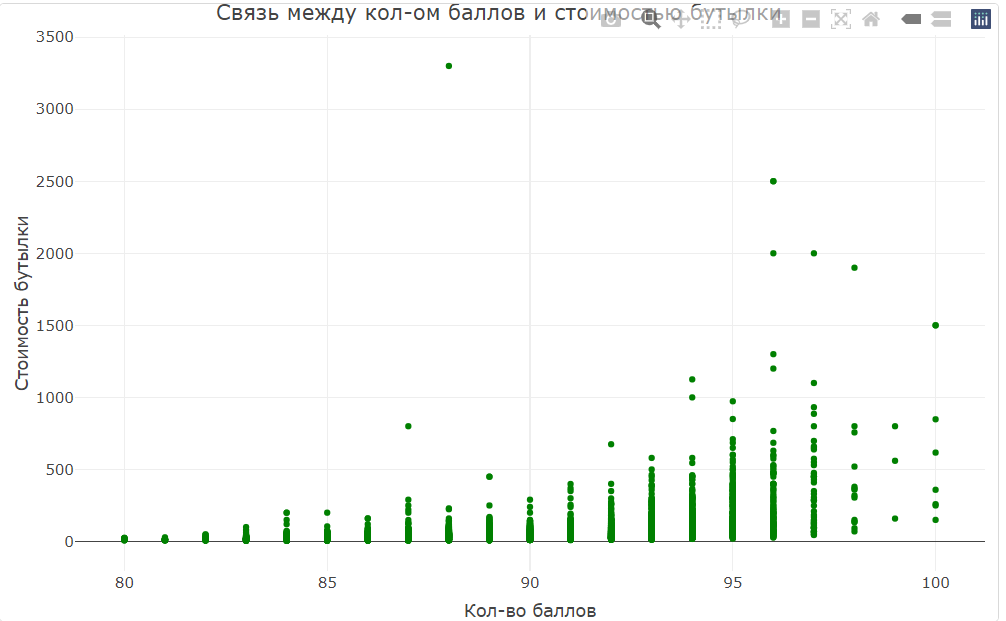

## Задача 4

На основе диаграммы рассеивания из задачи 3 постройте другую диаграмму рассеивания — такую, где цвет точки зависит от провинции, в которой было произведено вино. Измените цветовую палитру (выберите на своё усмотрение).

In [ ]:
zadacha_4 <- plot_ly(data = wine_fr, x = ~points, y = ~price, type = 'scatter',
                     mode = 'markers', color = ~province, colors = "Paired")
zadacha_4

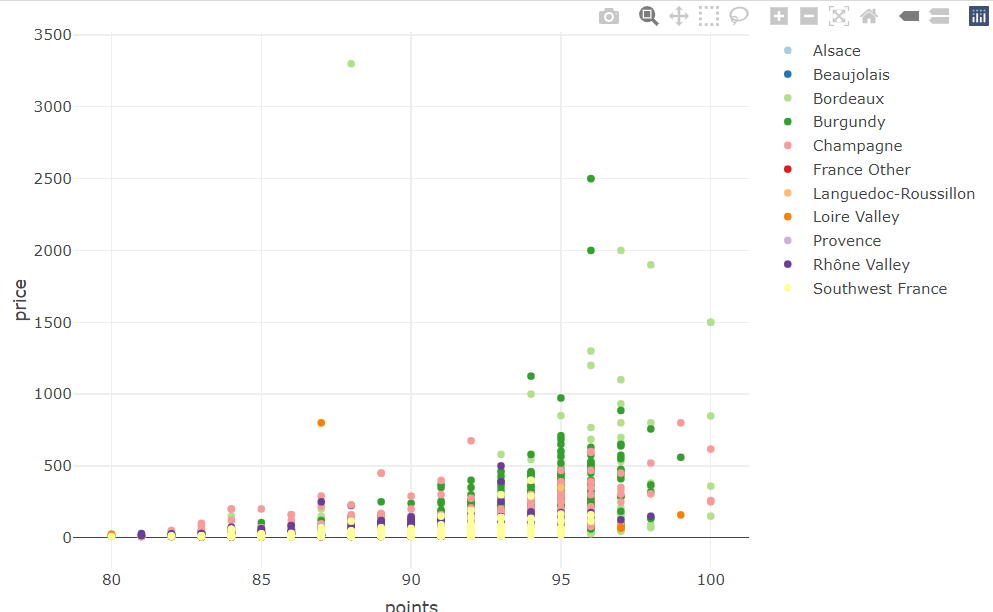

## Задача 5

Сохраните в датафрейм `wine_90plus` строки, которые соответствуют винам из Италии, Испании и Франции, набравшим более 90 баллов по оценкам экспертов.

In [ ]:
filter_country <- c('Italy', 'Spain', 'France')
wine_90plus <- wine %>% filter(country %in% filter_country & points > 90)

head(wine_90plus)

## Задача 6

Используя библиотеку `plotly` и датафрейм `wine90_plus`, постройте интерактивную визуализацию, которая включает следующие элементы:

* выпадающее меню с выбором страны происхождения вина (Италия, Испания, Франция);
* выпадающее меню с выбором цвета заливки гистограммы (любые пять цветов на выбор);
* гистограмму для стоимости бутылки вина в той стране, которую выбрал пользователь.

Гистограмма должна строиться по той части датафрейма, которая соответствует определённой стране.

**Подсказка:** удобнее всего создать три разных датафрейма (для вин Италии, Испании и Франции), а затем воспользоваться аргументом `data` в функции `add_trace()`.

In [ ]:
wine_90_Italy <- wine_90plus %>% filter(country == 'Italy')
wine_90_Spain <- wine_90plus %>% filter(country == 'Spain')
wine_90_France <- wine_90plus %>% filter(country == 'France')

zadacha_6 <- plot_ly(data = wine_90_Italy, x = ~price, type = 'histogram', name = 'Price in Italy')
zadacha_6 <- zadacha_6 %>% add_trace(data = wine_90_Spain, x = ~price, name = 'Price in Spain', visible = FALSE)
zadacha_6 <- zadacha_6 %>% add_trace(data = wine_90_France, x = ~price, name = 'Price in France', visible = FALSE)

zadacha_6 <- zadacha_6 %>% layout(
  title = "<b>The price of wine</b>",
  updatemenus = list(
    list(
      x = -0.5,
      y = 1,
      buttons = list(
        list(method = "restyle",
             args = list("visible", list(TRUE, FALSE, FALSE)),
             label = "Italy"),
        list(method = "restyle",
             args = list("visible", list(FALSE, TRUE, FALSE)),
             label = "Spain"),
        list(method = "restyle",
             args = list("visible", list(FALSE, FALSE, TRUE)),
             label = "France"))),
    list(
      x = -0.5,
      y = 0.9,
      buttons = list(
        list(method = "restyle",
             args = list("marker.color", "blue"),
             label = "Blue"),
        list(method = "restyle",
             args = list("marker.color", "pink"),
             label = "Pink"),
        list(method = "restyle",
             args = list("marker.color", "gold"),
             label = "Gold"),
        list(method = "restyle",
             args = list("marker.color", "green"),
             label = "Green"),
        list(method = "restyle",
             args = list("marker.color", "red"),
             label = "Red")))))
zadacha_6

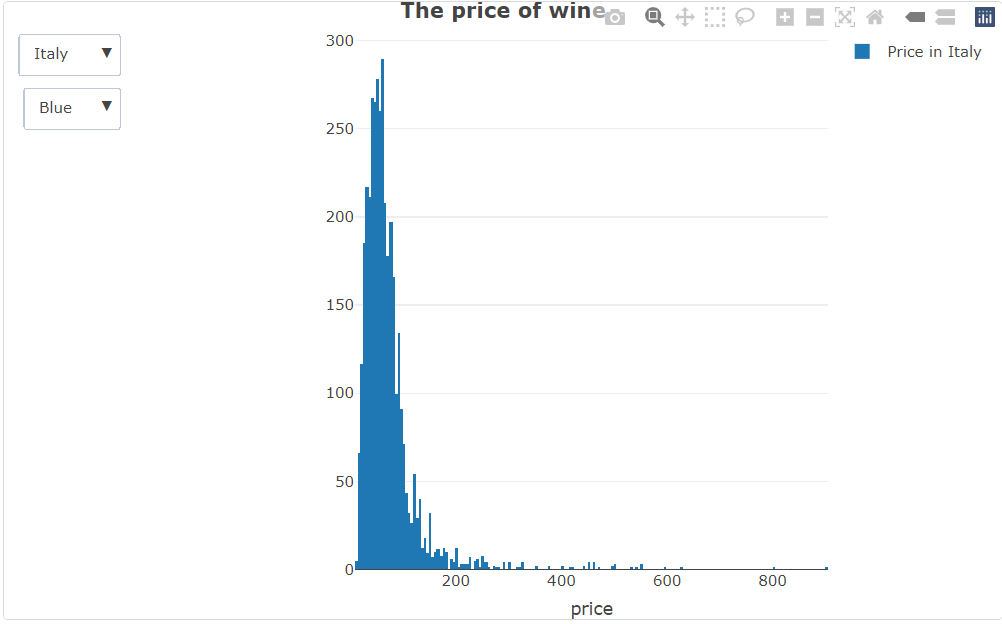

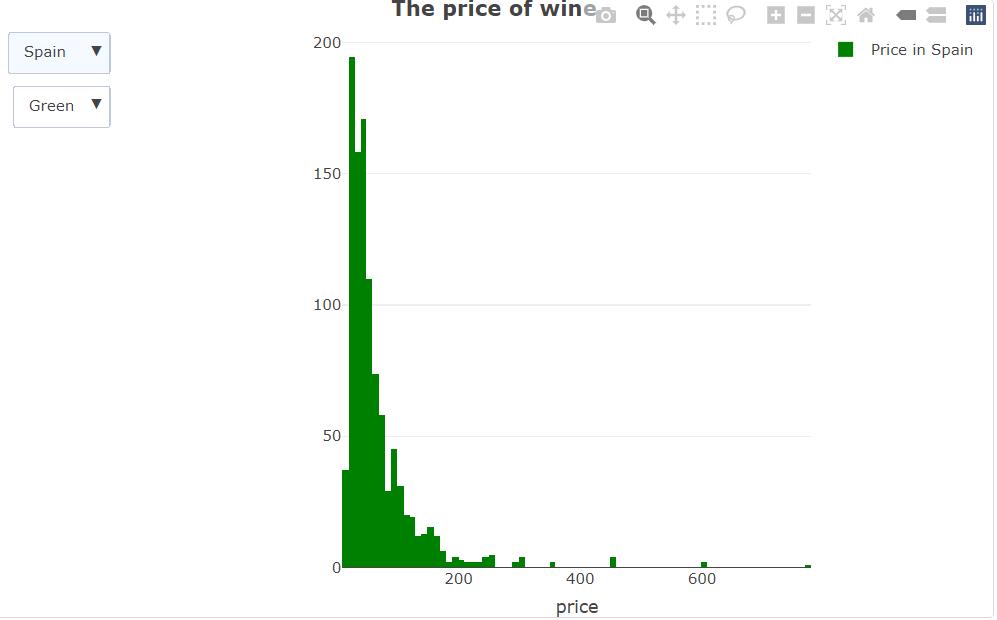

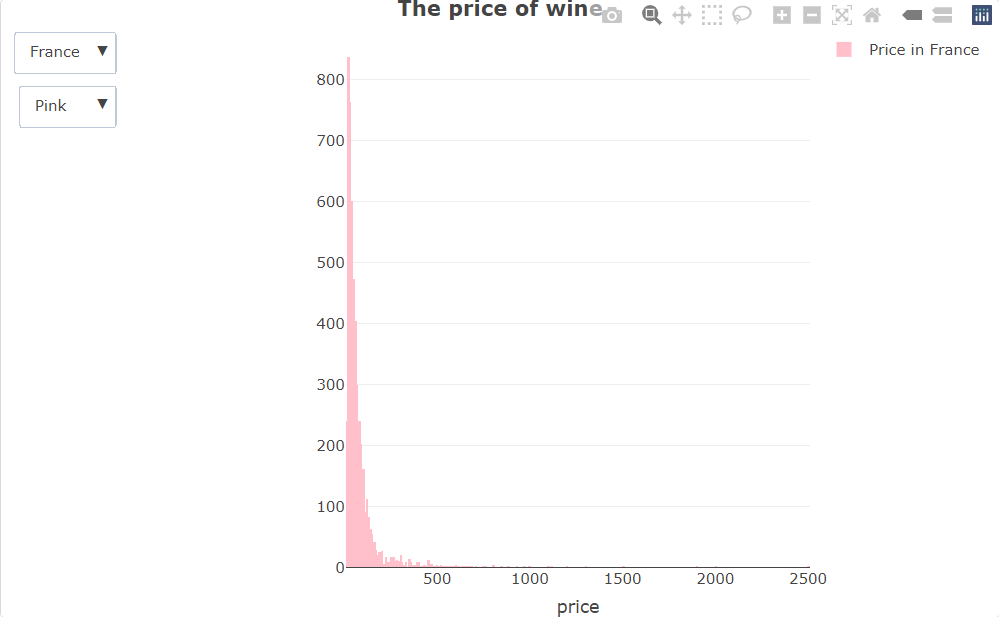

#Практическая работа 19

###Задание
Используя материалы уроков и документацию Shiny, создайте для данных из файла Titanic.csv дашборд, который содержит следующее:

- строку с двумя выпадающими меню, где первое меню используется для
выбора неколичественного показателя (Survived, PClass, Sex), а второе меню — для выбора количественного показателя (Age, Fare);

- строку с двумя выпадающими меню, где первое меню используется для выбора цвета первого графика, второе меню — для выбора цвета второго графика (выберите несколько цветов на своё усмотрение);

- два графика в одной строке рядом друг с другом, где первый график — столбиковая диаграмма для выбранного неколичественного показателя, а второй — гистограмма для выбранного количественного показателя.
Добавьте подписи к осям и названия графиков.



Подсказка: внутри fluidPage() может быть несколько строк типа fluidRow, плюс внутри mainPanel() для создания двух графиков в одной строке рядом друг с другом можно создать строку fluidRow с таким содержимым:



splitLayout(cellWidths = c("50%", "50%"), plotOutput("distPlot1"), plotOutput("distPlot2")),



где distPlot1 и distPlot2 — уникальные ID графиков, описанных в server(), а вектор c("50% "50%") нужен для сжатия графика до ширины в половину страницы.



Примерный вид дашборда:

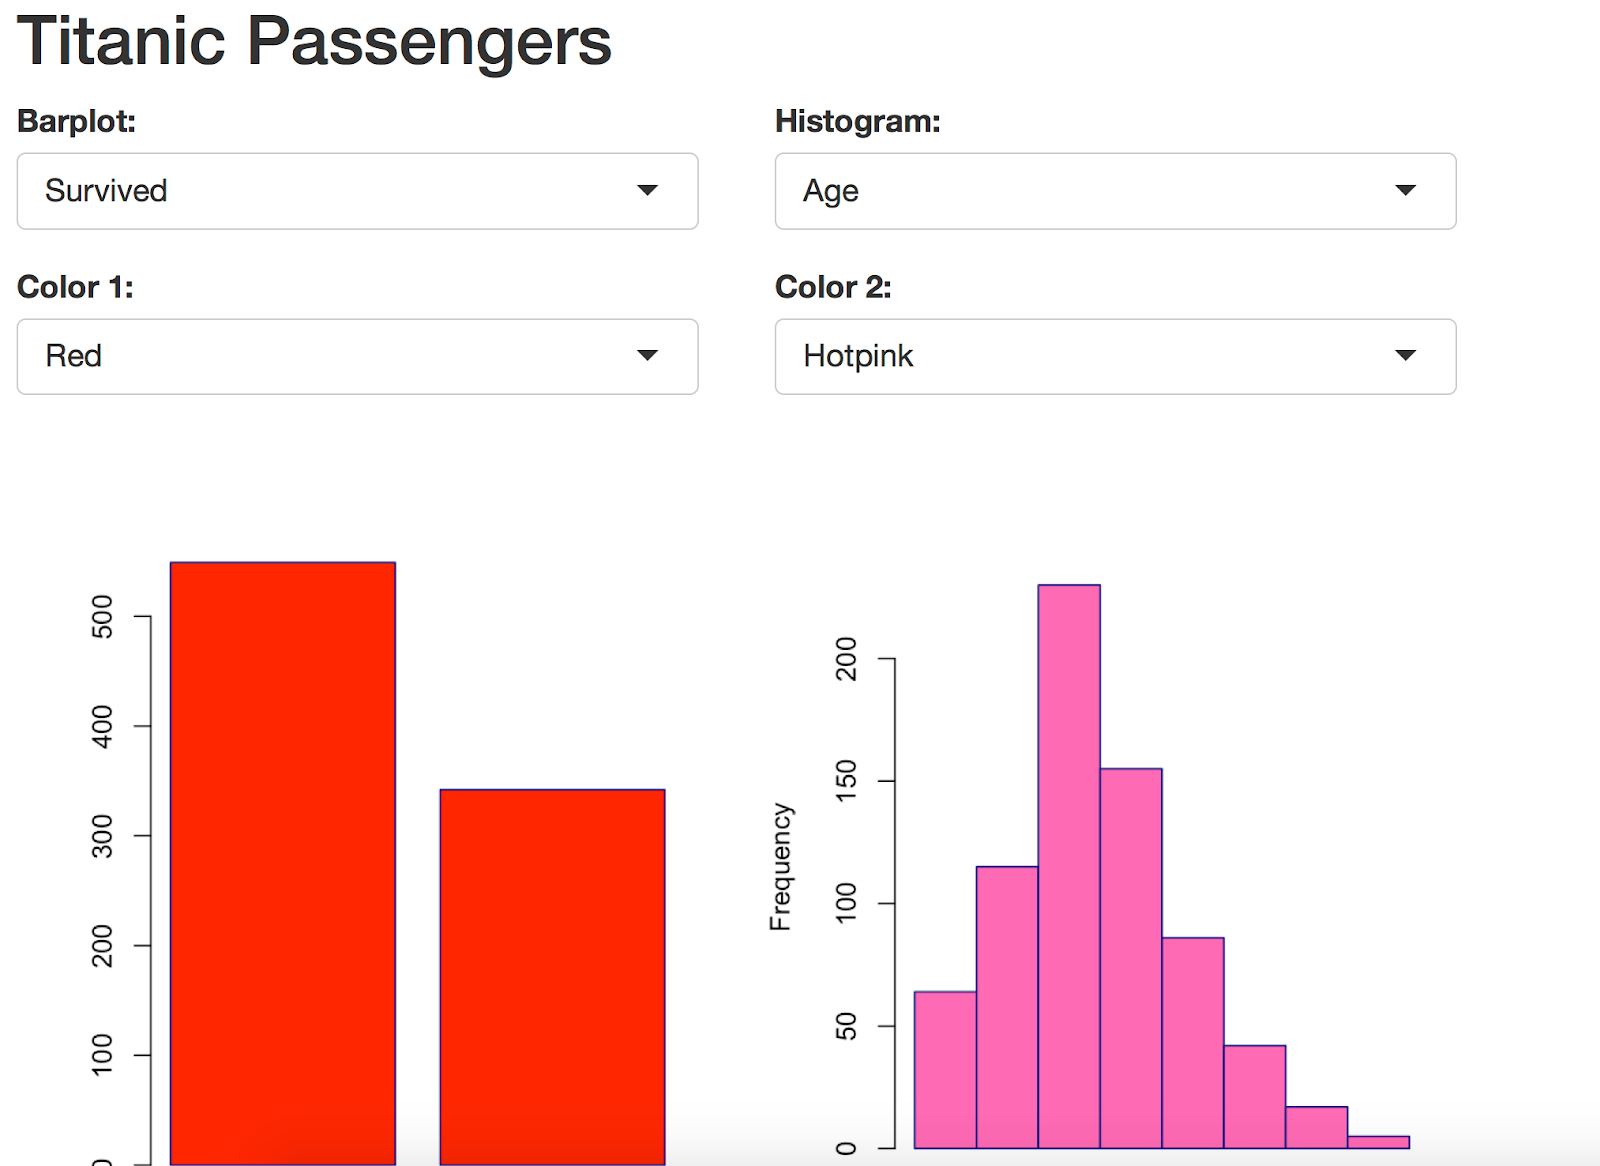

In [ ]:
install.packages('shiny')

In [ ]:
library(shiny)


titanic_data <- read.csv("/content/датасеты/Titanic.csv")

ui <- fluidPage(
  titlePanel("Titanic Passengers"),
  fluidRow(
    column(6,
           selectInput("nonquant", "Barplot:",
                       choices = c("Survived", "Pclass", "Sex"),
                       selected = "Survived")
    ),
    column(6,
           selectInput("quant", "Histogram:",
                       choices = c("Age", "Fare"),
                       selected = "Age")
    )
  ),

  fluidRow(
    column(6,
           selectInput("color1", "Color 1:",
                       choices = c("Red", "Blue", "Green", "Orange", "Purple"),
                       selected = "Red")
    ),
    column(6,
           selectInput("color2", "Color 2:",
                       choices = c("Hotpink", "Yellow", "Cyan", "Grey", "Pink"),
                       selected = "Hotpink")
    )
  ),

  fluidRow(
    splitLayout(cellWidths = c("50%", "50%"),
                plotOutput("distPlot1"),
                plotOutput("distPlot2"))
  )
)

server <- function(input, output) {
  output$distPlot1 <- renderPlot({
    bar_data <- table(titanic_data[[input$nonquant]])
    bar_colors <- input$color1

    barplot(
      bar_data,
      main = paste("Barplot of", input$nonquant),
      xlab = input$nonquant,
      ylab = "Count",
      col = bar_colors,
      border = "black",
      ylim = c(0, max(bar_data))
    )
  })

  output$distPlot2 <- renderPlot({
    hist_data <- na.omit(titanic_data[[input$quant]])
    hist_colors <- input$color2

    hist(
      hist_data,
      main = paste("Histogram of", input$quant),
      xlab = input$quant,
      ylab = "Frequency",
      col = hist_colors,
      border = "blue",
      breaks = 11
    )
  })
}

shinyApp(ui = ui, server = server)

**Приложил скриншоты:**

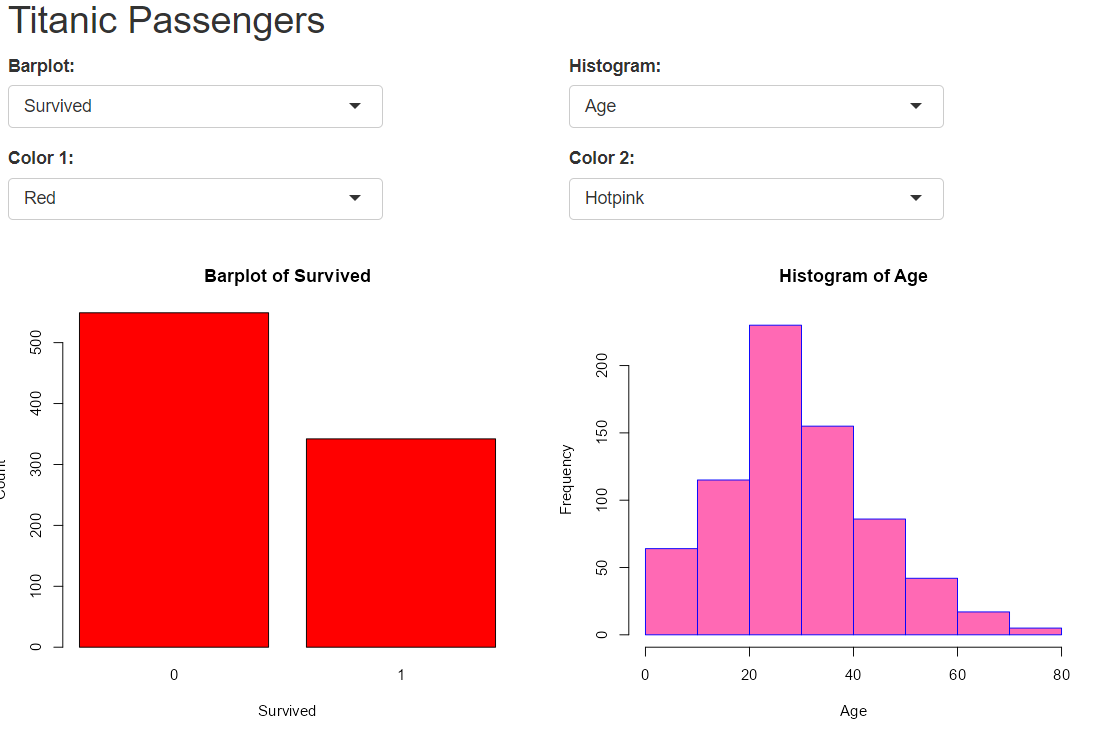

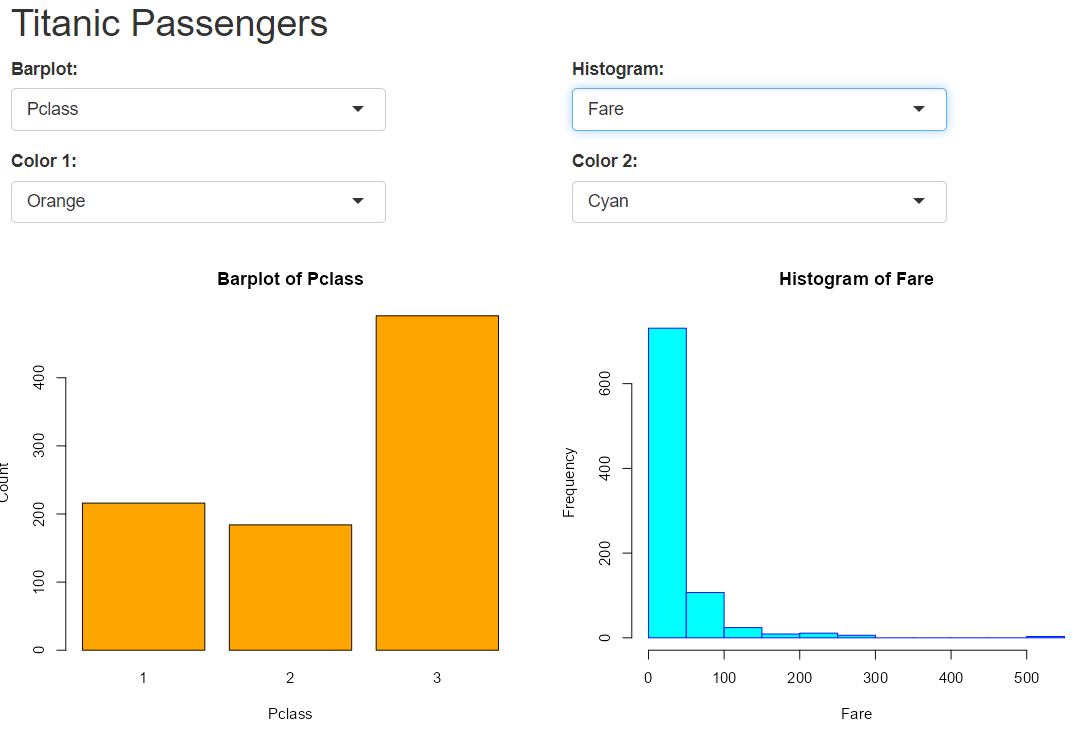

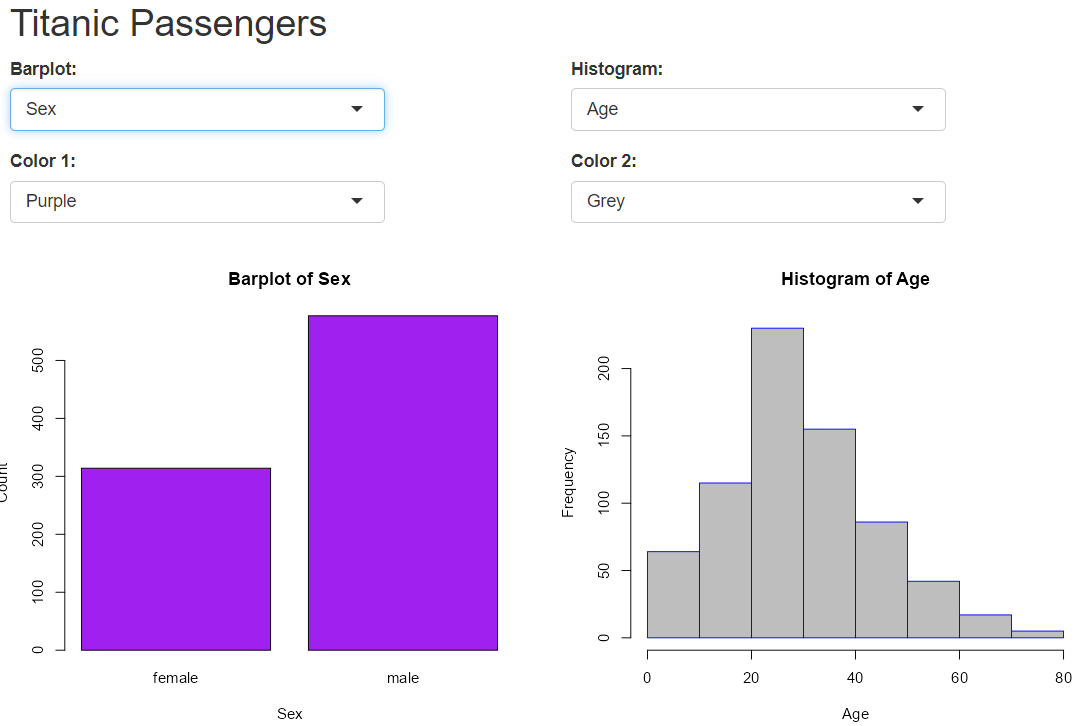